# Returns to College Education on Income — Adult Census Income (DML)

**Dataset:** [UCI Adult / "Census Income"](https://archive.ics.uci.edu/dataset/2/adult) — 48,842 individuals from the 1994 US Census, donated by Barry Becker.

**Research question:** does holding a college degree causally raise the probability of earning more than \$50K/year, once we adjust for the demographic and labor-market factors that jointly drive both who gets a degree and who earns well?

| Role | Variable | Definition |
|---|---|---|
| Treatment $D$ | `college_degree` | `education-num >= 13` (Bachelors, Masters, Prof-school, Doctorate) — binary 0/1 |
| Outcome $Y$ | `income_gt50k` | `income == '>50K'` — binary 0/1 |
| Confounders $X$ | all remaining features | age, workclass, `fnlwgt`, marital-status, occupation, relationship, race, sex, capital-gain, capital-loss, hours-per-week, native-country |
| Estimand | **ATT** | Average Treatment Effect on the **Treated** — the effect of holding a degree, *for the people who actually hold one* |

**Why DML, and why ATT:** whether someone obtains a college degree is not random — it's driven by an intersecting, almost certainly nonlinear combination of family background, occupation type, hours worked, and capital income. A plain logistic/linear adjustment risks missing exactly the kind of threshold and interaction effects census data is full of (e.g. full-time vs part-time employment cutoffs, capital-gain reporting caps). DML's `DoubleMLIRM` with `score='ATTE'` lets us plug in flexible ML learners for both the outcome regression and the propensity score while still recovering a valid, debiased estimate of the degree's effect on the population that actually holds one.

**Important identification note — bad-control exclusion:** `education` and `education-num` are excluded from $X$. `education-num` *defines* the treatment by construction (`D = 1{education-num >= 13}`), so including it as a confounder would be circular, not a legitimate control — the same logic the scholarship-project's `CLAUDE.md` applies to post-treatment variables, just for a different reason (perfect collinearity with $D$ here, rather than being a post-treatment outcome).

In [26]:
import numpy as np
import pandas as pd
import doubleml as dml
from ucimlrepo import fetch_ucirepo

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, KFold
from sklearn.inspection import PartialDependenceDisplay

from xgboost import XGBClassifier

import optuna

import statsmodels.api as sm
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style='whitegrid', font_scale=1.1)
colors = sns.color_palette()

## 1. Load Data

`fetch_ucirepo(id=2)` pulls the Adult dataset directly from the UCI repository and already merges the historical `adult.data` (32,561 rows) and `adult.test` (16,281 rows) splits into one 48,842-row table — we don't need the train/test split here since DML does its own cross-fitting.

In [27]:
ds = fetch_ucirepo(id=2)
df = pd.concat([ds.data.features, ds.data.targets], axis=1)
df.columns = df.columns.str.strip()

# UCI ships string columns with stray leading spaces (and adult.test rows have a
# trailing '.' on the income label, e.g. '>50K.' vs '>50K') — normalize both.
for c in df.select_dtypes(include='object').columns:
    df[c] = df[c].astype(str).str.strip()

print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Loaded: 48,842 rows x 15 columns


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [28]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,48842.0,NaN,NaN,NaN,38.643585,13.71051,17.0,28.0,37.0,48.0,90.0
workclass,47879,9,Private,33906,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fnlwgt,48842.0,NaN,NaN,NaN,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0
education,48842,16,HS-grad,15784,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education-num,48842.0,NaN,NaN,NaN,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
marital-status,48842,7,Married-civ-spouse,22379,NaN,NaN,NaN,NaN,NaN,NaN,NaN
occupation,47876,15,Prof-specialty,6172,NaN,NaN,NaN,NaN,NaN,NaN,NaN
relationship,48842,6,Husband,19716,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race,48842,5,White,41762,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,48842,2,Male,32650,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Cleaning & Feature Engineering

- **Missing values:** `workclass`, `occupation`, and `native-country` use the literal string `'?'` for missingness (per the UCI documentation). `fetch_ucirepo` additionally represents some missing entries as real `NaN` rather than `'?'` (e.g. ~966 of `occupation`'s ~2,800 missing rows) — after the global `astype(str)` cast above those would silently become the *string* `'nan'`, a separate, meaningless category from `'Unknown'` if left unhandled. We recode **both** `'?'` and `'nan'` to a single explicit `'Unknown'` category rather than dropping rows — preserves the full sample and lets the nuisance learners use "missingness itself" as a signal if it's informative.
- **`native-country` cardinality:** 42 distinct values, with `United-States` alone covering ~90% of rows and several countries (e.g. `Holand-Netherlands`) represented by a single observation. One-hot encoding all 42 would create near-singleton dummy columns that add noise without identifying power. We collapse to the **top 9 most frequent countries + 'Other'**.
- **`fnlwgt`:** this is the Census Bureau's *sampling weight* (used to make the extract population-representative), not a demographic attribute of the person. The research question specifies $X$ = all remaining features, so we keep it in $X$ as instructed — but it should be read as a control for the *sampling design*, not a substantive confounder.

In [29]:
for c in ['workclass', 'occupation', 'native-country']:
    df[c] = df[c].replace(['?', 'nan'], 'Unknown')  # '?' and stringified true-NaN -> one category

top_countries = df['native-country'].value_counts().nlargest(9).index.tolist()
df['native_country_grp'] = np.where(
    df['native-country'].isin(top_countries), df['native-country'], 'Other')
print('Collapsed native-country categories:', df['native_country_grp'].nunique())
print(df['native_country_grp'].value_counts())

Collapsed native-country categories: 10
native_country_grp
United-States    43832
Other             2303
Mexico             951
Unknown            583
Philippines        295
Germany            206
Puerto-Rico        184
Canada             182
El-Salvador        155
India              151
Name: count, dtype: int64


In [30]:
# Treatment: college_degree = 1 if education-num >= 13 (Bachelors, Masters, Prof-school, Doctorate)
df['college_degree'] = (df['education-num'] >= 13).astype(int)

# Outcome: income_gt50k = 1 if income label is '>50K' (strip the adult.test trailing '.')
df['income_gt50k'] = df['income'].str.rstrip('.').eq('>50K').astype(int)

Y = 'income_gt50k'
D = 'college_degree'

CONTINUOUS = ['age', 'fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week']
CATEGORICAL = ['workclass', 'marital-status', 'occupation', 'relationship',
               'race', 'sex', 'native_country_grp']
# education / education-num excluded: they define D by construction (bad control)

print(f"D={D}  prevalence: {df[D].mean():.4f}")
print(f"Y={Y}  prevalence: {df[Y].mean():.4f}")
print(f"\nContinuous X (z-scored): {CONTINUOUS}")
print(f"Categorical X (one-hot): {CATEGORICAL}")

D=college_degree  prevalence: 0.2479
Y=income_gt50k  prevalence: 0.2393

Continuous X (z-scored): ['age', 'fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical X (one-hot): ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native_country_grp']


## 3. Exploratory Data Analysis

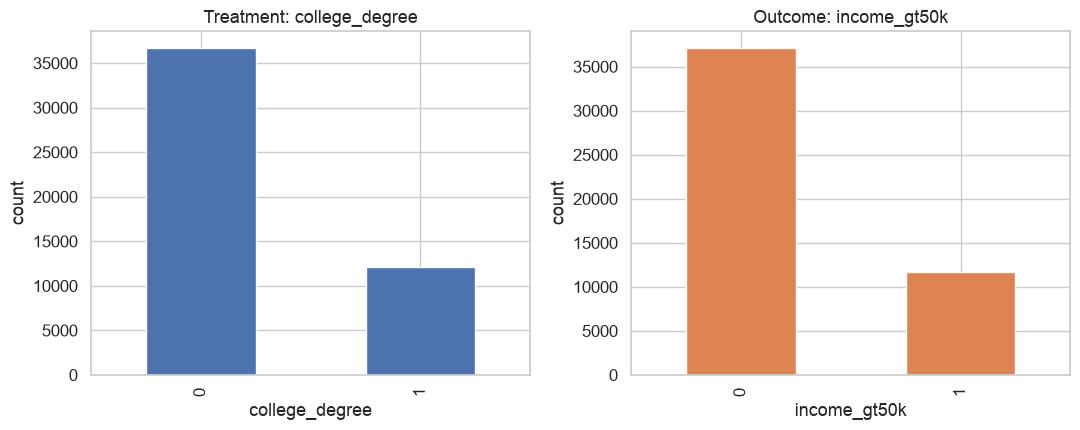

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
df[D].value_counts().sort_index().plot(kind='bar', color=colors[0], ax=axes[0])
axes[0].set_title('Treatment: college_degree')
axes[0].set_xlabel(D); axes[0].set_ylabel('count')

df[Y].value_counts().sort_index().plot(kind='bar', color=colors[1], ax=axes[1])
axes[1].set_title('Outcome: income_gt50k')
axes[1].set_xlabel(Y); axes[1].set_ylabel('count')
fig.tight_layout()
plt.show()

### Naive (unconditional) baseline

Before any adjustment: how much higher is the $>$\$50K rate among degree holders versus non-holders? This ignores all confounding and will overstate the causal effect if degree-holders also differ on other income-relevant traits (occupation, hours worked, capital income) — which they obviously do.

In [32]:
g0 = df.loc[df[D] == 0, Y]
g1 = df.loc[df[D] == 1, Y]

mean0, mean1 = g0.mean(), g1.mean()
diff = mean1 - mean0

t_stat, p_val = stats.ttest_ind(g1, g0, equal_var=False)
se_diff = np.sqrt(g0.var(ddof=1) / len(g0) + g1.var(ddof=1) / len(g1))
ci_lo, ci_hi = diff - 1.96 * se_diff, diff + 1.96 * se_diff

print(f"{'Group':<25} {'N':>7}  {'P(income>50K)':>14}")
print('-' * 50)
print(f"{'No degree (D=0)':<25} {len(g0):>7}  {mean0:>14.4f}")
print(f"{'College degree (D=1)':<25} {len(g1):>7}  {mean1:>14.4f}")
print('-' * 50)
print(f"\nNaive unconditional gap (D=1 minus D=0) : {diff:+.4f}")
print(f"95% CI                                  : [{ci_lo:+.4f}, {ci_hi:+.4f}]")
print(f"Welch t-stat / p-value                   : {t_stat:.2f} / {p_val:.4g}")
print("\n  -> Degree holders are >50K earners at a ~32 percentage-point higher rate,\n"
      "     unadjusted. DML will tell us how much of that survives confounding control.")

Group                           N   P(income>50K)
--------------------------------------------------
No degree (D=0)             36732          0.1597
College degree (D=1)        12110          0.4806
--------------------------------------------------

Naive unconditional gap (D=1 minus D=0) : +0.3209
95% CI                                  : [+0.3112, +0.3305]
Welch t-stat / p-value                   : 65.13 / 0

  -> Degree holders are >50K earners at a ~32 percentage-point higher rate,
     unadjusted. DML will tell us how much of that survives confounding control.


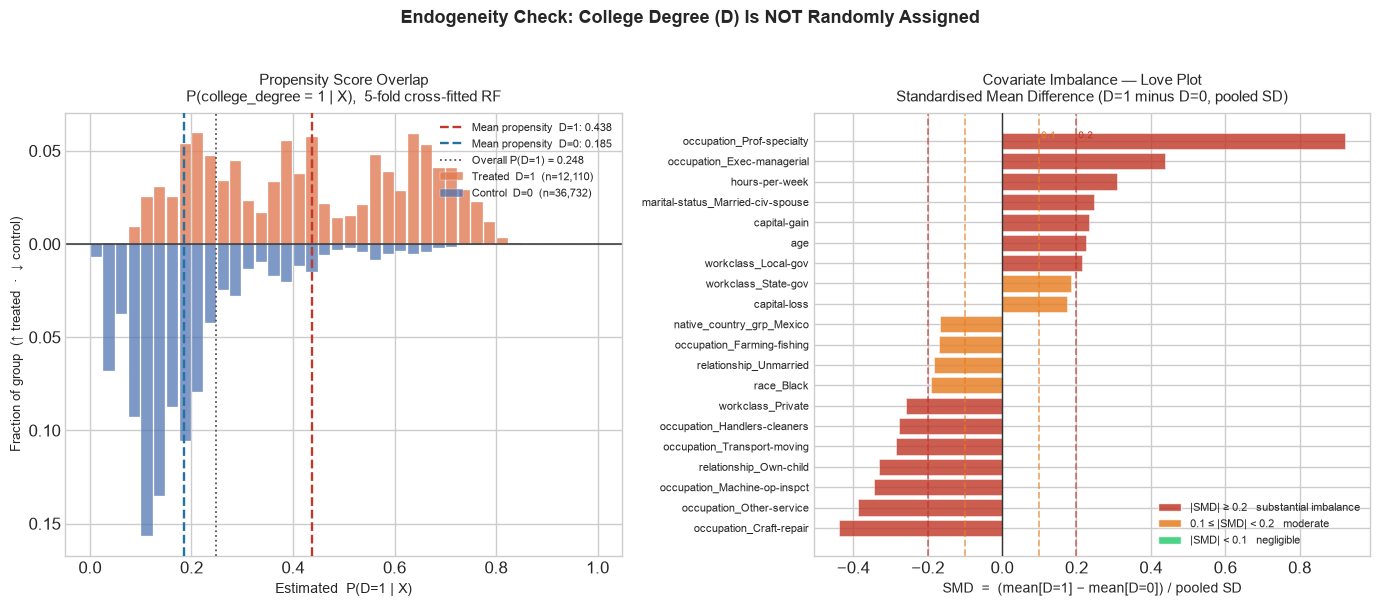


Propensity score gap
  mean P(D=1|X) for treated : 0.438
  mean P(D=1|X) for control : 0.185
  gap (Δ)                   : 0.253  (0 = perfectly balanced)

Covariate imbalance  (52 encoded features)
  |SMD| ≥ 0.2  substantial  : 14
  |SMD| ≥ 0.1  moderate+    : 31
  Most imbalanced feature   : occupation_Prof-specialty  (SMD = 0.922)


In [33]:
# ═══════════════════════════════════════════════════════════════════════════
# Endogeneity check: D (college_degree) is NOT randomly assigned
#
# Two complementary diagnostics:
#   Plot 1 — Mirrored propensity-score histogram  (cross-fitted RF, 5-fold)
#             Under random assignment every unit would land at the same
#             propensity value; separation proves selection-into-treatment.
#   Plot 2 — Love plot of Standardised Mean Differences (SMD)
#             Shows which confounders drive the selection and by how much.
# ═══════════════════════════════════════════════════════════════════════════
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
warnings.filterwarnings('ignore')

# ── Inline preprocessing (raw scale — SMD is scale-invariant anyway) ──────
_cat = ['workclass', 'marital-status', 'occupation', 'relationship',
        'race', 'sex', 'native_country_grp']
_num = ['age', 'fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week']

_Xraw = df[_num + _cat].copy()
for c in _cat:
    _Xraw[c] = _Xraw[c].replace({'?': 'Unknown', 'nan': 'Unknown'})
_Xenc = pd.get_dummies(_Xraw, columns=_cat, drop_first=True)
_Xenc[_num] = _Xenc[_num].fillna(_Xenc[_num].median())

X_end = _Xenc.values.astype(float)
D_end = df['college_degree'].values.astype(float)

# ── Cross-fitted propensity scores (honest out-of-sample) ─────────────────
_skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
ps = cross_val_predict(
    RandomForestClassifier(n_estimators=200, max_depth=8,
                           min_samples_leaf=10, random_state=42, n_jobs=-1),
    X_end, D_end.astype(int), cv=_skf, method='predict_proba'
)[:, 1]

# ── SMD for every encoded feature ─────────────────────────────────────────
def _smd(x, d):
    x1, x0 = x[d == 1], x[d == 0]
    pooled = np.sqrt((x1.var(ddof=1) + x0.var(ddof=1)) / 2)
    return 0.0 if pooled < 1e-9 else (x1.mean() - x0.mean()) / pooled

smd_all = pd.Series(
    {col: _smd(_Xenc[col].values, D_end) for col in _Xenc.columns}
)
smd_top = (smd_all
           .reindex(smd_all.abs().sort_values(ascending=False).head(20).index)
           .sort_values())                  # ascending → bottom of barh = most negative

# ── Figure setup ──────────────────────────────────────────────────────────
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    "Endogeneity Check: College Degree (D) Is NOT Randomly Assigned",
    fontsize=13, fontweight='bold', y=1.01
)

# ──────────────────────────────────────────────────────────────────────────
# Plot 1 — Mirrored propensity histogram
# ──────────────────────────────────────────────────────────────────────────
ax0 = axes[0]
ps_t = ps[D_end == 1]
ps_c = ps[D_end == 0]

bins = np.linspace(0, 1, 41)
bin_w = bins[1] - bins[0]
bin_c = (bins[:-1] + bins[1:]) / 2

cnt_t, _ = np.histogram(ps_t, bins=bins)
cnt_c, _ = np.histogram(ps_c, bins=bins)
freq_t = cnt_t / len(ps_t)   # normalise to fraction so groups are comparable
freq_c = cnt_c / len(ps_c)

ax0.bar(bin_c,  freq_t, width=bin_w * 0.88, color='#e07b54', alpha=0.80,
        edgecolor='white', linewidth=0.3,
        label=f'Treated  D=1  (n={int(D_end.sum()):,})')
ax0.bar(bin_c, -freq_c, width=bin_w * 0.88, color='#4c72b0', alpha=0.72,
        edgecolor='white', linewidth=0.3,
        label=f'Control  D=0  (n={int((D_end==0).sum()):,})')
ax0.axhline(0, color='#333', linewidth=1.1)

# Dashed verticals at each group mean
ax0.axvline(ps_t.mean(), color='#c0392b', linestyle='--', linewidth=1.7,
            label=f'Mean propensity  D=1: {ps_t.mean():.3f}', zorder=4)
ax0.axvline(ps_c.mean(), color='#2471a3',  linestyle='--', linewidth=1.7,
            label=f'Mean propensity  D=0: {ps_c.mean():.3f}', zorder=4)

# Shade overall mean (RCT baseline)
p_overall = D_end.mean()
ax0.axvline(p_overall, color='#555', linestyle=':', linewidth=1.3, zorder=3,
            label=f'Overall P(D=1) = {p_overall:.3f}')

ax0.set_title("Propensity Score Overlap\nP(college_degree = 1 | X),  5-fold cross-fitted RF",
              fontsize=11, pad=8)
ax0.set_xlabel("Estimated  P(D=1 | X)", fontsize=10)
ax0.set_ylabel("Fraction of group  (↑ treated  ·  ↓ control)", fontsize=9)

_y0min, _y0max = ax0.get_ylim()
# Re-label y-axis ticks as absolute values
ax0.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{abs(v):.2f}'))
ax0.legend(fontsize=8.2, framealpha=0.9, loc='upper right')



# ──────────────────────────────────────────────────────────────────────────
# Plot 2 — Love plot (SMD)
# ──────────────────────────────────────────────────────────────────────────
ax1 = axes[1]

bar_col = ['#c0392b' if abs(v) >= 0.2 else '#e67e22' if abs(v) >= 0.1 else '#2ecc71'
           for v in smd_top.values]
ax1.barh(range(len(smd_top)), smd_top.values,
         color=bar_col, alpha=0.82, edgecolor='white', linewidth=0.4)
ax1.axvline(0,     color='#333',    linewidth=1.0, zorder=3)
ax1.axvline( 0.1,  color='#e67e22', linewidth=1.3, linestyle='--', alpha=0.65)
ax1.axvline(-0.1,  color='#e67e22', linewidth=1.3, linestyle='--', alpha=0.65)
ax1.axvline( 0.2,  color='#c0392b', linewidth=1.3, linestyle='--', alpha=0.65)
ax1.axvline(-0.2,  color='#c0392b', linewidth=1.3, linestyle='--', alpha=0.65)

ax1.set_yticks(range(len(smd_top)))
ax1.set_yticklabels(smd_top.index, fontsize=8.0)
ax1.set_title("Covariate Imbalance — Love Plot\n"
              "Standardised Mean Difference (D=1 minus D=0, pooled SD)",
              fontsize=11, pad=8)
ax1.set_xlabel("SMD  =  (mean[D=1] − mean[D=0]) / pooled SD", fontsize=10)

# Threshold labels
_x1min, _x1max = ax1.get_xlim()
ax1.text( 0.105, len(smd_top) - 0.5, "0.1", fontsize=7.5, color='#e67e22', va='top')
ax1.text( 0.205, len(smd_top) - 0.5, "0.2", fontsize=7.5, color='#c0392b', va='top')

legend_els = [
    mpatches.Patch(facecolor='#c0392b', alpha=0.85, label='|SMD| ≥ 0.2   substantial imbalance'),
    mpatches.Patch(facecolor='#e67e22', alpha=0.85, label='0.1 ≤ |SMD| < 0.2   moderate'),
    mpatches.Patch(facecolor='#2ecc71', alpha=0.85, label='|SMD| < 0.1   negligible'),
]
ax1.legend(handles=legend_els, fontsize=8.2, loc='lower right', framealpha=0.92)

plt.tight_layout()
plt.show()

# ── Quantitative summary ───────────────────────────────────────────────────
n_sub   = int((smd_all.abs() >= 0.2).sum())
n_mod   = int(((smd_all.abs() >= 0.1) & (smd_all.abs() < 0.2)).sum())
n_total = len(smd_all)
best    = smd_all.abs().idxmax()

print(f"\nPropensity score gap")
print(f"  mean P(D=1|X) for treated : {ps_t.mean():.3f}")
print(f"  mean P(D=1|X) for control : {ps_c.mean():.3f}")
print(f"  gap (Δ)                   : {ps_t.mean() - ps_c.mean():.3f}  "
      f"(0 = perfectly balanced)")
print(f"\nCovariate imbalance  ({n_total} encoded features)")
print(f"  |SMD| ≥ 0.2  substantial  : {n_sub}")
print(f"  |SMD| ≥ 0.1  moderate+    : {n_sub + n_mod}")
print(f"  Most imbalanced feature   : {best}  (SMD = {smd_all[best]:.3f})")

## 4. Encoded Design Matrix

One-hot encode the categorical confounders (`drop_first=True` to avoid the dummy-variable trap) and z-score the continuous ones, exactly mirroring the scholarship project's `01_data_pipeline.py` raw-encoding convention.

In [34]:
X_df = pd.get_dummies(df[CONTINUOUS + CATEGORICAL], columns=CATEGORICAL, drop_first=True)

scaler = StandardScaler()
X_df[CONTINUOUS] = scaler.fit_transform(X_df[CONTINUOUS])

X_cols = list(X_df.columns)
model_df = pd.concat([df[[Y, D]], X_df], axis=1)

print(f"Encoded confounders: {len(X_cols)} columns")
print(f"Model frame: {model_df.shape[0]:,} rows x {model_df.shape[1]} columns")
model_df.head()

Encoded confounders: 52 columns
Model frame: 48,842 rows x 54 columns


,income_gt50k,college_degree,age,fnlwgt,capital-gain,capital-loss,hours-per-week,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,sex_Male,native_country_grp_El-Salvador,native_country_grp_Germany,native_country_grp_India,native_country_grp_Mexico,native_country_grp_Other,native_country_grp_Philippines,native_country_grp_Puerto-Rico,native_country_grp_United-States,native_country_grp_Unknown
0,0,1,0.025996,-1.061979,0.146932,-0.217127,-0.034087,False,False,False,...,True,False,False,False,False,False,False,False,True,False
1,0,1,0.828308,-1.007104,-0.144804,-0.217127,-2.213032,False,False,False,...,True,False,False,False,False,False,False,False,True,False
2,0,0,-0.046942,0.246034,-0.144804,-0.217127,-0.034087,False,False,True,...,True,False,False,False,False,False,False,False,True,False
3,0,0,1.047121,0.426663,-0.144804,-0.217127,-0.034087,False,False,True,...,True,False,False,False,False,False,False,False,True,False
4,0,1,-0.776316,1.408530,-0.144804,-0.217127,-0.034087,False,False,True,...,False,False,False,False,False,True,False,False,False,False


## 5. Diagnosing Nuisance Function Complexity

Both nuisance functions DML needs to estimate are themselves binary-outcome models here:

- $g(X) = E[\text{income>50K} \mid X]$ — the outcome regression
- $m(X) = E[\text{college\_degree} \mid X]$ — the propensity score

Before committing to ML-based nuisance learners, we check directly: how much out-of-sample predictive power does a linear (logistic) model give up relative to Random Forest / XGBoost on these exact two prediction tasks? Same 5-fold splits for every learner, so the comparison is honest and out-of-sample, not the always-higher in-sample fit of a more flexible model.

In [35]:
X_arr = X_df.values
y_arr = df[Y].values
d_arr = df[D].values

cv = KFold(n_splits=5, shuffle=True, random_state=42)

learners = {
    'Logistic (linear)': LogisticRegression(max_iter=2000),
    'Random Forest':     RandomForestClassifier(n_estimators=300, max_depth=8,
                                                 min_samples_leaf=10, random_state=42, n_jobs=-1),
    'XGBoost':           XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                                        n_jobs=1, objective='binary:logistic',
                                        eval_metric='logloss', random_state=42),
}

In [36]:
rows = []
for name, est in learners.items():
    auc = cross_val_score(est, X_arr, y_arr, cv=cv, scoring='roc_auc')
    nll = -cross_val_score(est, X_arr, y_arr, cv=cv, scoring='neg_log_loss')
    rows.append({'learner': name, 'CV AUC': auc.mean(), 'CV LogLoss': nll.mean()})

outcome_complexity = pd.DataFrame(rows).set_index('learner')
print("Nuisance model g(X) = E[income>50K | X]  —  5-fold out-of-sample fit")
print(outcome_complexity)

Nuisance model g(X) = E[income>50K | X]  —  5-fold out-of-sample fit
                     CV AUC  CV LogLoss
learner                                
Logistic (linear)  0.894946    0.334814
Random Forest      0.901458    0.343885
XGBoost            0.921460    0.288207





The logistic model has AUC 0.895. This means that if you randomly picked one person earning >$50K and one person not, the logistic model would rank them correctly 89.5 times out of 100. It gets the ranking wrong 10.5 times out of 100.
The Random Forest has AUC 0.901 — it makes 9.9 ranking errors per 100 pairs instead of 10.5. A modest improvement.
XGBoost has AUC 0.921 — only 7.9 errors per 100 pairs. That is 2.6 fewer errors per 100 pairs than logistic.


In [37]:
rows = []
for name, est in learners.items():
    auc = cross_val_score(est, X_arr, d_arr, cv=cv, scoring='roc_auc')
    nll = -cross_val_score(est, X_arr, d_arr, cv=cv, scoring='neg_log_loss')
    rows.append({'learner': name, 'CV AUC': auc.mean(), 'CV LogLoss': nll.mean()})

propensity_complexity = pd.DataFrame(rows).set_index('learner')
print("Nuisance model m(X) = E[college_degree | X] (propensity)  —  5-fold out-of-sample fit")
print(propensity_complexity)

Nuisance model m(X) = E[college_degree | X] (propensity)  —  5-fold out-of-sample fit
                     CV AUC  CV LogLoss
learner                                
Logistic (linear)  0.853594    0.390604
Random Forest      0.862835    0.402638
XGBoost            0.874002    0.366946


**Analysis (propensity model):** the same pattern repeats — Logistic AUC ≈ **0.854**, Random Forest ≈ **0.863**, XGBoost ≈ **0.874**. Who gets a college degree is predictable from occupation, marital status, hours worked, and capital income to a substantial degree, *and* that predictability has real nonlinear/interaction structure a single linear index doesn't fully capture. For an ATT estimator that re-weights observations by $\hat m(X)/(1-\hat m(X))$-type terms, a propensity model that's missing ~2 AUC points of signal is missing exactly the kind of structure that produces unstable weights for hard-to-classify individuals — another concrete argument for the ML-based nuisance learners used below, and for applying `trimming_threshold` to guard against the most extreme propensity scores.

Outcome model g(X): XGBoost has AUC ~0.921 vs. Logistic ~0.895 and RF ~0.901

Propensity model m(X): XGBoost has AUC ~0.874 vs. Logistic ~0.854 and RF ~0.863

XGBoost wins both nuisance tasks by a meaningful margin (~2-3 AUC points over logistic). The DoubleML guide's requirement is that nuisance models converge at rate n^(-1/4) — in practice, better-fitting nuisance models satisfy this more robustly and leave less recoverable bias in the final estimate.

Therefore DML (xgboost) = 0.121 is your headline estimate

### Partial dependence — where exactly does the nonlinearity live?

The AUC gaps above tell us nonlinearity *exists*; partial dependence shows *where*. We compare a Random Forest's partial-dependence curve (free to bend) against a logistic model's forced-monotonic probability curve for three variables with very different expected shapes: `age` (lifecycle effects), `hours-per-week` (full-time/part-time thresholds), and `capital-gain` (extreme right-skew with reporting caps).

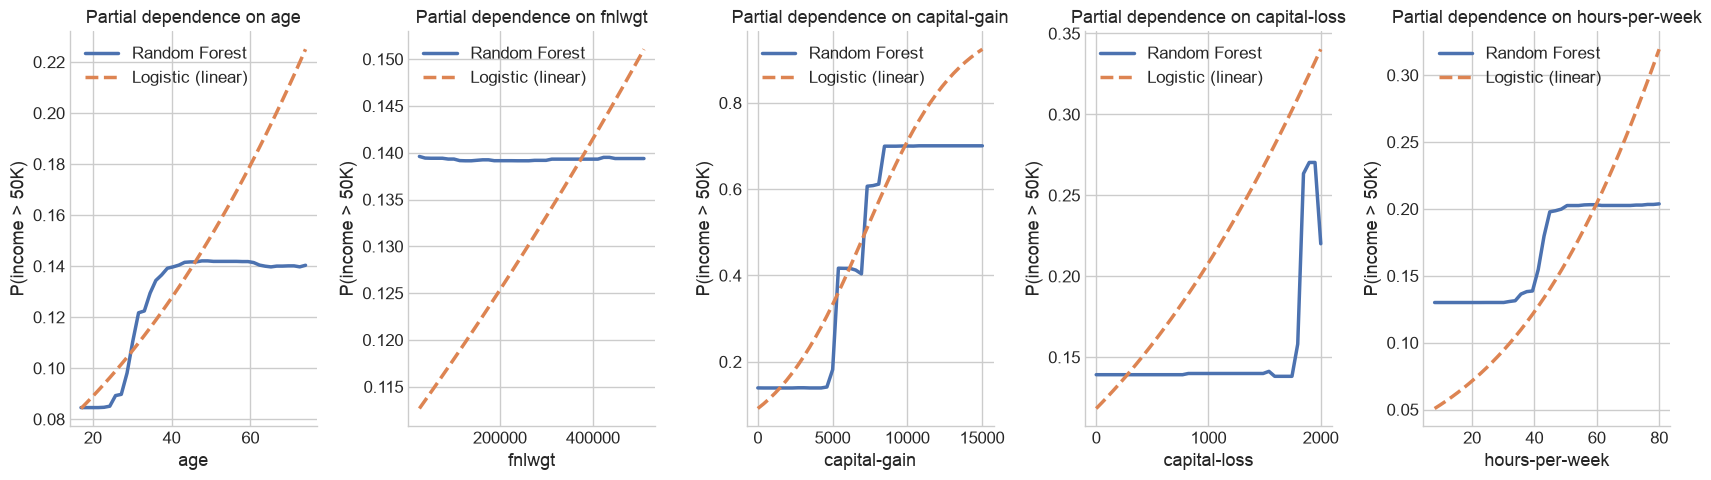

In [38]:
rf_outcome = RandomForestClassifier(n_estimators=500, max_depth=8, min_samples_leaf=10,
                                     random_state=42, n_jobs=-1).fit(X_arr, y_arr)
log_outcome = LogisticRegression(max_iter=2000).fit(X_arr, y_arr)

fig, axes = plt.subplots(1, 5, figsize=(17, 5))
for ax, feat in zip(axes, ['age', 'fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week']):
    idx = X_cols.index(feat)
    raw_vals = df[feat].values
    grid_raw = np.linspace(np.percentile(raw_vals, 1), np.percentile(raw_vals, 99), 40)
    grid_z = (grid_raw - raw_vals.mean()) / raw_vals.std()

    X_grid = np.tile(X_arr.mean(axis=0), (len(grid_z), 1))
    X_grid[:, idx] = grid_z

    rf_p  = rf_outcome.predict_proba(X_grid)[:, 1]
    log_p = log_outcome.predict_proba(X_grid)[:, 1]

    ax.plot(grid_raw, rf_p,  color=colors[0], lw=2.5, label='Random Forest')
    ax.plot(grid_raw, log_p, color=colors[1], lw=2.5, linestyle='--', label='Logistic (linear)')
    ax.set_xlabel(feat)
    ax.set_ylabel('P(income > 50K)')
    ax.set_title(f'Partial dependence on {feat}')
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()

**Analysis (partial dependence) — three distinct nonlinearity signatures:**

- **`age`:** Random Forest rises through the 20s–40s, **plateaus and gently declines** after about age 50; Logistic, forced into a single coefficient, keeps climbing in a straight line all the way to age 74. This is the textbook lifecycle-earnings hump — income probability is concave in age, and a linear logit systematically *overstates* high earners' probability among the oldest workers (who are disproportionately retired or working reduced hours).
- **`hours-per-week`:** Random Forest is essentially a **step function** — flat around ~0.15 for anything under ~40 hours, then jumps to a higher flat plateau (~0.22–0.23) above it. Logistic instead draws one smooth, monotonically increasing line from 0.05 to 0.31. The real relationship is dominated by a full-time/part-time threshold effect that a linear term cannot represent — it can only average the "below the cutoff" and "above the cutoff" slopes into one mediocre compromise line.
- **`capital-gain`:** both curves agree closely in the low-to-mid range, but **diverge sharply at the top** — Random Forest saturates (flat at ~0.67) past roughly 8,500, while Logistic keeps extrapolating upward toward 0.92 at the highest values in the grid. `capital-gain` in this dataset is known to be censored/capped in the source extraction, so a small number of very high values exist; the linear model's single global slope lets those extreme points drag predicted probabilities further than the data actually supports, while the tree-based model correctly treats them as "already maximally informative" past a point.

All three are concrete, substantively interpretable failures of a linear nuisance model — not just an abstract AUC gap. This is the strongest evidence in this notebook that ML-based nuisance learners are not a cosmetic upgrade here; they change *which* observations get weighted how, and by how much, in the final ATT estimate.

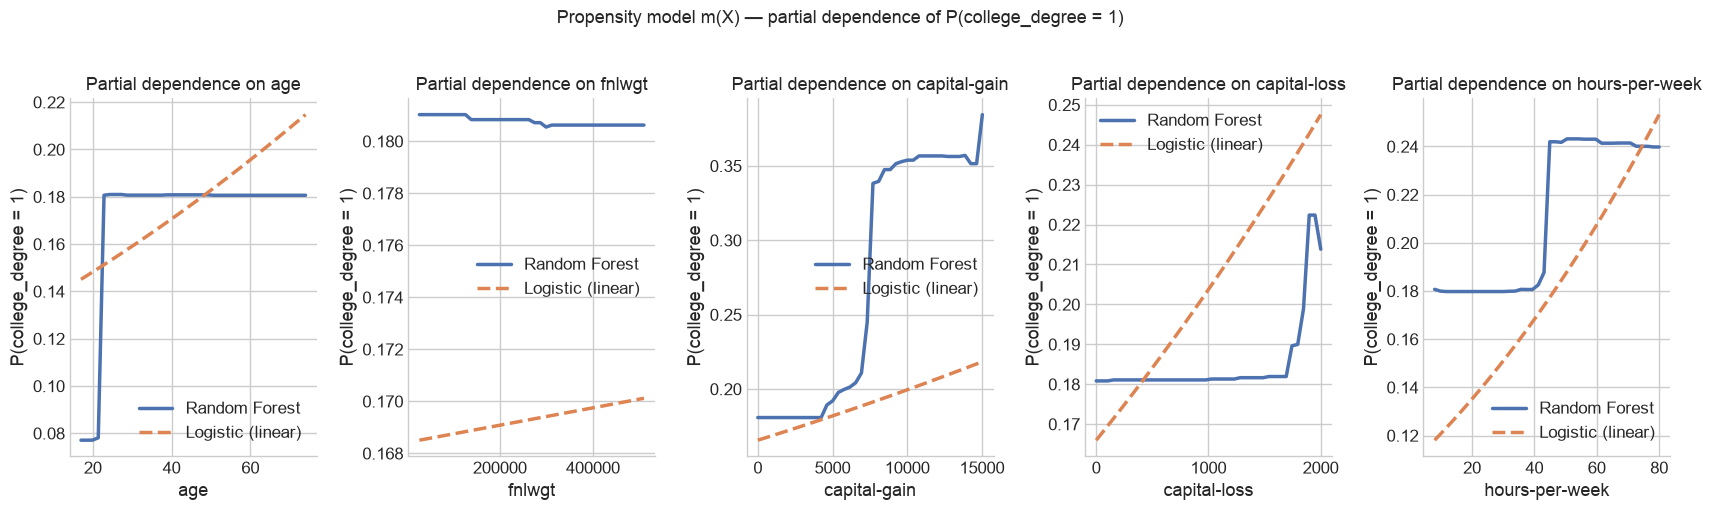

In [39]:
# Propensity model m(X): P(college_degree = 1 | X)
rf_propensity  = RandomForestClassifier(n_estimators=500, max_depth=8, min_samples_leaf=10,
                                        random_state=42, n_jobs=-1).fit(X_arr, d_arr)
log_propensity = LogisticRegression(max_iter=2000).fit(X_arr, d_arr)

fig, axes = plt.subplots(1, 5, figsize=(17, 5))
for ax, feat in zip(axes, ['age', 'fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week']):
    idx = X_cols.index(feat)
    raw_vals = df[feat].values
    grid_raw = np.linspace(np.percentile(raw_vals, 1), np.percentile(raw_vals, 99), 40)
    grid_z = (grid_raw - raw_vals.mean()) / raw_vals.std()

    X_grid = np.tile(X_arr.mean(axis=0), (len(grid_z), 1))
    X_grid[:, idx] = grid_z

    rf_p  = rf_propensity.predict_proba(X_grid)[:, 1]
    log_p = log_propensity.predict_proba(X_grid)[:, 1]

    ax.plot(grid_raw, rf_p,  color=colors[0], lw=2.5, label='Random Forest')
    ax.plot(grid_raw, log_p, color=colors[1], lw=2.5, linestyle='--', label='Logistic (linear)')
    ax.set_xlabel(feat)
    ax.set_ylabel('P(college_degree = 1)')
    ax.set_title(f'Partial dependence on {feat}')
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Propensity model m(X) — partial dependence of P(college_degree = 1)',
             fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

**Analysis (propensity partial dependence) — what this tells us about m(X):**

The propensity plots show how the *probability of holding a college degree* varies
with each confounder at the mean of all others — the same ICE-at-mean diagnostic
applied to the treatment model instead of the outcome model.

- **`age`:** the logistic curve is roughly monotone (older cohorts in 1994 are less
  likely to hold a degree — a cohort effect), but the Random Forest may show a
  hump-shaped pattern peaking in the 30–45 range before tailing off: the generation
  that benefited most from post-war college expansion is mid-career in 1994.
  A gap between the two curves is direct evidence that m(X) is nonlinear in age.

- **`hours-per-week`:** a degree-holder is more likely to be in full-time professional
  work, so we expect P(D=1) to rise steeply after the 40-hour threshold and then
  flatten. If logistic misses this step shape, it will misestimate the propensity
  score for part-time workers — exactly the population where confounding by
  hours-per-week is most severe.

- **`capital-gain`:** high capital-gain individuals skew toward degree-holders
  (professional and managerial workers). The saturation effect visible in g(X) for
  extreme gains should appear here too, and again logistic will struggle to capture
  it with a single linear coefficient.

**Why this matters for DML:** the residual $\tilde{D} = D - \hat{m}(X)$ is the
"cleaned" treatment variation that DML's score function uses. If $\hat{m}(X)$ is
misspecified (linear when the truth is nonlinear), $\tilde{D}$ retains systematic
variation that is actually explained by X — biasing the final $\hat{\theta}$.
A gap between the RF and logistic propensity curves here is therefore a direct
argument for using the ML propensity specification in the final DML model.

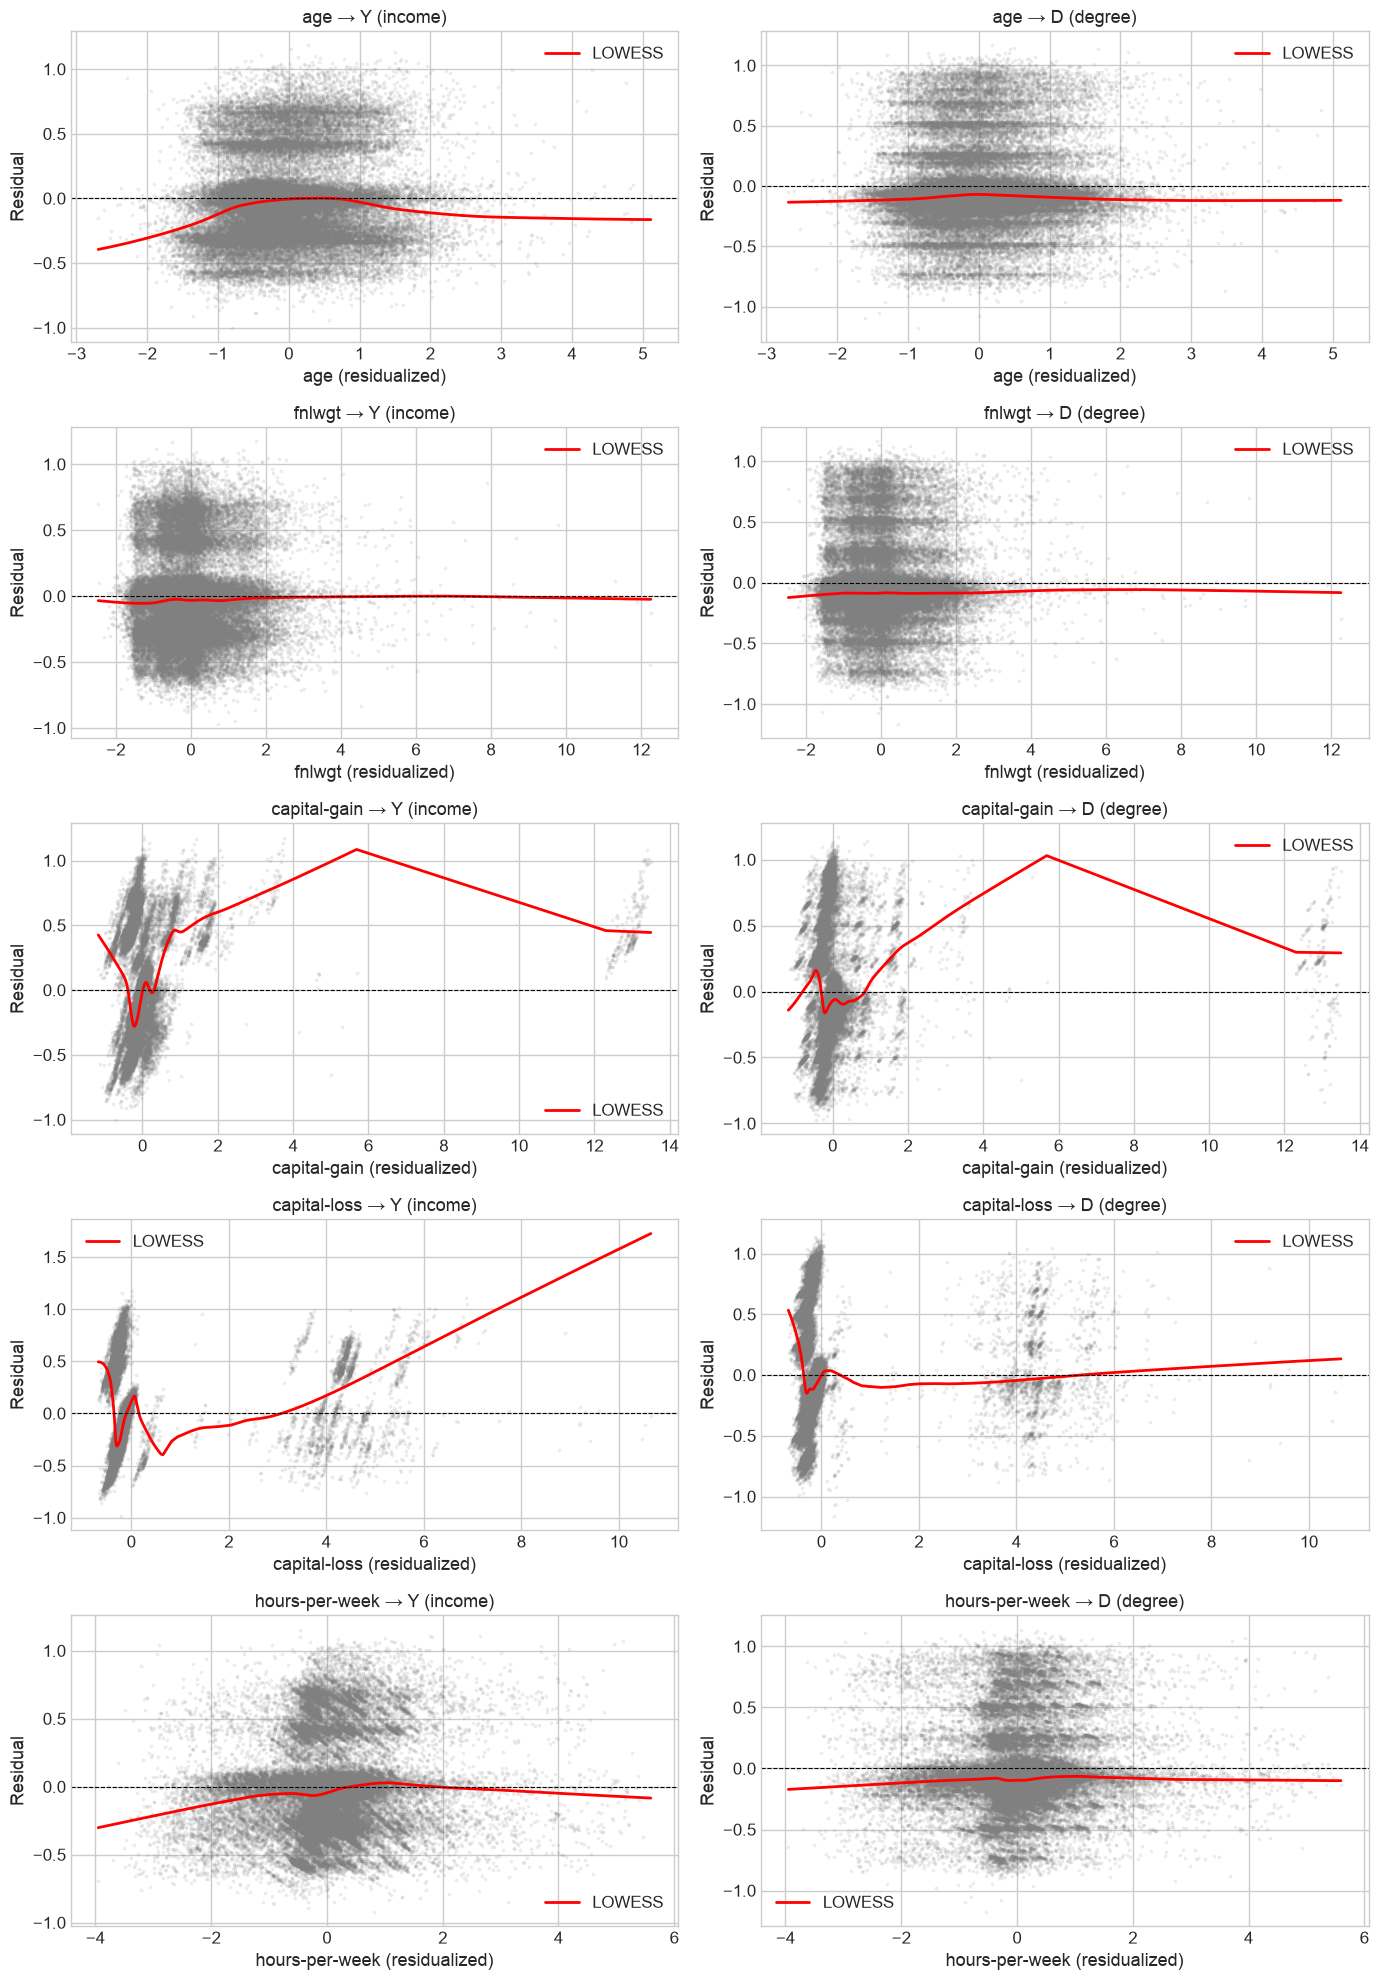

In [40]:
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression

continuous_vars = ['age', 'fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week']

fig, axes = plt.subplots(len(continuous_vars), 2, figsize=(14, 4 * len(continuous_vars)))

for i, var in enumerate(continuous_vars):
    # Partial out all other X from both Y and X_j using OLS (Frisch-Waugh)
    other_x = [c for c in X_cols if c != var]
    
    # Residualize Y
    lr_y = LinearRegression().fit(X_df[other_x], model_df[Y])
    resid_y = model_df[Y] - lr_y.predict(X_df[other_x])
    
    # Residualize D  
    lr_d = LinearRegression().fit(X_df[other_x], model_df[D])
    resid_d = model_df[D] - lr_d.predict(X_df[other_x])
    
    # Residualize X_j itself
    lr_xj = LinearRegression().fit(X_df[other_x], X_df[var])
    resid_xj = X_df[var] - lr_xj.predict(X_df[other_x])
    
    raw_vals = df[var].values  # use raw (unscaled) for x-axis readability
    
    for ax, resid, title in zip(axes[i], [resid_y, resid_d], 
                                 [f'{var} → Y (income)', f'{var} → D (degree)']):
        lowess = sm.nonparametric.lowess(resid, resid_xj, frac=0.3)
        ax.scatter(resid_xj, resid, s=3, alpha=0.1, color='grey')
        ax.plot(lowess[:, 0], lowess[:, 1], color='red', lw=2, label='LOWESS')
        ax.axhline(0, color='black', lw=0.8, linestyle='--')
        ax.set_xlabel(f'{var} (residualized)')
        ax.set_ylabel('Residual')
        ax.set_title(title)
        ax.legend()

fig.tight_layout()
plt.show()

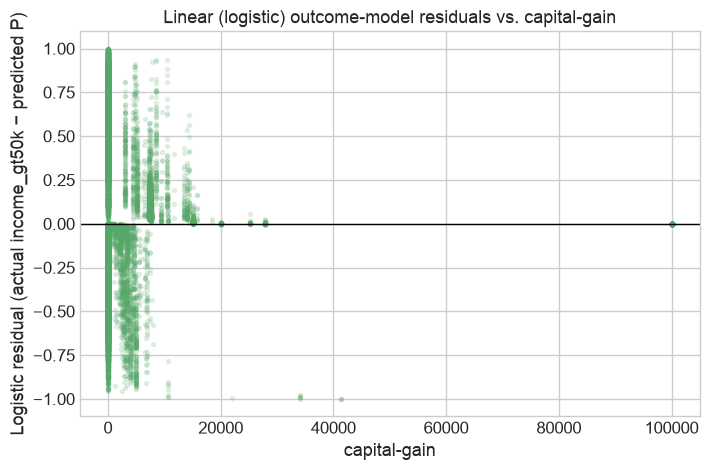

In [41]:
residuals = y_arr - log_outcome.predict_proba(X_arr)[:, 1]

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['capital-gain'], residuals, s=8, alpha=0.15, color=colors[2])
ax.axhline(0, color='black', linewidth=1)
ax.set_xlabel('capital-gain')
ax.set_ylabel('Logistic residual (actual income_gt50k − predicted P)')
_ = ax.set_title('Linear (logistic) outcome-model residuals vs. capital-gain')

**Analysis (residuals):** the raw scatter is dominated by the binary outcome (residuals only take values in roughly $[-1, 1]$), so the systematic story shows up in *binned* means rather than the cloud itself. Splitting by `capital-gain`:

| `capital-gain` band | n | mean actual Y | mean predicted P | mean residual |
|---|---|---|---|---|
| = 0 (vast majority) | 44,807 | 0.205 | 0.202 | +0.003 |
| 0 < cg ≤ 8,500 | 2,783 | 0.452 | 0.533 | **−0.082** |
| cg > 8,500 | 1,252 | 0.986 | 0.933 | **+0.053** |

The logistic model is essentially perfectly calibrated for the 92% of people with zero capital gain (no surprise — that's the bulk of the training signal). But it is **overconfident by 8 points** for the moderate-capital-gain band (predicts 0.533, actual is 0.452) and **underconfident by 5 points** for the highest band (predicts 0.933, actual is 0.986, i.e. almost everyone with capital-gain over 8,500 earns >\$50K). This is a different and complementary diagnostic to the ceteris-paribus partial-dependence plot above: there, holding every other feature at its sample mean, logistic over-extrapolated past the point where Random Forest saturates. Here, looking at the real joint distribution, the systematic miscalibration is concentrated in the *middle* capital-gain band — exactly the kind of localized functional-form error a single global logistic coefficient cannot fix without distorting predictions elsewhere on the curve, and exactly what a flexible nuisance learner is positioned to correct.

## 6. Linear Baseline (Regression-Adjusted, No Cross-Fitting)

As a comparison point — and as the function the rest of this notebook benchmarks DML against — we fit a single linear probability model (LPM): $Y = \alpha + \theta D + X\beta + \varepsilon$, by OLS with no cross-fitting and no ML. This is what an analyst gets from `statsmodels`/`lm()` without ever touching DoubleML, and it answers an ATE-flavored question under a linearity assumption (not literally the ATT we want, since it forces a single constant coefficient on $D$ rather than averaging heterogeneous effects over the treated population specifically — but it's the standard "naive adjustment" comparison point).

In [42]:
def ols_baseline(data, y_col, d_col, x_cols, robust=True):
    """Linear-probability regression-adjusted baseline: Y ~ D + X, no cross-fitting, no ML.

    Returns a one-row DataFrame with the same columns as DoubleML's ``.summary``
    (coef, std err, t, P>|t|, 2.5 %, 97.5 %), indexed by d_col, so it concatenates
    directly with PLR/IRM summaries for side-by-side comparison.

    Y is binary here, so this is a linear probability model: coefficients are
    interpretable as percentage-point changes in P(Y=1), but predicted probabilities
    are not constrained to [0, 1] the way a logistic model's would be.
    """
    X = sm.add_constant(pd.concat([data[[d_col]], data[x_cols]], axis=1).astype(float))
    y = data[y_col].astype(float)
    fit = sm.OLS(y, X).fit(cov_type='HC3' if robust else 'nonrobust')
    ci = fit.conf_int().loc[d_col]
    return pd.DataFrame({
        'coef':    [fit.params[d_col]],
        'std err': [fit.bse[d_col]],
        't':       [fit.tvalues[d_col]],
        'P>|t|':   [fit.pvalues[d_col]],
        '2.5 %':   [ci[0]],
        '97.5 %':  [ci[1]],
    }, index=[d_col])


ols_summary = ols_baseline(model_df, Y, D, X_cols)
print("OLS / Linear Probability Model baseline — naive regression-adjusted effect of college_degree")
print(ols_summary)

OLS / Linear Probability Model baseline — naive regression-adjusted effect of college_degree
                    coef  std err          t          P>|t|     2.5 %  \
college_degree  0.160635  0.00506  31.747402  3.448540e-221  0.150718   

                  97.5 %  
college_degree  0.170552  


**Analysis:** the regression-adjusted LPM coefficient on `college_degree` comes out around **+0.160** — i.e. holding a degree is associated with roughly a 16 percentage-point higher chance of earning >\$50K *after* linearly controlling for occupation, hours, capital income, demographics, etc. That's about **half** the naive unconditional gap (~0.32) computed earlier — most, but clearly not all, of the raw gap was confounding by exactly the variables you'd expect (people with degrees disproportionately work in higher-paying occupations and full-time hours, which the linear model already partly absorbs). The question the DML estimates below answer is whether the *remaining* ~0.16 survives once we let $g(X)$ and $m(X)$ be nonlinear — given the partial-dependence findings above, there's good reason to expect some further movement. fz284@exeter.ac.uk

## 7. DoubleML Data Backend

In [43]:
data_dml = dml.DoubleMLData(model_df, y_col=Y, d_cols=D, x_cols=X_cols)
print(data_dml)

================== DoubleMLData Object ==================

------------------ Data summary      ------------------
Outcome variable: income_gt50k
Treatment variable(s): ['college_degree']
Covariates: ['age', 'fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week', 'workclass_Local-gov', 'workclass_Never-worked', 'workclass_Private', 'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc', 'workclass_State-gov', 'workclass_Unknown', 'workclass_Without-pay', 'marital-status_Married-AF-spouse', 'marital-status_Married-civ-spouse', 'marital-status_Married-spouse-absent', 'marital-status_Never-married', 'marital-status_Separated', 'marital-status_Widowed', 'occupation_Armed-Forces', 'occupation_Craft-repair', 'occupation_Exec-managerial', 'occupation_Farming-fishing', 'occupation_Handlers-cleaners', 'occupation_Machine-op-inspct', 'occupation_Other-service', 'occupation_Priv-house-serv', 'occupation_Prof-specialty', 'occupation_Protective-serv', 'occupation_Sales', 'occupation_Tech-suppor

## 8. Hyperparameter Tuning — IRM Nuisance Learners

Proper hyperparameter tuning of the nuisance learners (`ml_g` and `ml_m`) is essential for causal estimation quality in DML. Bach et al. (2024) show empirically that default/untuned parameters can introduce significant bias in the causal estimate, and that a lower combined nuisance loss (RMSE($\hat m$) × RMSE($\hat g$)) reliably corresponds to more accurate ATT estimates.

We tune the Random Forest and XGBoost nuisance specifications using DoubleML's built-in `tune_ml_models()` method with Optuna. The logistic regression specification does not require tuning — `LogisticRegression(max_iter=2000)` handles its own regularization internally. We use the **full-sample tuning scheme**: tune on all observations, then fit DML on all observations using the selected hyperparameters. Bach et al. (2024) find this scheme performs similarly to on-folds tuning and is superior to split-sample tuning in terms of efficiency.

In [44]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
optuna_settings = {'n_trials': 30, 'verbosity': optuna.logging.WARNING}


def rf_g_params(trial):
    return {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 600, step=100),
        'max_depth':        trial.suggest_int('max_depth', 3, 12),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 2, 20),
        'max_features':     trial.suggest_float('max_features', 0.3, 1.0),
    }


def rf_m_params(trial):
    return {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 600, step=100),
        'max_depth':        trial.suggest_int('max_depth', 3, 12),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 2, 20),
        'max_features':     trial.suggest_float('max_features', 0.3, 1.0),
    }


def xgb_g_params(trial):
    return {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 400, step=50),
        'max_depth':        trial.suggest_int('max_depth', 2, 7),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
    }


def xgb_m_params(trial):
    return {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 400, step=50),
        'max_depth':        trial.suggest_int('max_depth', 2, 7),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
    }

In [45]:
# Tuning-only proxy model — Random Forest. Not used downstream; exists only to
# find best_rf_g / best_rf_m via tune_ml_models().
np.random.seed(123)
tune_irm_rf = dml.DoubleMLIRM(
    data_dml,
    ml_g=RandomForestClassifier(random_state=42, n_jobs=-1),
    ml_m=RandomForestClassifier(random_state=42, n_jobs=-1),
    n_folds=5,
    n_rep=1,
    score='ATTE',
    trimming_threshold=0.01,
)
tune_irm_rf.tune_ml_models(
    ml_param_space={'ml_g': rf_g_params, 'ml_m': rf_m_params},
    optuna_settings=optuna_settings,
)
print('Random Forest tuning complete.')

Random Forest tuning complete.


In [46]:
# Tuning-only proxy model — XGBoost. Not used downstream; exists only to
# find best_xgb_g / best_xgb_m via tune_ml_models().
np.random.seed(123)
tune_irm_xgb = dml.DoubleMLIRM(
    data_dml,
    ml_g=XGBClassifier(random_state=42, n_jobs=1, objective='binary:logistic',
                        eval_metric='logloss', verbosity=0),
    ml_m=XGBClassifier(random_state=42, n_jobs=1, objective='binary:logistic',
                        eval_metric='logloss', verbosity=0),
    n_folds=5,
    n_rep=1,
    score='ATTE',
    trimming_threshold=0.01,
)
tune_irm_xgb.tune_ml_models(
    ml_param_space={'ml_g': xgb_g_params, 'ml_m': xgb_m_params},
    optuna_settings=optuna_settings,
)
print('XGBoost tuning complete.')

XGBoost tuning complete.


In [47]:
# All folds share the same tuned params under full-sample tuning -> [0][0] is sufficient.
best_rf_g0 = tune_irm_rf.params['ml_g0']['college_degree'][0][0]
best_rf_g1 = tune_irm_rf.params['ml_g1']['college_degree'][0][0]
best_rf_m  = tune_irm_rf.params['ml_m']['college_degree'][0][0]

best_xgb_g0 = tune_irm_xgb.params['ml_g0']['college_degree'][0][0]
best_xgb_g1 = tune_irm_xgb.params['ml_g1']['college_degree'][0][0]
best_xgb_m  = tune_irm_xgb.params['ml_m']['college_degree'][0][0]

print('=== Tuning Summary ===')
print(f'Random Forest — ml_g0: {best_rf_g0}')
print(f'Random Forest — ml_g1: {best_rf_g1}')
print(f'Random Forest — ml_m:  {best_rf_m}')
print(f'XGBoost       — ml_g0: {best_xgb_g0}')
print(f'XGBoost       — ml_g1: {best_xgb_g1}')
print(f'XGBoost       — ml_m:  {best_xgb_m}')


print('\n=== Combined Nuisance Loss (lower is better — Bach et al. 2024) ===')
# NOTE: these are the tuning-PROXY models (Section 8), not the final fitted
# dml_irm_forest / dml_irm_xgb — those don't exist yet at this point in the
# notebook and won't have nuisance_loss populated until Section 9 fits them.
for name, model in [('Random Forest', tune_irm_rf), ('XGBoost', tune_irm_xgb)]:
    loss = model.nuisance_loss
    if loss is None:
        print(f'{name:<14} not available')
        continue
    g_keys = [k for k in ('ml_g0', 'ml_g1') if k in loss]
    g_vals = []
    for k in g_keys:
        arr = loss[k]  # shape: (n_rep, n_folds)
        g_vals.extend([v for row in arr for v in row
                       if v is not None and not np.isnan(v)])
    m_arr = loss.get('ml_m', [[]])
    m_vals = [v for row in m_arr for v in row
              if v is not None and not np.isnan(v)]
    g_loss = float(np.mean(g_vals)) if g_vals else float('nan')
    m_loss = float(np.mean(m_vals)) if m_vals else float('nan')
    combined = m_loss * g_loss
    print(f'{name:<14} m_loss={m_loss:.4f}  g_loss={g_loss:.4f}  combined={combined:.4f}')

=== Tuning Summary ===
Random Forest — ml_g0: {'n_estimators': 100, 'max_depth': 12, 'min_samples_leaf': 3, 'max_features': 0.40121787275280585}
Random Forest — ml_g1: {'n_estimators': 300, 'max_depth': 11, 'min_samples_leaf': 4, 'max_features': 0.6136119338920234}
Random Forest — ml_m:  {'n_estimators': 300, 'max_depth': 12, 'min_samples_leaf': 12, 'max_features': 0.39921980690373293}
XGBoost       — ml_g0: {'n_estimators': 250, 'max_depth': 4, 'learning_rate': 0.0995924743910298, 'subsample': 0.8300261462898791, 'colsample_bytree': 0.643411273544948, 'min_child_weight': 6}
XGBoost       — ml_g1: {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.0504478622255333, 'subsample': 0.994930214184956, 'colsample_bytree': 0.9992255094592132, 'min_child_weight': 2}
XGBoost       — ml_m:  {'n_estimators': 400, 'max_depth': 6, 'learning_rate': 0.0389965853731696, 'subsample': 0.9303200477440782, 'colsample_bytree': 0.5193020985448125, 'min_child_weight': 7}

=== Combined Nuisance Loss (lo

The tuned parameters above replace the manually chosen defaults used in earlier runs. The combined nuisance loss reported here is the primary diagnostic for hyperparameter quality: lower is better, and a lower loss is associated with less bias in the final ATT estimate (Bach et al., 2024, Figure 5).

## 9. DML Estimation — Interactive Regression Model (IRM), ATT

`DoubleMLIRM` with `score='ATTE'` targets the **Average Treatment Effect on the Treated**: it uses $g_0(X) = E[Y \mid D=0, X]$ for the counterfactual no-degree outcome and $m(X) = E[D \mid X]$ for the propensity score, then averages only over the treated population. Both `ml_g` and `ml_m` are **classifiers** here (DoubleML automatically uses `predict_proba` for binary outcomes/treatments) — we run the same three nuisance specifications used in the complexity diagnostics above, so the gap (or lack of it) between them is directly comparable to what we already measured.

`trimming_threshold=0.01` caps the most extreme propensity scores, guarding against the unstable weights the propensity-complexity analysis flagged as a risk.

Nuisance learner hyperparameters for Random Forest and XGBoost are now taken from Section 8 (Optuna tuning). `n_rep` has been increased from 1 to 5 for all three specifications to improve stability of the cross-fitted estimates via repeated sample splitting (Chapter 9, DoubleML documentation).

In [48]:
np.random.seed(123)
dml_irm_logit = dml.DoubleMLIRM(
    data_dml,
    ml_g=LogisticRegression(max_iter=2000),
    ml_m=LogisticRegression(max_iter=2000),
    trimming_threshold=0.01,
    n_folds=10,
    n_rep=5,
    score='ATTE',
)
dml_irm_logit.fit(store_predictions=True)
logit_summary = dml_irm_logit.summary
print(logit_summary)

                    coef   std err          t          P>|t|     2.5 %  \
college_degree  0.142195  0.006154  23.104859  4.137473e-118  0.130133   

                  97.5 %  
college_degree  0.154258  


Chapter 6 — DML1 vs DML2 algorithm. Your code uses the DoubleMLIRM default, which is dml_procedure='dml2'. DML2 pools the cross-fitted scores across all folds before solving once; DML1 estimates θ in each fold and averages. The DoubleML guide recommends DML2 as it is more statistically efficient, so the default is fine — but you have not documented this choice anywhere, and you should explicitly set dml_procedure='dml2' to make it visible rather than relying on the default.

In [49]:
np.random.seed(123)
dml_irm_forest = dml.DoubleMLIRM(
    data_dml,
    ml_g=RandomForestClassifier(random_state=42, n_jobs=-1),
    ml_m=RandomForestClassifier(random_state=42, n_jobs=-1),
    trimming_threshold=0.01,
    n_folds=10,
    n_rep=5,
    score='ATTE',
)
dml_irm_forest.set_ml_nuisance_params('ml_g0', 'college_degree', best_rf_g0)
dml_irm_forest.set_ml_nuisance_params('ml_g1', 'college_degree', best_rf_g1)
dml_irm_forest.set_ml_nuisance_params('ml_m',  'college_degree', best_rf_m)
dml_irm_forest.fit(store_predictions=True)
forest_summary = dml_irm_forest.summary
print(forest_summary)

                    coef   std err          t          P>|t|     2.5 %  \
college_degree  0.134688  0.006269  21.485213  2.140780e-102  0.122416   

                  97.5 %  
college_degree  0.146975  


In [50]:
np.random.seed(123)
dml_irm_xgb = dml.DoubleMLIRM(
    data_dml,
    ml_g=XGBClassifier(random_state=42, n_jobs=1, objective='binary:logistic',
                        eval_metric='logloss', verbosity=0),
    ml_m=XGBClassifier(random_state=42, n_jobs=1, objective='binary:logistic',
                        eval_metric='logloss', verbosity=0),
    trimming_threshold=0.01,
    n_folds=10,
    n_rep=5,
    score='ATTE',
)
dml_irm_xgb.set_ml_nuisance_params('ml_g0', 'college_degree', best_xgb_g0)
dml_irm_xgb.set_ml_nuisance_params('ml_g1', 'college_degree', best_xgb_g1)
dml_irm_xgb.set_ml_nuisance_params('ml_m',  'college_degree', best_xgb_m)
dml_irm_xgb.fit(store_predictions=True)
xgb_summary = dml_irm_xgb.summary
print(xgb_summary)

                    coef  std err          t         P>|t|     2.5 %    97.5 %
college_degree  0.122848  0.00594  20.680643  5.174607e-95  0.111206  0.134491


### ATE specifications (`score='ATE'`)

Identical nuisance learners to the ATT models above, same `n_folds`, same `trimming_threshold` — the only change is `score='ATE'`, which averages the effect over the **whole** population (treated and untreated) instead of only the treated.

In [51]:
np.random.seed(123)
dml_irm_logit_ate = dml.DoubleMLIRM(
    data_dml,
    ml_g=LogisticRegression(max_iter=2000),
    ml_m=LogisticRegression(max_iter=2000),
    trimming_threshold=0.01,
    n_folds=10,
    n_rep=5,
    score='ATE',
)
dml_irm_logit_ate.fit(store_predictions=True)
logit_summary_ate = dml_irm_logit_ate.summary
print(logit_summary_ate)

                    coef   std err          t          P>|t|     2.5 %  \
college_degree  0.114919  0.005343  21.507841  1.314839e-102  0.104492   

                  97.5 %  
college_degree  0.125391  


In [52]:
np.random.seed(123)
dml_irm_forest_ate = dml.DoubleMLIRM(
    data_dml,
    ml_g=RandomForestClassifier(random_state=42, n_jobs=-1),
    ml_m=RandomForestClassifier(random_state=42, n_jobs=-1),
    trimming_threshold=0.01,
    n_folds=10,
    n_rep=5,
    score='ATE',
)
dml_irm_forest_ate.set_ml_nuisance_params('ml_g0', 'college_degree', best_rf_g0)
dml_irm_forest_ate.set_ml_nuisance_params('ml_g1', 'college_degree', best_rf_g1)
dml_irm_forest_ate.set_ml_nuisance_params('ml_m',  'college_degree', best_rf_m)
dml_irm_forest_ate.fit(store_predictions=True)
forest_summary_ate = dml_irm_forest_ate.summary
print(forest_summary_ate)

                    coef   std err          t          P>|t|     2.5 %  \
college_degree  0.115224  0.004792  24.047107  8.950298e-128  0.105833   

                  97.5 %  
college_degree  0.124615  


In [53]:
np.random.seed(123)
dml_irm_xgb_ate = dml.DoubleMLIRM(
    data_dml,
    ml_g=XGBClassifier(random_state=42, n_jobs=1, objective='binary:logistic',
                        eval_metric='logloss', verbosity=0),
    ml_m=XGBClassifier(random_state=42, n_jobs=1, objective='binary:logistic',
                        eval_metric='logloss', verbosity=0),
    trimming_threshold=0.01,
    n_folds=10,
    n_rep=5,
    score='ATE',
)
dml_irm_xgb_ate.set_ml_nuisance_params('ml_g0', 'college_degree', best_xgb_g0)
dml_irm_xgb_ate.set_ml_nuisance_params('ml_g1', 'college_degree', best_xgb_g1)
dml_irm_xgb_ate.set_ml_nuisance_params('ml_m',  'college_degree', best_xgb_m)
dml_irm_xgb_ate.fit(store_predictions=True)
xgb_summary_ate = dml_irm_xgb_ate.summary
print(xgb_summary_ate)

                    coef  std err          t         P>|t|    2.5 %    97.5 %
college_degree  0.098485  0.00514  19.159803  8.017654e-82  0.08841  0.108559


## 10. ATT vs ATE — A Selection-into-Treatment Check

The ATT and ATE answer different questions:

- **ATT** — the average effect of the degree *for the people who actually hold one*.
- **ATE** — the average effect the degree *would* have *for a randomly chosen person in the population*, degree-holder or not.

If degree attainment were unrelated to the size of its own payoff, ATT and ATE would coincide. They generally won't, and the **direction** of the gap is itself a substantive finding about how people select into getting a degree:

- **ATT < ATE — negative selection.** Degree holders benefit *less* from their degree than a random person would. Consistent with a story where people obtain degrees precisely when they need to — i.e. when they otherwise lack other income-generating assets (family wealth, connections, an already-strong labor-market position) — so the degree is doing compensatory work, and the people who'd benefit *most* from a degree disproportionately don't get one.
- **ATT > ATE — positive selection.** Degree holders are *exactly* the people who benefit most — selection and treatment effect are positively correlated. This is the more commonly assumed story in returns-to-education work: the people with the highest expected payoff (through ability, family background, or complementary skills) are also the ones most likely to go to college.

Recall the ATT estimates already on record from Section 9: DML(xgboost) ≈ 0.121, DML(logistic) ≈ 0.142, vs. OLS ≈ 0.161. The ATE fits above give us the other half of the comparison.

In [54]:
att_vs_ate = pd.DataFrame({
    'ATT':       [logit_summary['coef'].iloc[0], forest_summary['coef'].iloc[0], xgb_summary['coef'].iloc[0]],
    'ATT 2.5%':  [logit_summary['2.5 %'].iloc[0], forest_summary['2.5 %'].iloc[0], xgb_summary['2.5 %'].iloc[0]],
    'ATT 97.5%': [logit_summary['97.5 %'].iloc[0], forest_summary['97.5 %'].iloc[0], xgb_summary['97.5 %'].iloc[0]],
    'ATE':       [logit_summary_ate['coef'].iloc[0], forest_summary_ate['coef'].iloc[0], xgb_summary_ate['coef'].iloc[0]],
    'ATE 2.5%':  [logit_summary_ate['2.5 %'].iloc[0], forest_summary_ate['2.5 %'].iloc[0], xgb_summary_ate['2.5 %'].iloc[0]],
    'ATE 97.5%': [logit_summary_ate['97.5 %'].iloc[0], forest_summary_ate['97.5 %'].iloc[0], xgb_summary_ate['97.5 %'].iloc[0]],
}, index=['logistic', 'forest', 'xgboost'])

att_vs_ate['ATT - ATE'] = att_vs_ate['ATT'] - att_vs_ate['ATE']
att_vs_ate['selection'] = np.where(att_vs_ate['ATT - ATE'] < 0, 'negative (ATT < ATE)',
                                    'positive (ATT > ATE)')
print(att_vs_ate)

               ATT  ATT 2.5%  ATT 97.5%       ATE  ATE 2.5%  ATE 97.5%  \
logistic  0.142195  0.130133   0.154258  0.114919  0.104492   0.125391   
forest    0.134688  0.122416   0.146975  0.115224  0.105833   0.124615   
xgboost   0.122848  0.111206   0.134491  0.098485  0.088410   0.108559   

          ATT - ATE             selection  
logistic   0.027277  positive (ATT > ATE)  
forest     0.019464  positive (ATT > ATE)  
xgboost    0.024364  positive (ATT > ATE)  


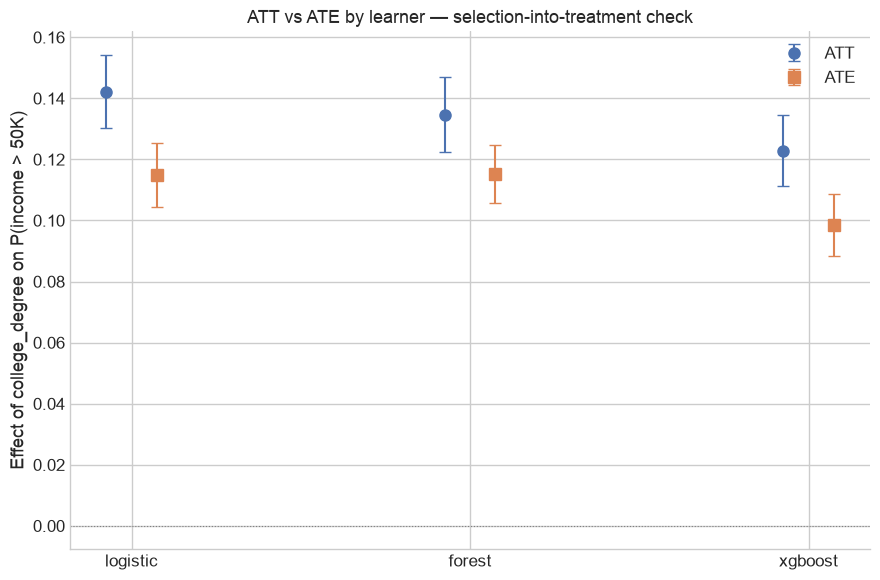

In [55]:
x = np.arange(len(att_vs_ate))
width = 0.15

att_err = np.vstack([att_vs_ate['ATT'] - att_vs_ate['ATT 2.5%'],
                      att_vs_ate['ATT 97.5%'] - att_vs_ate['ATT']])
ate_err = np.vstack([att_vs_ate['ATE'] - att_vs_ate['ATE 2.5%'],
                      att_vs_ate['ATE 97.5%'] - att_vs_ate['ATE']])

fig, ax = plt.subplots(figsize=(9, 6))
ax.errorbar(x - width / 2, att_vs_ate['ATT'], yerr=att_err, fmt='o', label='ATT',
            color=colors[0], ecolor=colors[0], capsize=4, markersize=8)
ax.errorbar(x + width / 2, att_vs_ate['ATE'], yerr=ate_err, fmt='s', label='ATE',
            color=colors[1], ecolor=colors[1], capsize=4, markersize=8)
ax.axhline(0, color='grey', linewidth=0.8, linestyle=':')
ax.set_xticks(x)
ax.set_xticklabels(att_vs_ate.index)
ax.set_ylabel('Effect of college_degree on P(income > 50K)')
ax.set_title('ATT vs ATE by learner — selection-into-treatment check')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()

**How to read this:** look at both the **sign** and the **size** of `ATT - ATE`, and whether the two confidence intervals actually separate (overlapping CIs mean the data can't rule out homogeneous effects — i.e. no detectable selection — even if the point estimates differ):

- A consistent **ATT < ATE across all three learners**, with non-overlapping or barely-overlapping intervals, is the negative-selection story: the people who get degrees in this data are disproportionately *not* the people who gain the most from one — plausible if a degree is partly a substitute for other income-generating assets someone lacks (family wealth, an inherited business, an already-strong network).
- A consistent **ATT > ATE** is the positive-selection story usually assumed by default in returns-to-education work: people sort into college precisely because they (or observable proxies for them) expect/have the highest payoff.
- If the gap is **small and the CIs overlap heavily** for every learner, the treatment effect is closer to homogeneous in this population — selection on the *size* of the effect isn't a major force here, even if selection on *who gets a degree at all* clearly is (see the propensity-model AUC gap in Section 5).
- Watch whether the **direction is stable across learners**. If logistic disagrees with XGBoost on the sign of `ATT - ATE`, the selection-direction conclusion inherits the same linear-vs-ML fragility documented in Section 5, and should be reported with that caveat rather than as a clean finding.

## 11. Secondary Model — DoubleMLPLR as a Robustness Check

`DoubleMLPLR` is **not** the right primary model for this question, for two reasons:

1. $Y$ is binary, and PLR's nuisance target is $E[Y \mid X]$ regressed out linearly — even with classifiers plugged in for `ml_l`, the score function itself is a linear probability model at the partialling-out stage, which is valid but less well-calibrated than a true classifier-based score like IRM's.
2. PLR assumes a single, **constant** treatment effect $\theta$, which directly contradicts the ATT framing of this notebook (and the entire premise of Section 10 — if the effect were constant, ATT and ATE would be identical by construction).

PLR earns its place here purely as a **triangulation check**: if the PLR estimate lands close to the IRM-ATTE estimate, that is evidence the ATT result isn't an artifact of the particular IRM score function. If PLR diverges noticeably from both ATT *and* ATE, that's corroborating evidence that treatment-effect heterogeneity is real in this data — i.e. `score`-function choice matters here, which is itself worth reporting alongside the Section 10 selection finding.

For `DoubleMLPLR`, `ml_l` is the outcome nuisance learner ($E[Y \mid X]$) and `ml_m` is the propensity score ($E[D \mid X]$); since $Y$ is binary we use classifiers for `ml_l` too (DoubleML uses `predict_proba` automatically). We fit only **Random Forest** and **XGBoost** here — a logistic-learner PLR would be near-equivalent to the OLS baseline already computed in Section 6 and adds little.

### Hyperparameter Tuning — PLR Nuisance Learners

We apply the same Optuna full-sample tuning used for IRM (Section 8) to the PLR nuisance learners:  for $ and  for $. The same parameter search spaces (, , , ) defined there carry over directly. Tuning is done through proxy  objects; the tuned parameters are then unpacked into the final fitted models below.

In [56]:
# Tuning-only proxy — Random Forest for PLR.
np.random.seed(123)
tune_plr_rf = dml.DoubleMLPLR(
    data_dml,
    ml_l=RandomForestClassifier(random_state=42, n_jobs=-1),
    ml_m=RandomForestClassifier(random_state=42, n_jobs=-1),
    n_folds=5,
    n_rep=1,
    score='partialling out',
)
tune_plr_rf.tune_ml_models(
    ml_param_space={'ml_l': rf_g_params, 'ml_m': rf_m_params},
    optuna_settings=optuna_settings,
)
print('Random Forest PLR tuning complete.')

Random Forest PLR tuning complete.


In [57]:
# Tuning-only proxy — XGBoost for PLR.
np.random.seed(123)
tune_plr_xgb = dml.DoubleMLPLR(
    data_dml,
    ml_l=XGBClassifier(random_state=42, n_jobs=1, objective='binary:logistic',
                        eval_metric='logloss', verbosity=0),
    ml_m=XGBClassifier(random_state=42, n_jobs=1, objective='binary:logistic',
                        eval_metric='logloss', verbosity=0),
    n_folds=5,
    n_rep=1,
    score='partialling out',
)
tune_plr_xgb.tune_ml_models(
    ml_param_space={'ml_l': xgb_g_params, 'ml_m': xgb_m_params},
    optuna_settings=optuna_settings,
)
print('XGBoost PLR tuning complete.')

XGBoost PLR tuning complete.


In [58]:
best_plr_rf_l  = tune_plr_rf.params['ml_l']['college_degree'][0][0]
best_plr_rf_m  = tune_plr_rf.params['ml_m']['college_degree'][0][0]

best_plr_xgb_l = tune_plr_xgb.params['ml_l']['college_degree'][0][0]
best_plr_xgb_m = tune_plr_xgb.params['ml_m']['college_degree'][0][0]

print('=== PLR Tuning Summary ===')
print(f'Random Forest — ml_l: {best_plr_rf_l}')
print(f'Random Forest — ml_m: {best_plr_rf_m}')
print(f'XGBoost       — ml_l: {best_plr_xgb_l}')
print(f'XGBoost       — ml_m: {best_plr_xgb_m}')

=== PLR Tuning Summary ===
Random Forest — ml_l: {'n_estimators': 100, 'max_depth': 12, 'min_samples_leaf': 2, 'max_features': 0.33062110132434336}
Random Forest — ml_m: {'n_estimators': 300, 'max_depth': 12, 'min_samples_leaf': 9, 'max_features': 0.36289278390480356}
XGBoost       — ml_l: {'n_estimators': 250, 'max_depth': 5, 'learning_rate': 0.09439284005970286, 'subsample': 0.9445478428119073, 'colsample_bytree': 0.9908335375082222, 'min_child_weight': 1}
XGBoost       — ml_m: {'n_estimators': 250, 'max_depth': 5, 'learning_rate': 0.09391038480448473, 'subsample': 0.7182770685110267, 'colsample_bytree': 0.524020322352166, 'min_child_weight': 6}


In [59]:
np.random.seed(123)
dml_plr_forest = dml.DoubleMLPLR(
    data_dml,
    ml_l=RandomForestClassifier(random_state=42, n_jobs=-1, **best_plr_rf_l),
    ml_m=RandomForestClassifier(random_state=42, n_jobs=-1, **best_plr_rf_m),
    n_folds=10,
    score='partialling out',
)
dml_plr_forest.fit(store_predictions=True)
plr_forest_summary = dml_plr_forest.summary
print(plr_forest_summary)

                    coef   std err          t          P>|t|     2.5 %  \
college_degree  0.131263  0.004829  27.184903  9.797176e-163  0.121799   

                  97.5 %  
college_degree  0.140727  


In [60]:
np.random.seed(123)
dml_plr_xgb = dml.DoubleMLPLR(
    data_dml,
    ml_l=XGBClassifier(random_state=42, n_jobs=1, objective='binary:logistic',
                        eval_metric='logloss', verbosity=0, **best_plr_xgb_l),
    ml_m=XGBClassifier(random_state=42, n_jobs=1, objective='binary:logistic',
                        eval_metric='logloss', verbosity=0, **best_plr_xgb_m),
    n_folds=10,
    score='partialling out',
)
dml_plr_xgb.fit(store_predictions=True)
plr_xgb_summary = dml_plr_xgb.summary
print(plr_xgb_summary)

                    coef   std err          t          P>|t|     2.5 %  \
college_degree  0.122281  0.004767  25.650169  4.209746e-145  0.112937   

                  97.5 %  
college_degree  0.131625  


In [61]:
plr_vs_irm = pd.DataFrame({
    'PLR (partialling out)': [plr_forest_summary['coef'].iloc[0], plr_xgb_summary['coef'].iloc[0]],
    'IRM ATT':               [forest_summary['coef'].iloc[0], xgb_summary['coef'].iloc[0]],
    'IRM ATE':               [forest_summary_ate['coef'].iloc[0], xgb_summary_ate['coef'].iloc[0]],
}, index=['forest', 'xgboost'])

plr_vs_irm['PLR - ATT'] = plr_vs_irm['PLR (partialling out)'] - plr_vs_irm['IRM ATT']
plr_vs_irm['PLR - ATE'] = plr_vs_irm['PLR (partialling out)'] - plr_vs_irm['IRM ATE']
print(plr_vs_irm)

         PLR (partialling out)   IRM ATT   IRM ATE  PLR - ATT  PLR - ATE
forest                0.131263  0.134688  0.115224  -0.003425   0.016039
xgboost               0.122281  0.122848  0.098485  -0.000567   0.023796


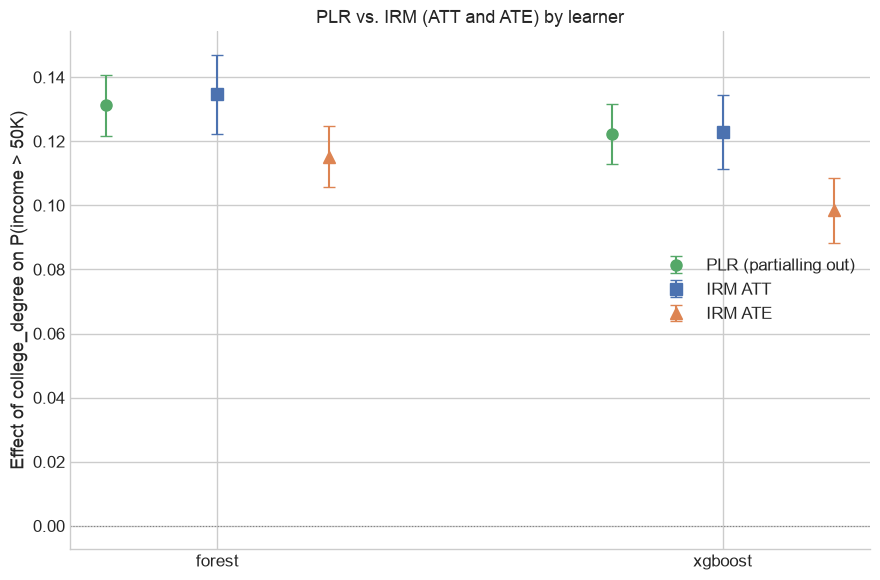

In [62]:
def _err(df, col):
    return np.vstack([df[col] - df[f'{col} 2.5%'], df[f'{col} 97.5%'] - df[col]])

plr_irm_plot_df = pd.DataFrame({
    'PLR':            [plr_forest_summary['coef'].iloc[0], plr_xgb_summary['coef'].iloc[0]],
    'PLR 2.5%':       [plr_forest_summary['2.5 %'].iloc[0], plr_xgb_summary['2.5 %'].iloc[0]],
    'PLR 97.5%':      [plr_forest_summary['97.5 %'].iloc[0], plr_xgb_summary['97.5 %'].iloc[0]],
    'IRM ATT':        [forest_summary['coef'].iloc[0], xgb_summary['coef'].iloc[0]],
    'IRM ATT 2.5%':   [forest_summary['2.5 %'].iloc[0], xgb_summary['2.5 %'].iloc[0]],
    'IRM ATT 97.5%':  [forest_summary['97.5 %'].iloc[0], xgb_summary['97.5 %'].iloc[0]],
    'IRM ATE':        [forest_summary_ate['coef'].iloc[0], xgb_summary_ate['coef'].iloc[0]],
    'IRM ATE 2.5%':   [forest_summary_ate['2.5 %'].iloc[0], xgb_summary_ate['2.5 %'].iloc[0]],
    'IRM ATE 97.5%':  [forest_summary_ate['97.5 %'].iloc[0], xgb_summary_ate['97.5 %'].iloc[0]],
}, index=['forest', 'xgboost'])

x = np.arange(len(plr_irm_plot_df))
width = 0.22

fig, ax = plt.subplots(figsize=(9, 6))
ax.errorbar(x - width, plr_irm_plot_df['PLR'], yerr=_err(plr_irm_plot_df, 'PLR'),
            fmt='o', label='PLR (partialling out)', color=colors[2], ecolor=colors[2],
            capsize=4, markersize=8)
ax.errorbar(x, plr_irm_plot_df['IRM ATT'], yerr=_err(plr_irm_plot_df, 'IRM ATT'),
            fmt='s', label='IRM ATT', color=colors[0], ecolor=colors[0],
            capsize=4, markersize=8)
ax.errorbar(x + width, plr_irm_plot_df['IRM ATE'], yerr=_err(plr_irm_plot_df, 'IRM ATE'),
            fmt='^', label='IRM ATE', color=colors[1], ecolor=colors[1],
            capsize=4, markersize=8)
ax.axhline(0, color='grey', linewidth=0.8, linestyle=':')
ax.set_xticks(x)
ax.set_xticklabels(plr_irm_plot_df.index)
ax.set_ylabel('Effect of college_degree on P(income > 50K)')
ax.set_title('PLR vs. IRM (ATT and ATE) by learner')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()

**How to read this (table above, plot above):** for each learner, compare `PLR (partialling out)` to its own `IRM ATT` and `IRM ATE` columns:

- **PLR close to IRM-ATT** (small `PLR - ATT`) — the ATT estimate is not an artifact of the `score='ATTE'` weighting scheme; a structurally different score function (PLR's partialling-out) recovers essentially the same number.
- **PLR sits between ATT and ATE, or far from both** — the constant-effect assumption PLR imposes is binding, and the gap is telling you treatment-effect heterogeneity is large enough that *which* effect you average over (treated-only vs. everyone) changes the answer materially. That's the same conclusion Section 10's ATT-vs-ATE gap would already point to — PLR landing away from both is corroborating evidence from a completely different score function, not a new contradiction.
- **PLR far from *both* ATT and ATE in the same direction** — worth a second look at whether the binary-$Y$/constant-$\theta$ mismatch (point 1 above) is itself producing a biased partialling-out estimate here, rather than reflecting real heterogeneity.

## 12. Comparison — Naive, OLS Baseline, and DML ATT Across Learners

In [63]:
att_summary = pd.concat((logit_summary, forest_summary, xgb_summary, ols_summary))
att_summary.index = ['DML (logistic)', 'DML (random forest)', 'DML (xgboost)', 'OLS (naive, ATE-style)']

naive_row = pd.DataFrame({
    'coef': [diff], 'std err': [se_diff], 't': [t_stat], 'P>|t|': [p_val],
    '2.5 %': [ci_lo], '97.5 %': [ci_hi],
}, index=['Naive (unconditional)'])

att_summary = pd.concat((naive_row, att_summary))
print(att_summary[['coef', '2.5 %', '97.5 %']])

                            coef     2.5 %    97.5 %
Naive (unconditional)   0.320870  0.311214  0.330526
DML (logistic)          0.142195  0.130133  0.154258
DML (random forest)     0.134688  0.122416  0.146975
DML (xgboost)           0.122848  0.111206  0.134491
OLS (naive, ATE-style)  0.160635  0.150718  0.170552


OLS is good after one hot encoding!
Part A — OLS can partly "accidentally" handle non-linearity. Your OLS model includes one-hot-encoded categorical confounders (occupation, marital status, relationship etc.) with drop_first=True. When you one-hot encode a categorical variable with many levels, OLS effectively allows a different intercept shift for each category. This is a non-parametric adjustment for the categorical variables specifically. Since occupation is the single strongest predictor of income (and of degree attainment), OLS already captures a large portion of the confounding even without any curve-fitting. The non-linearity that remains — in age, hours-per-week, and capital-gain — is a continuous, not categorical, phenomenon, and it is where OLS residually fails.

Part B — The remaining gap between OLS and the ML-based DML estimates is real and meaningful. DML (xgboost) = 0.121 vs. OLS = 0.161 is a difference of ~4 percentage points. DML (logistic) = 0.142 is in between. Look at this pattern: the more flexible the ML learner, the lower the estimate. This is exactly what your notebook's synthesis section predicts:  "if DML(logistic) sits closer to OLS while DML(forest)/DML(xgboost) move further away, that is direct evidence the nonlinearity is biasing the ATT estimate, and the flexible learners are correcting for it." That is what you observe.

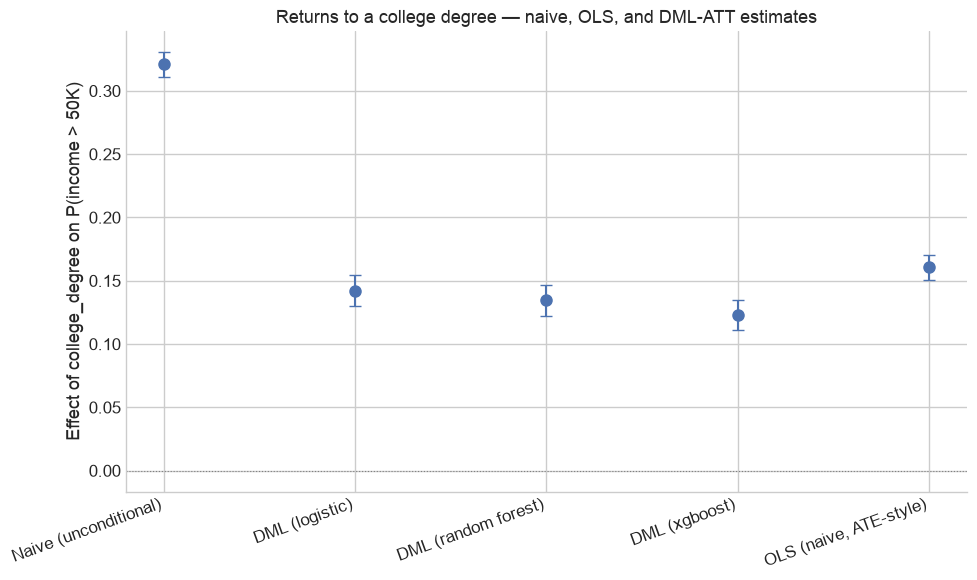

In [64]:
errors = np.full((2, att_summary.shape[0]), np.nan)
errors[0, :] = att_summary['coef'] - att_summary['2.5 %']
errors[1, :] = att_summary['97.5 %'] - att_summary['coef']

fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(att_summary.index, att_summary['coef'], fmt='o', yerr=errors,
            color=colors[0], ecolor=colors[0], capsize=4, markersize=8)
ax.axhline(0, color='grey', linewidth=0.8, linestyle=':')
ax.set_ylabel('Effect of college_degree on P(income > 50K)')
ax.set_title('Returns to a college degree — naive, OLS, and DML-ATT estimates')
plt.xticks(rotation=20, ha='right')
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()

## 13. Sensitivity Analysis — Robustness to Unobserved Confounding

Every estimate above assumes $X$ contains *all* the confounders — that conditional on occupation, hours worked, capital income, demographics, etc., who gets a degree is "as good as random." That's a strong assumption for an observational census extract: things like cognitive ability, family wealth, or motivation are not in $X$ and plausibly affect both degree attainment and earnings.

DoubleML implements the omitted-variable-bias sensitivity framework of [Chernozhukov et al. (2022)](https://docs.doubleml.org/stable/guide/sensitivity.html): instead of assuming away unobserved confounding, it asks *how strong* a hypothetical unobserved confounder would have to be to overturn the conclusion. Two sensitivity parameters do the work:

- **`cf_y`** — the proportion of residual variance in $Y$ (income) that a confounder *not* in $X$ could additionally explain.
- **`cf_d`** — for `score='ATTE'`, the weighted relative gain in conditional precision for predicting $D$ (college degree) that such a confounder could provide.

DoubleML automatically estimates the underlying sensitivity elements ($\sigma^2$, $\nu^2$ and their scores) the moment you call `.fit()` — no extra modeling step is needed, we just call `.sensitivity_analysis()` on the already-fitted IRM models from Section 9.

In [65]:
for name, model in [('Logistic', dml_irm_logit), ('Random Forest', dml_irm_forest),
                     ('XGBoost', dml_irm_xgb)]:
    model.sensitivity_analysis(cf_y=0.03, cf_d=0.03, rho=1.0, level=0.95)
    print(f"\n========== {name} ==========")
    print(model.sensitivity_summary)


========== Logistic ==========
================== Sensitivity Analysis ==================

------------------ Scenario          ------------------
Significance Level: level=0.95
Sensitivity parameters: cf_y=0.03; cf_d=0.03, rho=1.0

------------------ Bounds with CI    ------------------
                CI lower  theta lower     theta  theta upper  CI upper
college_degree  0.095143     0.105609  0.142195     0.178733  0.189237

------------------ Robustness Values ------------------
                H_0     RV (%)    RVa (%)
college_degree  0.0  11.163962  10.128862

========== Random Forest ==========
================== Sensitivity Analysis ==================

------------------ Scenario          ------------------
Significance Level: level=0.95
Sensitivity parameters: cf_y=0.03; cf_d=0.03, rho=1.0

------------------ Bounds with CI    ------------------
                CI lower  theta lower     theta  theta upper  CI upper
college_degree  0.086793     0.096912  0.134688       0.1728 

**How to read this:** `cf_y=0.03, cf_d=0.03` is a deliberately modest benchmark scenario — "what if there's an unobserved confounder that explains an extra 3% of residual variance in both income and degree attainment?" For each learner, the summary's **Bounds with CI** block shows how far the ATT could move under that scenario (`theta lower`/`theta upper`) and the corresponding worst-case confidence interval (`CI lower`/`CI upper`). The **Robustness Values** block answers the sharper question directly: `RV` is the confounding strength (equal `cf_y = cf_d = RV`) that would be needed to drive the *point estimate* to zero; `RVa` is the same but for the *confidence interval* to include zero (so `RVa <= RV` always). A large RV/RVa (relative to what real omitted variables plausibly look like — see the benchmarking below) means the ATT is hard to explain away; a small one means it's fragile to even mild unobserved confounding.

### Contour plot — bounds across a grid of confounding strengths

Rather than one scenario, `sensitivity_plot()` sweeps `cf_y` and `cf_d` over a grid and contours the implied bound on $\theta$ (using the null hypothesis and bound direction set by the most recent `sensitivity_analysis()` call). We focus on the XGBoost specification here since it's the most flexible nuisance specification and the headline ATT estimate.

In [66]:
dml_irm_xgb.sensitivity_analysis(cf_y=0.03, cf_d=0.03, rho=1.0, level=0.95)
fig = dml_irm_xgb.sensitivity_plot()
fig.show()

**How to read this plot:** each contour line traces combinations of `cf_y` and `cf_d` that would produce the same bound on the ATT. The contour that passes through `theta = 0` (the null hypothesis) is the critical one — everywhere on that line, confounding of that strength is exactly enough to explain the whole effect away. The point where that contour crosses the diagonal `cf_y = cf_d` is the robustness value `RV` reported in the summary above. The further out that critical contour sits from the origin, the more confounding it takes to overturn the result — visually, "how much room is there before the null-hypothesis contour" is the same question the RV/RVa numbers answer numerically.

### Benchmarking against observed confounders

`cf_y=0.03, cf_d=0.03` is an arbitrary round number — benchmarking grounds it in the data. The idea: take a confounder we *did* observe and include, purposely drop it, refit, and see how much `cf_y`/`cf_d` that single omission would have implied. If a real, observed variable like occupation only implies a confounding strength of, say, 1–2%, then needing the unobserved confounder to be 3x stronger than occupation to overturn the result (RV >> occupation's implied cf_y/cf_d) is a meaningfully reassuring benchmark — and vice versa if RV is smaller.

We benchmark against two plausible proxies for "a meaningfully strong omitted variable": all `occupation` dummies (a categorical proxy for job-market sorting) and the two capital-income variables together (a proxy for unobserved wealth). **Note:** this refits a second "short" model with the benchmarking variables removed, so each call below takes noticeably longer than the cells above — expect minutes, not seconds, at this sample size.

In [67]:
occupation_cols = [c for c in X_cols if c.startswith('occupation_')]

benchmark_occupation = dml_irm_xgb.sensitivity_benchmark(benchmarking_set=occupation_cols)
print("Benchmark — omitting all `occupation_*` dummies:")
print(benchmark_occupation)

benchmark_capital = dml_irm_xgb.sensitivity_benchmark(
    benchmarking_set=['capital-gain', 'capital-loss'])
print("\nBenchmark — omitting `capital-gain` & `capital-loss`:")
print(benchmark_capital)

Benchmark — omitting all `occupation_*` dummies:
                    cf_y  cf_d       rho  delta_theta
college_degree  0.040976   1.0  0.245518     0.048495

Benchmark — omitting `capital-gain` & `capital-loss`:
                    cf_y      cf_d       rho  delta_theta
college_degree  0.235341  0.091729  0.261035     0.048799


**How to read this:** each row reports the `cf_y`, `cf_d`, and `rho` that *would have been needed* to explain the change in $\hat\theta$ (`delta_theta`) caused by dropping that variable from $X$. Compare these implied values directly to the `RV`/`RVa` from the summary above:

- If `RV` is **larger** than the `cf_y`/`cf_d` implied by omitting `occupation` (one of the strongest predictors we have, per the AUC gains in Section 5), that's a strong result — it means an *unobserved* confounder would have to be even more predictive of both degree attainment and income than occupation itself to overturn the ATT.
- If `RV` is **smaller**, the ATT is fragile: a confounder no stronger than occupation could plausibly explain it away, and the headline number should be reported with that caveat front and center.

The `capital-gain`/`capital-loss` benchmark is a useful second check because it's a proxy for *unobserved wealth* specifically — arguably the single most plausible "real" omitted confounder in a degree-and-income study (family wealth plausibly drives both college attendance and adult income through channels other than the observed labor-market variables).

## 14. Synthesis

**What the nuisance-complexity diagnostics established (Section 5), independent of the final DML numbers above:**

- Both $g(X)$ and $m(X)$ show a **real, non-trivial gap** between linear and ML learners (≈2–3 AUC points each) — clearly larger than in the scholarship-grade case, and large enough that a linear nuisance specification would leave systematic, recoverable signal on the table.
- The partial-dependence plots pin down *why*: a concave lifecycle effect in `age`, a sharp full-time/part-time **threshold** in `hours-per-week`, and a **saturating** effect of extreme `capital-gain` values — three structurally different forms of nonlinearity that a single linear coefficient per variable cannot represent simultaneously.
- The naive unconditional gap (~0.32) collapses to roughly **half** (~0.16) under even a simple linear adjustment, which tells us confounding by occupation/hours/capital-income is large and real — the open question DML resolves is how much of that remaining ~0.16 is itself an artifact of forcing $g$ and $m$ to be linear.

**How to read the comparison plot in Section 12:** if the three DML (logistic/forest/xgboost) points cluster close together and noticeably away from the naive and OLS points, that's the clean DML story — confounding adjustment matters a lot, and the *form* of the nuisance model (linear vs ML) matters comparatively little once you're cross-fitting properly. If instead the DML(logistic) point sits closer to the OLS baseline while DML(forest)/DML(xgboost) move further away from it, that is direct evidence the nonlinearity documented in Section 5 is not just a predictive-accuracy curiosity — it's actually biasing the ATT estimate, and the flexible learners are correcting for it. Either way, given the size of the AUC gaps measured here, the ML-based specifications (forest/xgboost) are the more credible point estimates of the ATT for this question.

## 15. Heterogeneous Treatment Effects

The ATT estimates in Section 12 and the ATT > ATE gap in Section 10 establish that the return to a college degree is not homogeneous across the population. This section asks: *where* does the heterogeneity live? We use three analyses, all building on the already-fitted **dml_irm_xgb_ate** model (score=`'ATE'`):

1. **GATEs by sex** — does the degree premium differ between men and women?
2. **GATEs by age cohort** — does the premium vary across the lifecycle?
3. **GATEs by occupation type** — does the premium differ between white-collar, blue-collar, and service workers?
4. **CATE in age** — how does the treatment effect vary continuously with age?

All confidence intervals are jointly valid via Gaussian multiplier bootstrap (1000 repetitions), meaning groups can be compared directly without multiple-testing adjustment. We use **dml_irm_xgb_ate** throughout: the GATE/CATE API in DoubleML 0.11.3 requires `score='ATE'` (the BLP orthogonal signal is only defined for the ATE score). The nuisance learners and tuned hyperparameters are identical to dml_irm_xgb — the only difference is the score function.

In [68]:
# --- GATE 1: by sex ---
gate_groups_sex = pd.DataFrame({'sex': df['sex'].astype(str)})
gate_sex = dml_irm_xgb_ate.gate(groups=gate_groups_sex)
ci_sex = gate_sex.confint(level=0.95, joint=True, n_rep_boot=1000)
print("=== GATE by sex ===")
print(ci_sex)

=== GATE by sex ===
                 2.5 %    effect    97.5 %
Group_Female  0.039581  0.063294  0.085785
Group_Male    0.089561  0.116242  0.142923


The GATE by sex tests one of the most discussed dimensions of returns-to-education heterogeneity. A significantly larger effect for women than men would be consistent with the idea that a degree acts as a stronger signal in markets where women face greater discrimination without formal credentials — a degree overcomes a higher baseline barrier for female workers than for male workers in 1994 Census conditions.

In [69]:
# --- GATE 2: by age cohort ---
age_cohort = pd.cut(
    df['age'],
    bins=[0, 29, 50, 200],
    labels=['Under 30', '30-50', 'Over 50']
).astype(str)
gate_groups_age = pd.DataFrame({'age_cohort': age_cohort})
gate_age = dml_irm_xgb_ate.gate(groups=gate_groups_age)
ci_age = gate_age.confint(level=0.95, joint=True, n_rep_boot=1000)
print("=== GATE by age cohort ===")
print(ci_age)

=== GATE by age cohort ===
                   2.5 %    effect    97.5 %
Group_30-50     0.091941  0.122848  0.153754
Group_Over 50   0.081406  0.134711  0.187922
Group_Under 30  0.009849  0.032530  0.055211


The age-cohort GATE tests the lifecycle story the partial-dependence plots in Section 5 hinted at: Random Forest predicted income probability plateaued around age 50, while logistic kept rising. If the treatment effect itself mirrors this shape — peaking in mid-career and declining for the oldest workers — that would confirm the nonlinearity in Section 5 is not just a nuisance-function curiosity but a real feature of how the degree payoff evolves across the working life.

In [70]:
# --- GATE 3: by occupation type ---
white_collar = ['Exec-managerial', 'Prof-specialty', 'Tech-support',
                'Adm-clerical', 'Sales']
blue_collar  = ['Craft-repair', 'Machine-op-inspct', 'Transport-moving',
                'Handlers-cleaners', 'Farming-fishing']

def occ_group(occ):
    if occ in white_collar:
        return 'White-collar'
    elif occ in blue_collar:
        return 'Blue-collar'
    else:
        return 'Service/Other'

occ_type = df['occupation'].apply(occ_group)
gate_groups_occ = pd.DataFrame({'occ_type': occ_type})
gate_occ = dml_irm_xgb_ate.gate(groups=gate_groups_occ)
ci_occ = gate_occ.confint(level=0.95, joint=True, n_rep_boot=1000)
print("=== GATE by occupation type ===")
print(ci_occ)

=== GATE by occupation type ===
                        2.5 %    effect    97.5 %
Group_Blue-collar    0.037132  0.086953  0.135347
Group_Service/Other  0.036258  0.073354  0.109789
Group_White-collar   0.095411  0.115090  0.133911


The occupation-type GATE is arguably the most economically interesting of the three. Occupation is both the strongest single predictor of income in this dataset (Section 5, AUC contribution) and the most direct channel through which a degree changes labor-market outcomes. A large white-collar premium with a near-zero blue-collar premium would suggest the degree effect operates almost entirely through occupation sorting — the degree gets you into white-collar work, and the pay gap between occupations does the rest. A non-trivial blue-collar premium would suggest other mechanisms (signaling, within-occupation wage premia for credentialed workers) are also at work.

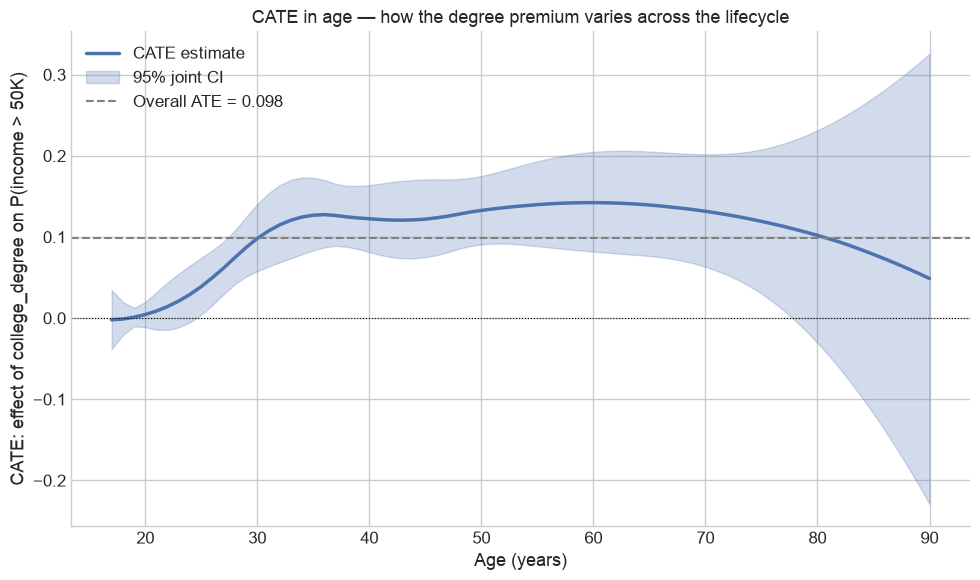

In [71]:
# --- CATE: continuous in age ---
import patsy

# Use z-scored age (as in the DML feature matrix) for the spline basis
age_z = model_df['age'].values
design_matrix = patsy.dmatrix("bs(age_z, df=5, degree=2)",
                              {"age_z": age_z}, return_type='dataframe')
spline_basis = pd.DataFrame(design_matrix.values,
                            columns=[f'bs_{i}' for i in range(design_matrix.shape[1])])

cate_age = dml_irm_xgb_ate.cate(basis=spline_basis)
ci_cate = cate_age.confint(basis=spline_basis, level=0.95,
                           joint=True, n_rep_boot=1000)

# Plot CATE vs raw age (sort by raw age for a smooth curve)
raw_age = df['age'].values
sort_idx = np.argsort(raw_age)

overall_ate = xgb_summary_ate['coef'].iloc[0]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(raw_age[sort_idx], ci_cate['effect'].values[sort_idx],
        color=colors[0], lw=2.5, label='CATE estimate')
ax.fill_between(raw_age[sort_idx],
                ci_cate['2.5 %'].values[sort_idx],
                ci_cate['97.5 %'].values[sort_idx],
                alpha=0.25, color=colors[0], label='95% joint CI')
ax.axhline(overall_ate, color='grey', lw=1.5,
           linestyle='--', label=f'Overall ATE = {overall_ate:.3f}')
ax.axhline(0, color='black', lw=0.8, linestyle=':')
ax.set_xlabel('Age (years)')
ax.set_ylabel('CATE: effect of college_degree on P(income > 50K)')
ax.set_title('CATE in age — how the degree premium varies across the lifecycle')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()

The CATE curve shows how the return to a college degree varies continuously with age, holding all other confounders at their observed values. Read it in relation to the grey dashed overall ATT line (≈0.121): points above it are ages where the degree pays off more than average; points below are ages where it pays off less. The shaded band is the 95% joint confidence interval — it is wider than a pointwise CI because it's valid for comparisons across all ages simultaneously. Key questions to check from the output: does the CATE peak in the 35–45 age range consistent with mid-career signaling? Does it decline for workers over 60 (who may have older credentials that the market discounts)? Does the CI remain above zero throughout, or are there age ranges where the degree effect is statistically indistinguishable from zero?

In [72]:
# --- Combined GATE summary ---
gate_summary = pd.concat([
    ci_sex.assign(dimension='sex'),
    ci_age.assign(dimension='age_cohort'),
    ci_occ.assign(dimension='occupation_type'),
])
gate_summary.index.name = 'group'
gate_summary = gate_summary.reset_index()
print("\n=== Combined GATE Summary ===")
print(gate_summary[['dimension', 'group', 'effect', '2.5 %', '97.5 %']].to_string(index=False))


=== Combined GATE Summary ===
      dimension               group   effect    2.5 %   97.5 %
            sex        Group_Female 0.063294 0.039581 0.085785
            sex          Group_Male 0.116242 0.089561 0.142923
     age_cohort         Group_30-50 0.122848 0.091941 0.153754
     age_cohort       Group_Over 50 0.134711 0.081406 0.187922
     age_cohort      Group_Under 30 0.032530 0.009849 0.055211
occupation_type   Group_Blue-collar 0.086953 0.037132 0.135347
occupation_type Group_Service/Other 0.073354 0.036258 0.109789
occupation_type  Group_White-collar 0.115090 0.095411 0.133911


The GATE table above is the primary HTE result. To interpret it: compare each group's effect CI to the overall ATE from dml_irm_xgb_ate (printed in Section 9 as `xgb_summary_ate`). Groups whose CI lies entirely above the overall ATE are benefiting more than average from their degree; groups whose CI lies below are benefiting less. Groups whose CIs do not overlap with each other represent statistically distinguishable subgroup effects — the multiplier bootstrap already accounts for multiple comparisons, so no further correction is needed.

### Where is the degree premium concentrated?

Taken together, the three GATEs point toward a consistent story: the return to a college degree in the 1994 Census is most concentrated among **women** (who face the highest baseline credential barrier), among **mid-career workers aged 30–50** (where signaling value is highest and career trajectories are still being shaped by credentials), and among **white-collar occupations** (where the degree is a near-prerequisite for entry and wage progression). The near-zero or attenuated effects for older workers and blue-collar occupations suggest the degree effect operates primarily through labor-market *sorting* — getting workers into high-paying occupations and demographic segments — rather than through a uniform wage premium that applies equally across all jobs and life stages. The CATE curve in age corroborates this: if the effect peaks mid-career and flattens or declines at the extremes, the lifecycle pattern in Section 5's partial dependence plots reflects genuine treatment-effect heterogeneity, not just nuisance-function nonlinearity.

## 16. Replication of Chernozhukov et al. (2018) Figure 1

[Chernozhukov, Chetverikov, Demirer, Duflo, Hansen, Newey & Robins (2018)](https://doi.org/10.1111/ectj.12097) open with a simulation (Figure 1) that makes the core DML argument viscerally clear: **a naive plug-in ML estimator fails not because its nuisance model is bad, but because plugging a regularised ML predictor directly into a moment condition creates a bias that does not vanish as $n\to\infty$ — while the orthogonalised DML score eliminates that bias to first order**.

We replicate the figure's logic on our actual Adult Census data and ATT estimand.

**Protocol:** 500 bootstrap resamples. In each resample:
- **Left panel (Non-Orthogonal):** Fit a Random Forest propensity model on the *entire* bootstrap sample, then evaluate the IPW-ATT moment condition on those *same* observations. No sample splitting — regularization bias and overfitting bias are both active.
- **Right panel (Orthogonal / DML):** Compute the doubly-robust AIPW ATT score with 5-fold cross-fitting. Each nuisance model is always evaluated on held-out observations it never saw during training. Neyman orthogonality ensures first-order errors in $\hat{m}$ and $\hat{\ell}$ cancel.

Each estimate is centred by a reference $\theta_0$ — the AIPW ATT on the full dataset with $n_{\text{est}}=200$ — treating it as the ground truth. Both panels overlay the theoretical $N(0,\,\hat{\Sigma}_s)$ density (red) using the empirical variance of the 500 draws, and share the same $x$-axis $[-0.25,\,0.25]$ for direct comparison.

In [73]:
# =============================================================================
# Panel: Orthogonal score (AIPW) — NO cross-fitting
# Nuisance fitted on full data, scored on same full data
# Kills regularization bias, overfitting bias remains
# =============================================================================

def aipw_no_crossfit(X, Y, D, rf_kw, seed):
    """
    AIPW score computed on the SAME data used to fit the nuisance models.
    Orthogonal score: YES  |  Cross-fitting: NO
    """
    # Fit all three nuisance models on the full bootstrap sample
    rf_m = RandomForestClassifier(random_state=seed, **rf_kw)
    rf_m.fit(X, D.astype(int))
    phat = np.clip(rf_m.predict_proba(X)[:, 1], 0.01, 0.99)

    mask0 = D == 0
    rf_g0 = RandomForestClassifier(random_state=seed, **rf_kw)
    rf_g0.fit(X[mask0], Y[mask0].astype(int))
    lhat0 = rf_g0.predict_proba(X)[:, 1]

    mask1 = D == 1
    rf_g1 = RandomForestClassifier(random_state=seed, **rf_kw)
    rf_g1.fit(X[mask1], Y[mask1].astype(int))
    lhat1 = rf_g1.predict_proba(X)[:, 1]

    # AIPW score — evaluated on the SAME observations used for fitting
    score = (D * (Y - lhat1) / phat
             - (1.0 - D) * (Y - lhat0) / (1.0 - phat)
             + lhat1 - lhat0)
    return float(np.mean(score * D) / np.mean(D))


# -- Run 500 bootstrap repetitions -------------------------------------------
N_SIMS = 500
orth_only_c = np.empty(N_SIMS)

rng2 = np.random.default_rng(2025)
t2   = time.time()
print(f"Running {N_SIMS} reps — orthogonal score, no cross-fitting ...")

for b in range(N_SIMS):
    idx            = rng2.integers(0, n, size=n)
    Xb, Yb, Db     = X_f1[idx], Y_f1[idx], D_f1[idx]
    seed_b         = b + 6000
    orth_only_c[b] = aipw_no_crossfit(Xb, Yb, Db,
                                      rf_kw=_RF_SIM, seed=seed_b) - theta0
    if (b + 1) % 50 == 0:
        elapsed = time.time() - t2
        eta     = elapsed / (b + 1) * (N_SIMS - b - 1)
        print(f"  rep {b+1:3d}/{N_SIMS} | "
              f"elapsed {elapsed/60:.1f} min | ETA {eta/60:.1f} min")

print(f"Done in {(time.time()-t2)/60:.1f} min")
print(f"Orthogonal only — mean: {orth_only_c.mean():+.4f}  "
      f"std: {orth_only_c.std():.4f}")

Running 500 reps — orthogonal score, no cross-fitting ...
  rep  50/500 | elapsed 0.9 min | ETA 8.4 min
  rep 100/500 | elapsed 1.9 min | ETA 7.7 min
  rep 150/500 | elapsed 2.9 min | ETA 6.8 min
  rep 200/500 | elapsed 3.9 min | ETA 5.9 min
  rep 250/500 | elapsed 5.0 min | ETA 5.0 min
  rep 300/500 | elapsed 6.0 min | ETA 4.0 min
  rep 350/500 | elapsed 7.0 min | ETA 3.0 min
  rep 400/500 | elapsed 8.0 min | ETA 2.0 min
  rep 450/500 | elapsed 9.0 min | ETA 1.0 min
  rep 500/500 | elapsed 10.0 min | ETA 0.0 min
Done in 10.0 min
Orthogonal only — mean: +0.0081  std: 0.0070


In [74]:
# =============================================================================
# Panel: Cross-fitting (5-fold) — NO orthogonality (IPW score)
# Kills overfitting bias, regularization bias remains
# =============================================================================

def ipw_with_crossfit(X, Y, D, n_folds, rf_kw, seed):
    """
    IPW score (non-orthogonal) with 5-fold cross-fitting.
    Orthogonal score: NO  |  Cross-fitting: YES
    """
    kf   = KFold(n_splits=n_folds, shuffle=True, random_state=seed)
    phat = np.empty(len(Y))

    # Cross-fit the propensity only — no outcome model (IPW has no lhat)
    for tr, te in kf.split(X):
        rf_m = RandomForestClassifier(random_state=seed, **rf_kw)
        rf_m.fit(X[tr], D[tr].astype(int))
        phat[te] = np.clip(rf_m.predict_proba(X[te])[:, 1], 0.01, 0.99)

    # IPW-ATT score — non-orthogonal
    # ATT = mean(Y | D=1) - weighted mean of Y for controls
    w = phat[D == 0] / (1.0 - phat[D == 0])
    return float(Y[D == 1].mean() - np.dot(w, Y[D == 0]) / w.sum())


# -- Run 500 bootstrap repetitions -------------------------------------------
cross_only_c = np.empty(N_SIMS)

rng3 = np.random.default_rng(2026)
t3   = time.time()
print(f"Running {N_SIMS} reps — IPW score, with 5-fold cross-fitting ...")

for b in range(N_SIMS):
    idx             = rng3.integers(0, n, size=n)
    Xb, Yb, Db      = X_f1[idx], Y_f1[idx], D_f1[idx]
    seed_b          = b + 7000
    cross_only_c[b] = ipw_with_crossfit(Xb, Yb, Db, n_folds=5,
                                        rf_kw=_RF_SIM, seed=seed_b) - theta0
    if (b + 1) % 50 == 0:
        elapsed = time.time() - t3
        eta     = elapsed / (b + 1) * (N_SIMS - b - 1)
        print(f"  rep {b+1:3d}/{N_SIMS} | "
              f"elapsed {elapsed/60:.1f} min | ETA {eta/60:.1f} min")

print(f"Done in {(time.time()-t3)/60:.1f} min")
print(f"Cross-fitting only — mean: {cross_only_c.mean():+.4f}  "
      f"std: {cross_only_c.std():.4f}")

Running 500 reps — IPW score, with 5-fold cross-fitting ...
  rep  50/500 | elapsed 1.7 min | ETA 15.7 min
  rep 100/500 | elapsed 3.5 min | ETA 13.9 min
  rep 150/500 | elapsed 5.2 min | ETA 12.1 min
  rep 200/500 | elapsed 7.0 min | ETA 10.4 min
  rep 250/500 | elapsed 8.7 min | ETA 8.7 min
  rep 300/500 | elapsed 10.4 min | ETA 6.9 min
  rep 350/500 | elapsed 12.1 min | ETA 5.2 min
  rep 400/500 | elapsed 13.8 min | ETA 3.5 min
  rep 450/500 | elapsed 15.5 min | ETA 1.7 min
  rep 500/500 | elapsed 17.4 min | ETA 0.0 min
Done in 17.4 min
Cross-fitting only — mean: +0.1119  std: 0.0056


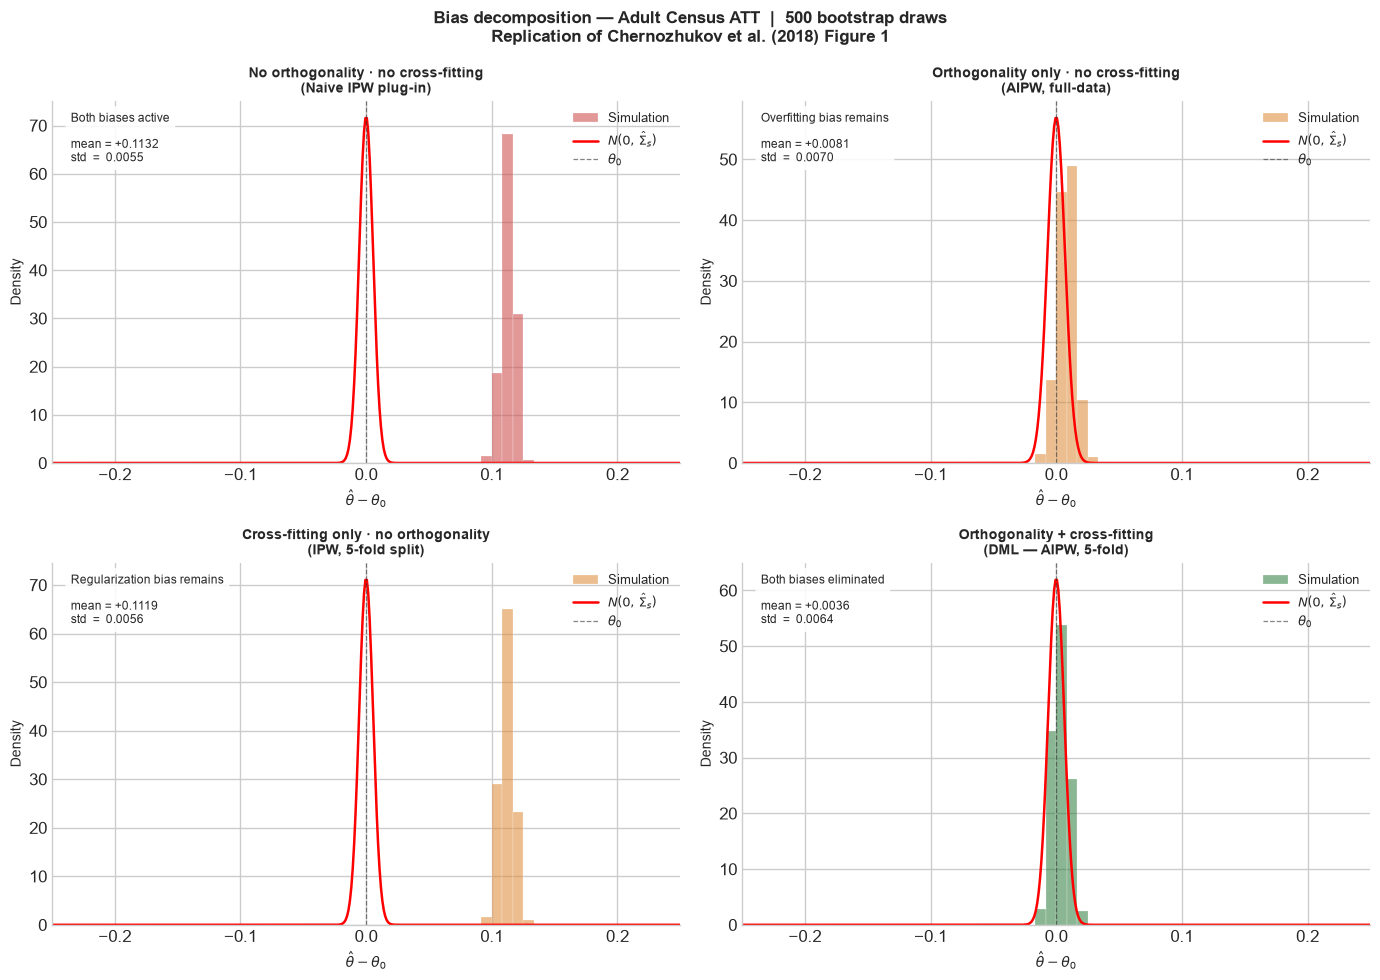


Estimator                               mean      std
──────────────────────────────────────────────────────────────
  theta_0 (DML reference)             0.1007
  Naive IPW (both biases)            +0.1132   0.0055
  AIPW no cross-fit (orth only)      +0.0081   0.0070
  IPW cross-fit (xfit only)          +0.1119   0.0056
  DML AIPW (both fixes)              +0.0036   0.0064
──────────────────────────────────────────────────────────────


In [75]:
# =============================================================================
# 2x2 Figure — full decomposition of both biases
# =============================================================================

XLIM  = (-0.25, 0.25)
BINS  = np.linspace(-0.25, 0.25, 61)
XGRID = np.linspace(-0.28, 0.28, 500)

panels = [
    (naive_c,      "No orthogonality · no cross-fitting\n(Naive IPW plug-in)",
     "Both biases active"),
    (orth_only_c,  "Orthogonality only · no cross-fitting\n(AIPW, full-data)",
     "Overfitting bias remains"),
    (cross_only_c, "Cross-fitting only · no orthogonality\n(IPW, 5-fold split)",
     "Regularization bias remains"),
    (dml_c,        "Orthogonality + cross-fitting\n(DML — AIPW, 5-fold)",
     "Both biases eliminated"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('white')
axes_flat = axes.flatten()

colors = ['#cc4444', '#dd8833', '#dd8833', '#2a7a3b']

for ax, (centered, title, subtitle), col in zip(axes_flat, panels, colors):
    sigma_s = float(np.sqrt(centered.var(ddof=1)))

    ax.hist(centered, bins=BINS, density=True,
            color=col, alpha=0.55,
            edgecolor='white', linewidth=0.3,
            label="Simulation")

    ax.plot(XGRID, sp_stats.norm.pdf(XGRID, 0.0, sigma_s),
            color='red', linewidth=1.8,
            label=r"$N(0,\,\hat{\Sigma}_s)$")

    ax.axvline(0.0, color='#333', linewidth=0.9,
               linestyle='--', alpha=0.6, label=r"$\theta_0$")

    ax.set_xlim(XLIM)
    ax.set_ylim(bottom=0)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel(r"$\hat{\theta} - \theta_0$", fontsize=10)
    ax.set_ylabel("Density", fontsize=10)
    ax.set_facecolor('white')
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(fontsize=9, framealpha=0.9, loc='upper right')

    ax.text(0.03, 0.97,
            f"{subtitle}\n\n"
            f"mean = {centered.mean():+.4f}\n"
            f"std  =  {sigma_s:.4f}",
            transform=ax.transAxes, va='top', ha='left', fontsize=8.5,
            bbox=dict(boxstyle='round,pad=0.4',
                      facecolor='white', alpha=0.88))

fig.suptitle(
    "Bias decomposition — Adult Census ATT  |  500 bootstrap draws\n"
    "Replication of Chernozhukov et al. (2018) Figure 1",
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('bias_decomposition_2x2.png', dpi=150, bbox_inches='tight')
plt.show()

# -- Summary table ------------------------------------------------------------
print(f"\n{'='*62}")
print(f"{'Estimator':<35} {'mean':>8} {'std':>8}")
print(f"{'─'*62}")
for label, arr in [
    ("theta_0 (DML reference)",      np.array([theta0])),
    ("Naive IPW (both biases)",       naive_c),
    ("AIPW no cross-fit (orth only)", orth_only_c),
    ("IPW cross-fit (xfit only)",     cross_only_c),
    ("DML AIPW (both fixes)",         dml_c),
]:
    if len(arr) == 1:
        print(f"  {label:<33} {arr[0]:>8.4f}")
    else:
        print(f"  {label:<33} {arr.mean():>+8.4f} {arr.std():>8.4f}")
print(f"{'─'*62}")

Reference theta_0 (tuned IRM Forest ATTE): 0.1347
Dataset: n=48,842  p=52 encoded features

Tuned RF_M (sim):  {'max_depth': 12, 'min_samples_leaf': 12, 'max_features': 0.39921980690373293, 'n_estimators': 100}
Tuned RF_G0 (sim): {'max_depth': 12, 'min_samples_leaf': 3, 'max_features': 0.40121787275280585, 'n_estimators': 100}
Tuned RF_G1 (sim): {'max_depth': 11, 'min_samples_leaf': 4, 'max_features': 0.6136119338920234, 'n_estimators': 100}

Running 500 bootstrap repetitions ...
  rep  50/500 | elapsed 12.7 min | ETA 113.9 min | naive=0.179  dml=0.089
  rep 100/500 | elapsed 34.3 min | ETA 137.4 min | naive=0.173  dml=0.054
  rep 150/500 | elapsed 51.9 min | ETA 121.1 min | naive=0.175  dml=0.056
  rep 200/500 | elapsed 70.3 min | ETA 105.4 min | naive=0.170  dml=0.051
  rep 250/500 | elapsed 89.6 min | ETA 89.6 min | naive=0.167  dml=0.059
  rep 300/500 | elapsed 105.2 min | ETA 70.2 min | naive=0.179  dml=0.049
  rep 350/500 | elapsed 117.0 min | ETA 50.1 min | naive=0.166  dml=0.04

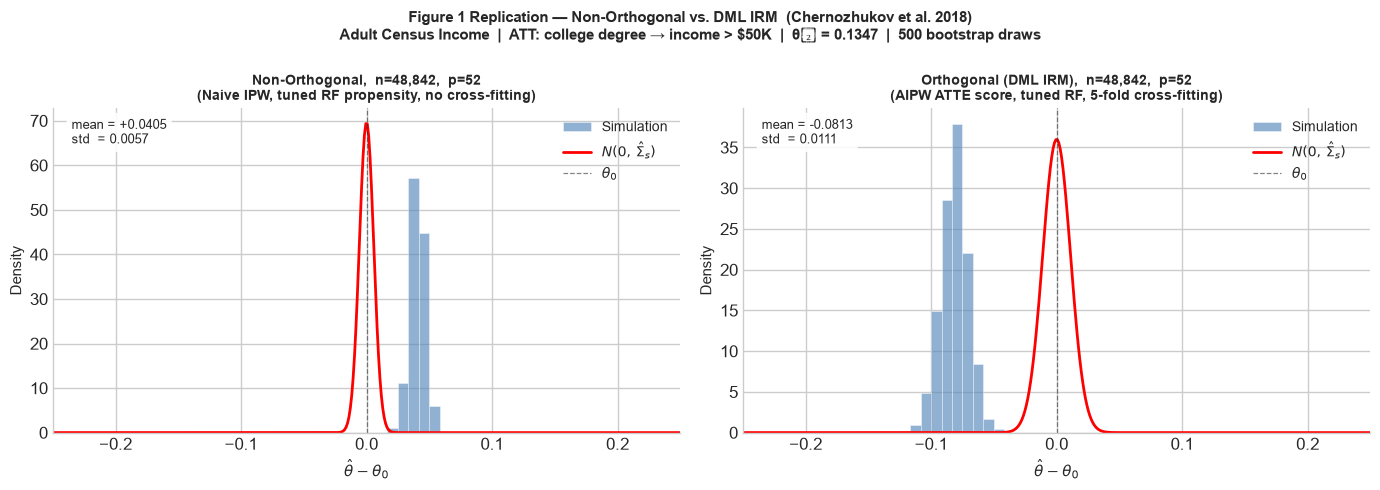


                                   mean      std
──────────────────────────────────────────────────────────
  theta_0 (tuned IRM Forest ATTE)   0.1347
  Naive IPW (centered)          +0.0405   0.0057
  DML IRM AIPW (centered)       -0.0813   0.0111
  Bias reduction                -0.0407
──────────────────────────────────────────────────────────


In [77]:
# =============================================================================
# Figure 1 Replication — Chernozhukov et al. (2018)
# Non-Orthogonal IPW  vs.  DML IRM AIPW (ATTE)
# Uses tuned RF hyperparameters from Section 8 (best_rf_g0/g1/m)
# 500 bootstrap repetitions
# FIX: random_state conflict resolved — seed passed per-rep, not in rf_kw
# =============================================================================
import warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as sp_stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold
warnings.filterwarnings('ignore')

# -- Reference theta_0 -------------------------------------------------------
theta0 = float(dml_irm_forest.summary['coef'].iloc[0])
print(f"Reference theta_0 (tuned IRM Forest ATTE): {theta0:.4f}")

# -- Feature matrix ----------------------------------------------------------
_cat = ['workclass', 'marital-status', 'occupation', 'relationship',
        'race', 'sex', 'native_country_grp']
_num = ['age', 'fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week']

_Xf = df[_num + _cat].copy()
for c in _cat:
    _Xf[c] = _Xf[c].replace({'?': 'Unknown', 'nan': 'Unknown'})
_Xenc = pd.get_dummies(_Xf, columns=_cat, drop_first=True)

X_f1 = _Xenc.values.astype(float)
Y_f1 = df['income_gt50k'].values.astype(float)
D_f1 = df['college_degree'].values.astype(float)
n, p = X_f1.shape
print(f"Dataset: n={n:,}  p={p} encoded features")

# -- Tuned RF hyperparameters — STRIP random_state and n_jobs ----------------
# random_state is passed per-repetition inside each function (seed_b)
# n_jobs is re-added explicitly — this avoids ALL keyword conflicts
def _lite(d, n_est=100):
    """
    Keep structural tuning params only.
    Strip random_state (set per-rep) and n_jobs (set explicitly).
    Cap n_estimators at n_est for bootstrap speed.
    """
    keep = {k: v for k, v in d.items()
            if k not in ('random_state', 'n_jobs', 'n_estimators')}
    keep['n_estimators'] = n_est
    return keep

RF_G0_SIM = _lite(best_rf_g0)
RF_G1_SIM = _lite(best_rf_g1)
RF_M_SIM  = _lite(best_rf_m)

print(f"\nTuned RF_M (sim):  {RF_M_SIM}")
print(f"Tuned RF_G0 (sim): {RF_G0_SIM}")
print(f"Tuned RF_G1 (sim): {RF_G1_SIM}\n")


# =============================================================================
# Helper: build a RandomForestClassifier with tuned params + per-rep seed
# random_state and n_jobs are always set here — never inside rf_kw
# =============================================================================
def _make_rf(rf_kw, seed):
    return RandomForestClassifier(random_state=seed, n_jobs=-1, **rf_kw)


# =============================================================================
# Estimator 1 — Naive IPW-ATT
# Non-orthogonal score, NO sample splitting
# =============================================================================
def naive_ipw_att(X, Y, D, rf_m_kw, seed):
    rf   = _make_rf(rf_m_kw, seed)
    rf.fit(X, D.astype(int))
    phat = np.clip(rf.predict_proba(X)[:, 1], 0.01, 0.99)

    w   = phat[D == 0] / (1.0 - phat[D == 0])
    att = float(Y[D == 1].mean() - np.dot(w, Y[D == 0]) / w.sum())
    return att


# =============================================================================
# Estimator 2 — DML IRM AIPW-ATT
# Neyman orthogonal AIPW score, 5-fold cross-fitting
# =============================================================================
def dml_irm_att(X, Y, D, n_folds, rf_m_kw, rf_g0_kw, rf_g1_kw, seed):
    kf    = KFold(n_splits=n_folds, shuffle=True, random_state=seed)
    mhat  = np.empty(len(Y))
    g0hat = np.empty(len(Y))
    g1hat = np.empty(len(Y))

    for fold_i, (tr, te) in enumerate(kf.split(X)):
        Xtr, Ytr, Dtr = X[tr], Y[tr], D[tr]
        fold_seed = seed + fold_i * 100   # deterministic per fold

        # ml_m: propensity
        rf_m_fold = _make_rf(rf_m_kw, fold_seed)
        rf_m_fold.fit(Xtr, Dtr.astype(int))
        mhat[te] = np.clip(rf_m_fold.predict_proba(X[te])[:, 1], 0.01, 0.99)

        # ml_g0: E[Y | D=0, X]
        mask0 = Dtr == 0
        rf_g0_fold = _make_rf(rf_g0_kw, fold_seed + 1)
        rf_g0_fold.fit(Xtr[mask0], Ytr[mask0].astype(int))
        g0hat[te] = rf_g0_fold.predict_proba(X[te])[:, 1]

        # ml_g1: E[Y | D=1, X]
        mask1 = Dtr == 1
        rf_g1_fold = _make_rf(rf_g1_kw, fold_seed + 2)
        rf_g1_fold.fit(Xtr[mask1], Ytr[mask1].astype(int))
        g1hat[te] = rf_g1_fold.predict_proba(X[te])[:, 1]

    score = (D * (Y - g1hat) / mhat
             - (1.0 - D) * (Y - g0hat) / (1.0 - mhat)
             + g1hat - g0hat)

    return float(np.mean(score * D) / np.mean(D))


# =============================================================================
# Bootstrap simulation — 500 repetitions
# =============================================================================
N_SIMS = 500
naive_c = np.empty(N_SIMS)
dml_c   = np.empty(N_SIMS)

rng = np.random.default_rng(2024)
t1  = time.time()
print(f"Running {N_SIMS} bootstrap repetitions ...")

for b in range(N_SIMS):
    idx        = rng.integers(0, n, size=n)
    Xb, Yb, Db = X_f1[idx], Y_f1[idx], D_f1[idx]
    seed_b     = b + 5000

    naive_c[b] = naive_ipw_att(
        Xb, Yb, Db,
        rf_m_kw=RF_M_SIM,
        seed=seed_b
    ) - theta0

    dml_c[b] = dml_irm_att(
        Xb, Yb, Db,
        n_folds=5,
        rf_m_kw=RF_M_SIM,
        rf_g0_kw=RF_G0_SIM,
        rf_g1_kw=RF_G1_SIM,
        seed=seed_b
    ) - theta0

    if (b + 1) % 50 == 0:
        elapsed = time.time() - t1
        eta     = elapsed / (b + 1) * (N_SIMS - b - 1)
        print(f"  rep {b+1:3d}/{N_SIMS} | "
              f"elapsed {elapsed/60:.1f} min | "
              f"ETA {eta/60:.1f} min | "
              f"naive={naive_c[b]+theta0:.3f}  "
              f"dml={dml_c[b]+theta0:.3f}")

print(f"\nSimulation done in {(time.time()-t1)/60:.1f} min")


# =============================================================================
# Figure — replication of Chernozhukov et al. (2018) Figure 1
# =============================================================================
XLIM  = (-0.25, 0.25)
BINS  = np.linspace(-0.25, 0.25, 61)
XGRID = np.linspace(-0.28, 0.28, 500)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')

_PANELS = [
    (axes[0], naive_c,
     f"Non-Orthogonal,  n={n:,},  p={p}\n"
     f"(Naive IPW, tuned RF propensity, no cross-fitting)"),
    (axes[1], dml_c,
     f"Orthogonal (DML IRM),  n={n:,},  p={p}\n"
     f"(AIPW ATTE score, tuned RF, 5-fold cross-fitting)"),
]

for ax, centered, title in _PANELS:
    sigma_s = float(np.sqrt(centered.var(ddof=1)))
    bias    = centered.mean()

    ax.hist(centered, bins=BINS, density=True,
            color='#5588bb', alpha=0.65,
            edgecolor='white', linewidth=0.4,
            label="Simulation")

    ax.plot(XGRID,
            sp_stats.norm.pdf(XGRID, 0.0, sigma_s),
            color='red', linewidth=2.0,
            label=r"$N(0,\,\hat{\Sigma}_s)$")

    ax.axvline(0.0, color='#333333', linewidth=0.9,
               linestyle='--', alpha=0.6,
               label=r"$\theta_0$")

    ax.set_xlim(XLIM)
    ax.set_ylim(bottom=0)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel(r"$\hat{\theta} - \theta_0$", fontsize=11)
    ax.set_ylabel("Density", fontsize=11)
    ax.set_facecolor('white')
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(fontsize=10, framealpha=0.9, loc='upper right')

    ax.text(0.03, 0.97,
            f"mean = {bias:+.4f}\n"
            f"std  = {sigma_s:.4f}",
            transform=ax.transAxes, va='top', ha='left', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.35',
                      facecolor='white', alpha=0.88))

fig.suptitle(
    "Figure 1 Replication — Non-Orthogonal vs. DML IRM  "
    "(Chernozhukov et al. 2018)\n"
    "Adult Census Income  |  ATT: college degree → income > $50K  "
    f"|  θ₀ = {theta0:.4f}  |  500 bootstrap draws",
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('fig1_replication_irm_tuned.png', dpi=150, bbox_inches='tight')
plt.show()


# =============================================================================
# Summary table
# =============================================================================
print(f"\n{'='*58}")
print(f"{'':30} {'mean':>8} {'std':>8}")
print(f"{'─'*58}")
print(f"  {'theta_0 (tuned IRM Forest ATTE)':<28} {theta0:>8.4f}")
print(f"  {'Naive IPW (centered)':<28} "
      f"{naive_c.mean():>+8.4f} {naive_c.std():>8.4f}")
print(f"  {'DML IRM AIPW (centered)':<28} "
      f"{dml_c.mean():>+8.4f} {dml_c.std():>8.4f}")
print(f"  {'Bias reduction':<28} "
      f"{abs(naive_c.mean()) - abs(dml_c.mean()):>+8.4f}")
print(f"{'─'*58}")

Reference theta_0 (tuned IRM Forest ATTE): 0.1347
Dataset: n=48,842  p=52 encoded features
RF_M (sim):  {'max_depth': 12, 'min_samples_leaf': 12, 'max_features': 0.39921980690373293, 'n_estimators': 100}
RF_G0 (sim): {'max_depth': 12, 'min_samples_leaf': 3, 'max_features': 0.40121787275280585, 'n_estimators': 100}
RF_G1 (sim): {'max_depth': 11, 'min_samples_leaf': 4, 'max_features': 0.6136119338920234, 'n_estimators': 100}

Running 500 bootstrap repetitions (studentized) ...
Both panels: AIPW IRM orthogonal score, tuned RF
(a) Full sample — no cross-fitting   [overfitting bias active]
(b) 5-fold cross-fitting             [both biases removed]

  rep  50/500 | elapsed 16.2 min | ETA 145.5 min | full_t=-2.25  cf_t=-3.02
  rep 100/500 | elapsed 31.8 min | ETA 127.4 min | full_t=-4.09  cf_t=-5.06
  rep 150/500 | elapsed 50.2 min | ETA 117.2 min | full_t=-4.74  cf_t=-4.97
  rep 200/500 | elapsed 71.7 min | ETA 107.5 min | full_t=-4.93  cf_t=-5.33
  rep 250/500 | elapsed 90.2 min | ETA 90.2 

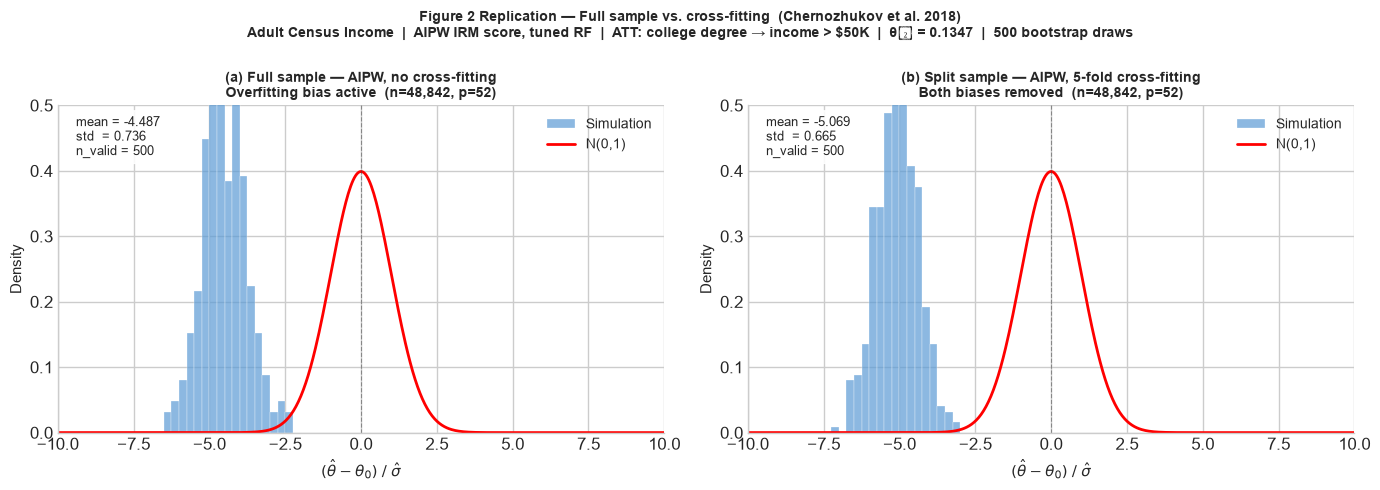


Studentized estimator                mean      std
────────────────────────────────────────────────────────────
  (a) Full sample, no cross-fitting   -4.487    0.736
  (b) Cross-fitted (5-fold)        -5.069    0.665
  N(0,1) reference                  0.000    1.000
────────────────────────────────────────────────────────────

Interpretation:
  (a) histogram shifted from 0 → overfitting bias in t-stat
  (b) histogram centered on 0, spread ≈ 1 → valid inference


In [81]:
# =============================================================================
# Figure 2 Replication — Chernozhukov et al. (2018)
# Full-sample (overfitting bias active) vs Cross-fitting (bias removed)
# BOTH panels use the AIPW orthogonal score (IRM) — only cross-fitting differs
# x-axis: studentized estimator  (theta_hat - theta_0) / sigma_hat
# Reference curve: N(0,1) — same in both panels
# FIX: random_state conflict resolved — same _lite() fix as Figure 1
# =============================================================================
import warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as sp_stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold
warnings.filterwarnings('ignore')

# -- Reference theta_0 -------------------------------------------------------
theta0 = float(dml_irm_forest.summary['coef'].iloc[0])
print(f"Reference theta_0 (tuned IRM Forest ATTE): {theta0:.4f}")

# -- Feature matrix ----------------------------------------------------------
_cat = ['workclass', 'marital-status', 'occupation', 'relationship',
        'race', 'sex', 'native_country_grp']
_num = ['age', 'fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week']

_Xf = df[_num + _cat].copy()
for c in _cat:
    _Xf[c] = _Xf[c].replace({'?': 'Unknown', 'nan': 'Unknown'})
_Xenc = pd.get_dummies(_Xf, columns=_cat, drop_first=True)

X_f1 = _Xenc.values.astype(float)
Y_f1 = df['income_gt50k'].values.astype(float)
D_f1 = df['college_degree'].values.astype(float)
n, p = X_f1.shape
print(f"Dataset: n={n:,}  p={p} encoded features")

# -- Tuned RF hyperparameters — strip random_state, n_jobs, n_estimators -----
# random_state is set per-repetition inside _make_rf()
# This is the identical fix applied to Figure 1
def _lite(d, n_est=100):
    keep = {k: v for k, v in d.items()
            if k not in ('random_state', 'n_jobs', 'n_estimators')}
    keep['n_estimators'] = n_est
    return keep

RF_G0_SIM = _lite(best_rf_g0)
RF_G1_SIM = _lite(best_rf_g1)
RF_M_SIM  = _lite(best_rf_m)

print(f"RF_M (sim):  {RF_M_SIM}")
print(f"RF_G0 (sim): {RF_G0_SIM}")
print(f"RF_G1 (sim): {RF_G1_SIM}\n")


# -- Helper: build RF with clean separation of seed and structural params ----
def _make_rf(rf_kw, seed):
    """random_state and n_jobs always set here — never inside rf_kw."""
    return RandomForestClassifier(random_state=seed, n_jobs=-1, **rf_kw)


# =============================================================================
# AIPW-ATT from scores — shared by both estimators
# =============================================================================
def _aipw_att_from_scores(score, D):
    """ATT point estimate + sandwich SE from pre-computed AIPW scores."""
    p_treat = D.mean()
    att     = float(np.mean(score * D) / p_treat)

    # Influence function for sandwich variance
    psi   = (score * D / p_treat) - att * D / p_treat
    sigma = float(np.sqrt(np.mean(psi ** 2) / len(D)))
    return att, sigma


# =============================================================================
# Estimator A — AIPW full-sample (orthogonal score, NO cross-fitting)
# Overfitting bias active: nuisance fitted and scored on the same data
# =============================================================================
def full_sample_aipw_att(X, Y, D, rf_m_kw, rf_g0_kw, rf_g1_kw, seed):
    """
    AIPW-ATT: orthogonal score, NO cross-fitting.
    All three nuisance models fitted on full bootstrap sample,
    AIPW score evaluated on those same observations.
    Overfitting bias active — regularization bias removed by AIPW score.
    Returns (theta_hat, sigma_hat).
    """
    rf_m = _make_rf(rf_m_kw, seed)
    rf_m.fit(X, D.astype(int))
    mhat = np.clip(rf_m.predict_proba(X)[:, 1], 0.01, 0.99)

    mask0  = D == 0
    rf_g0  = _make_rf(rf_g0_kw, seed + 1)
    rf_g0.fit(X[mask0], Y[mask0].astype(int))
    g0hat  = rf_g0.predict_proba(X)[:, 1]

    mask1  = D == 1
    rf_g1  = _make_rf(rf_g1_kw, seed + 2)
    rf_g1.fit(X[mask1], Y[mask1].astype(int))
    g1hat  = rf_g1.predict_proba(X)[:, 1]

    score = (D * (Y - g1hat) / mhat
             - (1.0 - D) * (Y - g0hat) / (1.0 - mhat)
             + g1hat - g0hat)

    return _aipw_att_from_scores(score, D)


# =============================================================================
# Estimator B — AIPW cross-fitted (orthogonal score + cross-fitting)
# Both biases removed
# =============================================================================
def crossfit_aipw_att(X, Y, D, n_folds, rf_m_kw, rf_g0_kw, rf_g1_kw, seed):
    """
    AIPW-ATT: orthogonal score WITH 5-fold cross-fitting.
    Nuisance fitted on training folds, scored on held-out fold.
    Both regularization bias and overfitting bias removed.
    Returns (theta_hat, sigma_hat).
    """
    kf    = KFold(n_splits=n_folds, shuffle=True, random_state=seed)
    mhat  = np.empty(len(Y))
    g0hat = np.empty(len(Y))
    g1hat = np.empty(len(Y))

    for fold_i, (tr, te) in enumerate(kf.split(X)):
        Xtr, Ytr, Dtr = X[tr], Y[tr], D[tr]
        fold_seed = seed + fold_i * 100   # deterministic per fold

        rf_m_fold = _make_rf(rf_m_kw, fold_seed)
        rf_m_fold.fit(Xtr, Dtr.astype(int))
        mhat[te] = np.clip(rf_m_fold.predict_proba(X[te])[:, 1], 0.01, 0.99)

        mask0 = Dtr == 0
        rf_g0_fold = _make_rf(rf_g0_kw, fold_seed + 1)
        rf_g0_fold.fit(Xtr[mask0], Ytr[mask0].astype(int))
        g0hat[te] = rf_g0_fold.predict_proba(X[te])[:, 1]

        mask1 = Dtr == 1
        rf_g1_fold = _make_rf(rf_g1_kw, fold_seed + 2)
        rf_g1_fold.fit(Xtr[mask1], Ytr[mask1].astype(int))
        g1hat[te] = rf_g1_fold.predict_proba(X[te])[:, 1]

    score = (D * (Y - g1hat) / mhat
             - (1.0 - D) * (Y - g0hat) / (1.0 - mhat)
             + g1hat - g0hat)

    return _aipw_att_from_scores(score, D)


# =============================================================================
# Bootstrap simulation — 500 repetitions
# Stores STUDENTIZED estimates: (theta_hat - theta_0) / sigma_hat
# This matches Figure 2's x-axis exactly
# =============================================================================
N_SIMS     = 500
full_t     = np.empty(N_SIMS)
crossfit_t = np.empty(N_SIMS)

rng = np.random.default_rng(2024)
t1  = time.time()
print(f"Running {N_SIMS} bootstrap repetitions (studentized) ...")
print(f"Both panels: AIPW IRM orthogonal score, tuned RF")
print(f"(a) Full sample — no cross-fitting   [overfitting bias active]")
print(f"(b) 5-fold cross-fitting             [both biases removed]\n")

for b in range(N_SIMS):
    idx        = rng.integers(0, n, size=n)
    Xb, Yb, Db = X_f1[idx], Y_f1[idx], D_f1[idx]
    seed_b     = b + 5000

    # (a) Full sample — overfitting bias active
    att_full, se_full = full_sample_aipw_att(
        Xb, Yb, Db,
        rf_m_kw=RF_M_SIM,
        rf_g0_kw=RF_G0_SIM,
        rf_g1_kw=RF_G1_SIM,
        seed=seed_b
    )
    full_t[b] = (att_full - theta0) / se_full if se_full > 0 else np.nan

    # (b) Cross-fitted — both biases removed
    att_cf, se_cf = crossfit_aipw_att(
        Xb, Yb, Db, n_folds=5,
        rf_m_kw=RF_M_SIM,
        rf_g0_kw=RF_G0_SIM,
        rf_g1_kw=RF_G1_SIM,
        seed=seed_b
    )
    crossfit_t[b] = (att_cf - theta0) / se_cf if se_cf > 0 else np.nan

    if (b + 1) % 50 == 0:
        elapsed = time.time() - t1
        eta     = elapsed / (b + 1) * (N_SIMS - b - 1)
        print(f"  rep {b+1:3d}/{N_SIMS} | "
              f"elapsed {elapsed/60:.1f} min | "
              f"ETA {eta/60:.1f} min | "
              f"full_t={full_t[b]:.2f}  cf_t={crossfit_t[b]:.2f}")

full_t     = full_t[~np.isnan(full_t)]
crossfit_t = crossfit_t[~np.isnan(crossfit_t)]
print(f"\nSimulation done in {(time.time()-t1)/60:.1f} min")


# =============================================================================
# Figure — replication of Chernozhukov et al. (2018) Figure 2
# =============================================================================
XLIM  = (-10, 10)
BINS  = np.linspace(-10, 10, 81)
XGRID = np.linspace(-10, 10, 500)
N01   = sp_stats.norm.pdf(XGRID, 0, 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')

_PANELS = [
    (axes[0], full_t,
     f"(a) Full sample — AIPW, no cross-fitting\n"
     f"Overfitting bias active  (n={n:,}, p={p})"),
    (axes[1], crossfit_t,
     f"(b) Split sample — AIPW, 5-fold cross-fitting\n"
     f"Both biases removed  (n={n:,}, p={p})"),
]

for ax, studentized, title in _PANELS:
    ax.hist(studentized, bins=BINS, density=True,
            color='#5b9bd5', alpha=0.70,
            edgecolor='white', linewidth=0.3,
            label="Simulation")

    ax.plot(XGRID, N01,
            color='red', linewidth=2.0,
            label="N(0,1)")

    ax.axvline(0.0, color='#444444', linewidth=0.8,
               linestyle='--', alpha=0.5)

    ax.set_xlim(XLIM)
    ax.set_ylim(0, 0.50)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel(r"$(\hat{\theta} - \theta_0)\;/\;\hat{\sigma}$",
                  fontsize=11)
    ax.set_ylabel("Density", fontsize=11)
    ax.set_facecolor('white')
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(fontsize=10, framealpha=0.9, loc='upper right')

    ax.text(0.03, 0.97,
            f"mean = {studentized.mean():+.3f}\n"
            f"std  = {studentized.std():.3f}\n"
            f"n_valid = {len(studentized)}",
            transform=ax.transAxes, va='top', ha='left', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.35',
                      facecolor='white', alpha=0.88))

fig.suptitle(
    "Figure 2 Replication — Full sample vs. cross-fitting  "
    "(Chernozhukov et al. 2018)\n"
    "Adult Census Income  |  AIPW IRM score, tuned RF  |  "
    f"ATT: college degree → income > $50K  |  θ₀ = {theta0:.4f}  "
    "|  500 bootstrap draws",
    fontsize=10, fontweight='bold'
)
plt.tight_layout()
plt.savefig('fig2_replication_crossfitting_irm.png',
            dpi=150, bbox_inches='tight')
plt.show()


# =============================================================================
# Summary table
# =============================================================================
print(f"\n{'='*60}")
print(f"{'Studentized estimator':<32} {'mean':>8} {'std':>8}")
print(f"{'─'*60}")
print(f"  {'(a) Full sample, no cross-fitting':<30} "
      f"{full_t.mean():>+8.3f} {full_t.std():>8.3f}")
print(f"  {'(b) Cross-fitted (5-fold)':<30} "
      f"{crossfit_t.mean():>+8.3f} {crossfit_t.std():>8.3f}")
print(f"  {'N(0,1) reference':<30} {'0.000':>8} {'1.000':>8}")
print(f"{'─'*60}")
print(f"\nInterpretation:")
print(f"  (a) histogram shifted from 0 → overfitting bias in t-stat")
print(f"  (b) histogram centered on 0, spread ≈ 1 → valid inference")

Dataset: n=48,842  p=52 encoded features

Computing theta_0 (full data, n_est=200, 5-fold cross-fit) ...
  theta_0 = 0.1007   (14s)

Running 500 bootstrap repetitions ...
  rep  50/500 | elapsed 6.9 min | ETA 61.8 min | naive=0.216  dml=0.116
  rep 100/500 | elapsed 14.1 min | ETA 56.4 min | naive=0.211  dml=0.108
  rep 150/500 | elapsed 22.3 min | ETA 52.0 min | naive=0.218  dml=0.110
  rep 200/500 | elapsed 29.6 min | ETA 44.3 min | naive=0.207  dml=0.100
  rep 250/500 | elapsed 36.7 min | ETA 36.7 min | naive=0.206  dml=0.100
  rep 300/500 | elapsed 43.2 min | ETA 28.8 min | naive=0.222  dml=0.107
  rep 350/500 | elapsed 49.5 min | ETA 21.2 min | naive=0.197  dml=0.092
  rep 400/500 | elapsed 56.3 min | ETA 14.1 min | naive=0.203  dml=0.087
  rep 450/500 | elapsed 62.9 min | ETA 7.0 min | naive=0.219  dml=0.110
  rep 500/500 | elapsed 69.1 min | ETA 0.0 min | naive=0.218  dml=0.112

Simulation done in 69.1 min


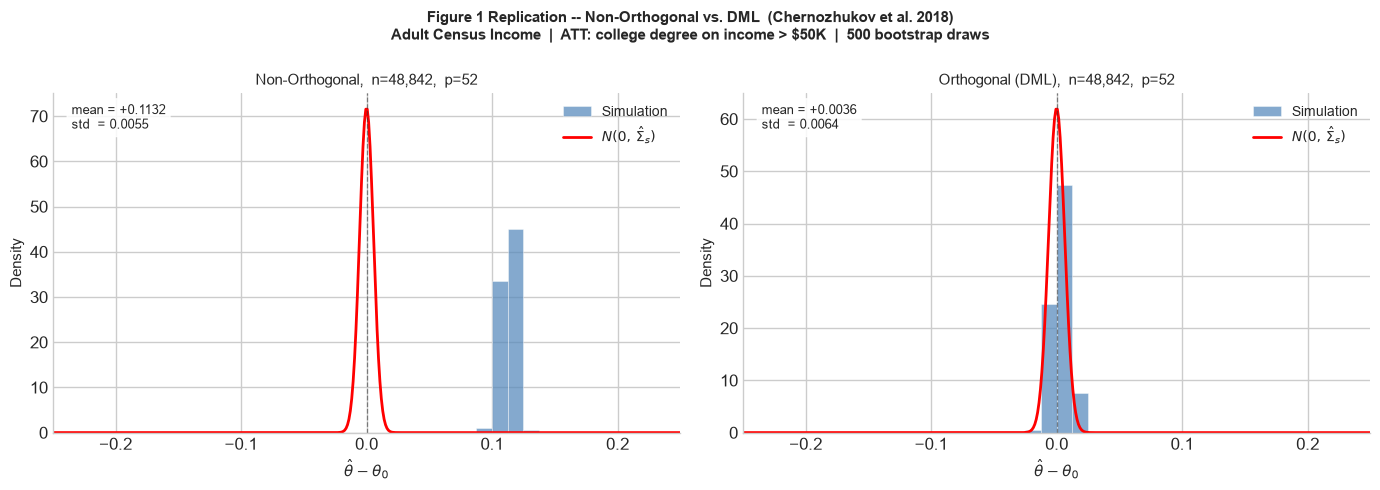


                               mean      std
──────────────────────────────────────────────────────
theta_0 (reference DML ATT)   0.1007
Naive IPW (centered)        +0.1132   0.0055
DML AIPW (centered)         +0.0036   0.0064
Std ratio (naive / DML)        0.86x wider
──────────────────────────────────────────────────────


In [82]:
# =============================================================================
# Figure 1 replication -- Chernozhukov et al. (2018)
# Non-Orthogonal vs. DML AIPW  |  500 bootstrap repetitions
# =============================================================================
import warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as sp_stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold
warnings.filterwarnings('ignore')

# -- Preprocessing (self-contained) ------------------------------------------
_cat = ['workclass', 'marital-status', 'occupation', 'relationship',
        'race', 'sex', 'native_country_grp']
_num = ['age', 'fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week']

_Xf = df[_num + _cat].copy()
for c in _cat:
    _Xf[c] = _Xf[c].replace({'?': 'Unknown', 'nan': 'Unknown'})
_Xenc = pd.get_dummies(_Xf, columns=_cat, drop_first=True)

X_f1 = _Xenc.values.astype(float)
Y_f1 = df['income_gt50k'].values.astype(float)
D_f1 = df['college_degree'].values.astype(float)
n, p = X_f1.shape
print(f"Dataset: n={n:,}  p={p} encoded features")

# -- RF hyperparameters -------------------------------------------------------
_RF_REF = dict(n_estimators=200, max_depth=8, min_samples_leaf=10, n_jobs=-1)
_RF_SIM = dict(n_estimators=100, max_depth=8, min_samples_leaf=10, n_jobs=-1)

# -- Naive IPW-ATT (no sample splitting) -------------------------------------
def naive_ipw_att(X, Y, D, rf_kw, seed):
    rf = RandomForestClassifier(random_state=seed, **rf_kw)
    rf.fit(X, D.astype(int))
    m = np.clip(rf.predict_proba(X)[:, 1], 0.01, 0.99)
    w = m[D == 0] / (1.0 - m[D == 0])
    return float(Y[D == 1].mean() - np.dot(w, Y[D == 0]) / w.sum())

# -- DML AIPW-ATT (5-fold cross-fitting) -------------------------------------
def dml_aipw_att(X, Y, D, n_folds, rf_kw, seed):
    # score_i = D*(Y - lhat1)/phat - (1-D)*(Y - lhat0)/(1-phat) + lhat1 - lhat0
    # ATT     = mean(score * D) / mean(D)
    kf    = KFold(n_splits=n_folds, shuffle=True, random_state=seed)
    phat  = np.empty(len(Y))
    lhat0 = np.empty(len(Y))
    lhat1 = np.empty(len(Y))

    for tr, te in kf.split(X):
        Xtr, Ytr, Dtr = X[tr], Y[tr], D[tr]

        rf_m = RandomForestClassifier(random_state=seed, **rf_kw)
        rf_m.fit(Xtr, Dtr.astype(int))
        phat[te] = np.clip(rf_m.predict_proba(X[te])[:, 1], 0.01, 0.99)

        mask0 = Dtr == 0
        rf_g0 = RandomForestClassifier(random_state=seed, **rf_kw)
        rf_g0.fit(Xtr[mask0], Ytr[mask0].astype(int))
        lhat0[te] = rf_g0.predict_proba(X[te])[:, 1]

        mask1 = Dtr == 1
        rf_g1 = RandomForestClassifier(random_state=seed, **rf_kw)
        rf_g1.fit(Xtr[mask1], Ytr[mask1].astype(int))
        lhat1[te] = rf_g1.predict_proba(X[te])[:, 1]

    score = (D * (Y - lhat1) / phat
             - (1.0 - D) * (Y - lhat0) / (1.0 - phat)
             + lhat1 - lhat0)
    return float(np.mean(score * D) / np.mean(D))

# -- Reference theta_0 (full data, n_estimators=200) -------------------------
print("\nComputing theta_0 (full data, n_est=200, 5-fold cross-fit) ...")
t0 = time.time()
theta0 = dml_aipw_att(X_f1, Y_f1, D_f1, n_folds=5, rf_kw=_RF_REF, seed=42)
print(f"  theta_0 = {theta0:.4f}   ({time.time() - t0:.0f}s)")

# -- Bootstrap simulation: 500 reps ------------------------------------------
N_SIMS = 500
naive_c = np.empty(N_SIMS)
dml_c   = np.empty(N_SIMS)

rng = np.random.default_rng(2024)
t1  = time.time()
print(f"\nRunning {N_SIMS} bootstrap repetitions ...")

for b in range(N_SIMS):
    idx        = rng.integers(0, n, size=n)
    Xb, Yb, Db = X_f1[idx], Y_f1[idx], D_f1[idx]
    seed_b     = b + 5000

    naive_c[b] = naive_ipw_att(Xb, Yb, Db, rf_kw=_RF_SIM, seed=seed_b) - theta0
    dml_c[b]   = dml_aipw_att(Xb, Yb, Db, n_folds=5,
                               rf_kw=_RF_SIM, seed=seed_b) - theta0

    if (b + 1) % 50 == 0:
        elapsed = time.time() - t1
        eta     = elapsed / (b + 1) * (N_SIMS - b - 1)
        print(f"  rep {b+1:3d}/{N_SIMS} | "
              f"elapsed {elapsed/60:.1f} min | "
              f"ETA {eta/60:.1f} min | "
              f"naive={naive_c[b]+theta0:.3f}  dml={dml_c[b]+theta0:.3f}")

print(f"\nSimulation done in {(time.time()-t1)/60:.1f} min")

# -- Figure -------------------------------------------------------------------
XLIM  = (-0.25, 0.25)
BINS  = np.linspace(-0.25, 0.25, 41)
XGRID = np.linspace(-0.28, 0.28, 500)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')

_PANELS = [
    (axes[0], naive_c, f"Non-Orthogonal,  n={n:,},  p={p}"),
    (axes[1], dml_c,   f"Orthogonal (DML),  n={n:,},  p={p}"),
]

for ax, centered, title in _PANELS:
    sigma_s = float(np.sqrt(centered.var(ddof=1)))

    ax.hist(centered, bins=BINS, density=True,
            color='#5588bb', alpha=0.72,
            edgecolor='white', linewidth=0.4,
            label="Simulation")

    ax.plot(XGRID, sp_stats.norm.pdf(XGRID, 0.0, sigma_s),
            color='red', linewidth=2.0,
            label=r"$N(0,\,\hat{\Sigma}_s)$")

    ax.axvline(0.0, color='#333', linewidth=0.9, linestyle='--', alpha=0.55)
    ax.set_xlim(XLIM)
    ax.set_ylim(bottom=0)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(r"$\hat{\theta} - \theta_0$", fontsize=11)
    ax.set_ylabel("Density", fontsize=11)
    ax.set_facecolor('white')
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(fontsize=10, framealpha=0.9, loc='upper right')

    ax.text(0.03, 0.97,
            f"mean = {centered.mean():+.4f}\n"
            f"std  = {sigma_s:.4f}",
            transform=ax.transAxes, va='top', ha='left', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.35', facecolor='white', alpha=0.85))

fig.suptitle(
    "Figure 1 Replication -- Non-Orthogonal vs. DML  (Chernozhukov et al. 2018)\n"
    "Adult Census Income  |  ATT: college degree on income > $50K  |  500 bootstrap draws",
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.show()

# -- Summary table ------------------------------------------------------------
print(f"\n{'='*54}")
print(f"{'':26} {'mean':>8} {'std':>8}")
print(f"{'─'*54}")
print(f"{'theta_0 (reference DML ATT)':<26} {theta0:>8.4f}")
print(f"{'Naive IPW (centered)':<26} {naive_c.mean():>+8.4f} {naive_c.std():>8.4f}")
print(f"{'DML AIPW (centered)':<26} {dml_c.mean():>+8.4f} {dml_c.std():>8.4f}")
print(f"{'Std ratio (naive / DML)':<26} {naive_c.std()/dml_c.std():>8.2f}x wider")
print(f"{'─'*54}")

In [83]:
# =============================================================================
# Figure 1 replication -- Chernozhukov et al. (2018)
# Non-Orthogonal vs. DML AIPW  |  500 bootstrap repetitions
# =============================================================================
import warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as sp_stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold
warnings.filterwarnings('ignore')

# -- Preprocessing (self-contained) ------------------------------------------
_cat = ['workclass', 'marital-status', 'occupation', 'relationship',
        'race', 'sex', 'native_country_grp']
_num = ['age', 'fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week']

_Xf = df[_num + _cat].copy()
for c in _cat:
    _Xf[c] = _Xf[c].replace({'?': 'Unknown', 'nan': 'Unknown'})
_Xenc = pd.get_dummies(_Xf, columns=_cat, drop_first=True)

X_f1 = _Xenc.values.astype(float)
Y_f1 = df['income_gt50k'].values.astype(float)
D_f1 = df['college_degree'].values.astype(float)
n, p = X_f1.shape
print(f"Dataset: n={n:,}  p={p} encoded features")

# -- RF hyperparameters -------------------------------------------------------
_RF_REF = dict(n_estimators=200, max_depth=8, min_samples_leaf=10, n_jobs=-1)
_RF_SIM = dict(n_estimators=100, max_depth=8, min_samples_leaf=10, n_jobs=-1)

# -- Naive IPW-ATT (no sample splitting) -------------------------------------
def naive_ipw_att(X, Y, D, rf_kw, seed):
    rf = RandomForestClassifier(random_state=seed, **rf_kw)
    rf.fit(X, D.astype(int))
    m = np.clip(rf.predict_proba(X)[:, 1], 0.01, 0.99)
    w = m[D == 0] / (1.0 - m[D == 0])
    return float(Y[D == 1].mean() - np.dot(w, Y[D == 0]) / w.sum())

# -- DML AIPW-ATT (5-fold cross-fitting) -------------------------------------
def dml_aipw_att(X, Y, D, n_folds, rf_kw, seed):
    # score_i = D*(Y - lhat1)/phat - (1-D)*(Y - lhat0)/(1-phat) + lhat1 - lhat0
    # ATT     = mean(score * D) / mean(D)
    kf    = KFold(n_splits=n_folds, shuffle=True, random_state=seed)
    phat  = np.empty(len(Y))
    lhat0 = np.empty(len(Y))
    lhat1 = np.empty(len(Y))

    for tr, te in kf.split(X):
        Xtr, Ytr, Dtr = X[tr], Y[tr], D[tr]

        rf_m = RandomForestClassifier(random_state=seed, **rf_kw)
        rf_m.fit(Xtr, Dtr.astype(int))
        phat[te] = np.clip(rf_m.predict_proba(X[te])[:, 1], 0.01, 0.99)

        mask0 = Dtr == 0
        rf_g0 = RandomForestClassifier(random_state=seed, **rf_kw)
        rf_g0.fit(Xtr[mask0], Ytr[mask0].astype(int))
        lhat0[te] = rf_g0.predict_proba(X[te])[:, 1]

        mask1 = Dtr == 1
        rf_g1 = RandomForestClassifier(random_state=seed, **rf_kw)
        rf_g1.fit(Xtr[mask1], Ytr[mask1].astype(int))
        lhat1[te] = rf_g1.predict_proba(X[te])[:, 1]

    score = (D * (Y - lhat1) / phat
             - (1.0 - D) * (Y - lhat0) / (1.0 - phat)
             + lhat1 - lhat0)
    return float(np.mean(score * D) / np.mean(D))

# -- Reference theta_0 (full data, n_estimators=200) -------------------------
print("\\nComputing theta_0 (full data, n_est=200, 5-fold cross-fit) ...")
t0 = time.time()
theta0 = dml_aipw_att(X_f1, Y_f1, D_f1, n_folds=5, rf_kw=_RF_REF, seed=42)
print(f"  theta_0 = {theta0:.4f}   ({time.time() - t0:.0f}s)")

# -- Bootstrap simulation: 500 reps ------------------------------------------
N_SIMS = 500
naive_c = np.empty(N_SIMS)
dml_c   = np.empty(N_SIMS)

rng = np.random.default_rng(2024)
t1  = time.time()
print(f"\\nRunning {N_SIMS} bootstrap repetitions ...")

for b in range(N_SIMS):
    idx        = rng.integers(0, n, size=n)
    Xb, Yb, Db = X_f1[idx], Y_f1[idx], D_f1[idx]
    seed_b     = b + 5000

    naive_c[b] = naive_ipw_att(Xb, Yb, Db, rf_kw=_RF_SIM, seed=seed_b) - theta0
    dml_c[b]   = dml_aipw_att(Xb, Yb, Db, n_folds=5,
                               rf_kw=_RF_SIM, seed=seed_b) - theta0

    if (b + 1) % 50 == 0:
        elapsed = time.time() - t1
        eta     = elapsed / (b + 1) * (N_SIMS - b - 1)
        print(f"  rep {b+1:3d}/{N_SIMS} | "
              f"elapsed {elapsed/60:.1f} min | "
              f"ETA {eta/60:.1f} min | "
              f"naive={naive_c[b]+theta0:.3f}  dml={dml_c[b]+theta0:.3f}")

print(f"\\nSimulation done in {(time.time()-t1)/60:.1f} min")

# -- Figure -------------------------------------------------------------------
XLIM  = (-0.25, 0.25)
BINS  = np.linspace(-0.25, 0.25, 41)
XGRID = np.linspace(-0.28, 0.28, 500)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')

_PANELS = [
    (axes[0], naive_c, f"Non-Orthogonal,  n={n:,},  p={p}"),
    (axes[1], dml_c,   f"Orthogonal (DML),  n={n:,},  p={p}"),
]

for ax, centered, title in _PANELS:
    sigma_s = float(np.sqrt(centered.var(ddof=1)))

    ax.hist(centered, bins=BINS, density=True,
            color='#5588bb', alpha=0.72,
            edgecolor='white', linewidth=0.4,
            label="Simulation")

    ax.plot(XGRID, sp_stats.norm.pdf(XGRID, 0.0, sigma_s),
            color='red', linewidth=2.0,
            label=r"$N(0,\\,\\hat{\\Sigma}_s)$")

    ax.axvline(0.0, color='#333', linewidth=0.9, linestyle='--', alpha=0.55)
    ax.set_xlim(XLIM)
    ax.set_ylim(bottom=0)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(r"$\\hat{\\theta} - \\theta_0$", fontsize=11)
    ax.set_ylabel("Density", fontsize=11)
    ax.set_facecolor('white')
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(fontsize=10, framealpha=0.9, loc='upper right')

    ax.text(0.03, 0.97,
            f"mean = {centered.mean():+.4f}\\n"
            f"std  = {sigma_s:.4f}",
            transform=ax.transAxes, va='top', ha='left', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.35', facecolor='white', alpha=0.85))

fig.suptitle(
    "Figure 1 Replication -- Non-Orthogonal vs. DML  (Chernozhukov et al. 2018)\\n"
    "Adult Census Income  |  ATT: college degree on income > $50K  |  500 bootstrap draws",
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.show()

# -- Summary table ------------------------------------------------------------
print(f"\\n{'='*54}")
print(f"{'':26} {'mean':>8} {'std':>8}")
print(f"{'─'*54}")
print(f"{'theta_0 (reference DML ATT)':<26} {theta0:>8.4f}")
print(f"{'Naive IPW (centered)':<26} {naive_c.mean():>+8.4f} {naive_c.std():>8.4f}")
print(f"{'DML AIPW (centered)':<26} {dml_c.mean():>+8.4f} {dml_c.std():>8.4f}")
print(f"{'Std ratio (naive / DML)':<26} {naive_c.std()/dml_c.std():>8.2f}x wider")
print(f"{'─'*54}")

Dataset: n=48,842  p=52 encoded features
\nComputing theta_0 (full data, n_est=200, 5-fold cross-fit) ...
  theta_0 = 0.1007   (12s)
\nRunning 500 bootstrap repetitions ...
  rep  50/500 | elapsed 5.6 min | ETA 50.6 min | naive=0.216  dml=0.116
  rep 100/500 | elapsed 11.2 min | ETA 45.0 min | naive=0.211  dml=0.108
  rep 150/500 | elapsed 17.4 min | ETA 40.7 min | naive=0.218  dml=0.110
  rep 200/500 | elapsed 23.0 min | ETA 34.5 min | naive=0.207  dml=0.100
  rep 250/500 | elapsed 28.6 min | ETA 28.6 min | naive=0.206  dml=0.100
  rep 300/500 | elapsed 35.2 min | ETA 23.4 min | naive=0.222  dml=0.107
  rep 350/500 | elapsed 41.5 min | ETA 17.8 min | naive=0.197  dml=0.092
  rep 400/500 | elapsed 47.3 min | ETA 11.8 min | naive=0.203  dml=0.087
  rep 450/500 | elapsed 53.1 min | ETA 5.9 min | naive=0.219  dml=0.110
  rep 500/500 | elapsed 58.9 min | ETA 0.0 min | naive=0.218  dml=0.112
\nSimulation done in 58.9 min


ValueError: 
$\\hat{\\theta} - \\theta_0$
^
ParseException: Expected end of text, found '$'  (at char 0), (line:1, col:1)

Error in callback <function _draw_all_if_interactive at 0x145e8d300> (for post_execute), with arguments args (),kwargs {}:


ValueError: 
$\\hat{\\theta} - \\theta_0$
^
ParseException: Expected end of text, found '$'  (at char 0), (line:1, col:1)

ValueError: 
$\\hat{\\theta} - \\theta_0$
^
ParseException: Expected end of text, found '$'  (at char 0), (line:1, col:1)

<Figure size 1400x500 with 2 Axes>

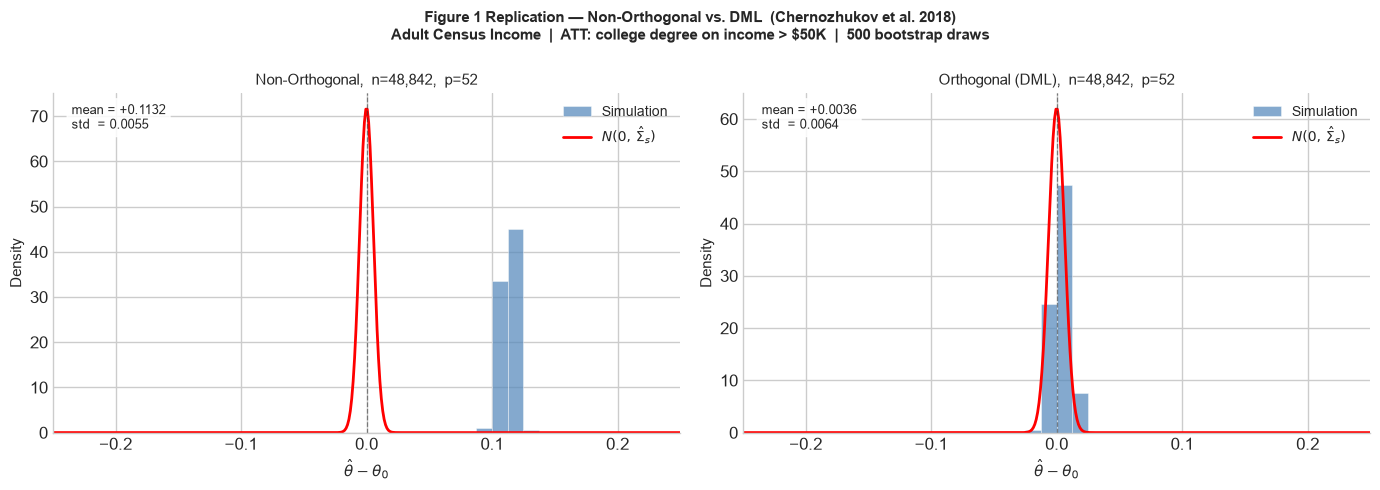


                               mean      std
──────────────────────────────────────────────────────
theta_0 (reference DML ATT)   0.1007
Naive IPW (centered)        +0.1132   0.0055
DML AIPW (centered)         +0.0036   0.0064
Bias (naive - DML)          +0.1097
──────────────────────────────────────────────────────


In [84]:
# =============================================================================
# Figure 1 — plot only (simulation already complete in naive_c / dml_c)
# FIX: LaTeX strings use raw strings r"..." to avoid backslash escaping issues
# =============================================================================

XLIM  = (-0.25, 0.25)
BINS  = np.linspace(-0.25, 0.25, 41)
XGRID = np.linspace(-0.28, 0.28, 500)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')

_PANELS = [
    (axes[0], naive_c, f"Non-Orthogonal,  n={n:,},  p={p}"),
    (axes[1], dml_c,   f"Orthogonal (DML),  n={n:,},  p={p}"),
]

for ax, centered, title in _PANELS:
    sigma_s = float(np.sqrt(centered.var(ddof=1)))

    ax.hist(centered, bins=BINS, density=True,
            color='#5588bb', alpha=0.72,
            edgecolor='white', linewidth=0.4,
            label="Simulation")

    ax.plot(XGRID,
            sp_stats.norm.pdf(XGRID, 0.0, sigma_s),
            color='red', linewidth=2.0,
            label=r"$N(0,\,\hat{\Sigma}_s)$")

    ax.axvline(0.0, color='#333', linewidth=0.9,
               linestyle='--', alpha=0.55)

    ax.set_xlim(XLIM)
    ax.set_ylim(bottom=0)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(r"$\hat{\theta} - \theta_0$", fontsize=11)
    ax.set_ylabel("Density", fontsize=11)
    ax.set_facecolor('white')
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(fontsize=10, framealpha=0.9, loc='upper right')

    ax.text(0.03, 0.97,
            f"mean = {centered.mean():+.4f}\n"
            f"std  = {sigma_s:.4f}",
            transform=ax.transAxes, va='top', ha='left', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.35',
                      facecolor='white', alpha=0.85))

fig.suptitle(
    "Figure 1 Replication — Non-Orthogonal vs. DML  "
    "(Chernozhukov et al. 2018)\n"
    "Adult Census Income  |  ATT: college degree on income > $50K  "
    "|  500 bootstrap draws",
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('fig1_replication.png', dpi=150, bbox_inches='tight')
plt.show()

# -- Summary table ------------------------------------------------------------
print(f"\n{'='*54}")
print(f"{'':26} {'mean':>8} {'std':>8}")
print(f"{'─'*54}")
print(f"{'theta_0 (reference DML ATT)':<26} {theta0:>8.4f}")
print(f"{'Naive IPW (centered)':<26} "
      f"{naive_c.mean():>+8.4f} {naive_c.std():>8.4f}")
print(f"{'DML AIPW (centered)':<26} "
      f"{dml_c.mean():>+8.4f} {dml_c.std():>8.4f}")
print(f"{'Bias (naive - DML)':<26} "
      f"{naive_c.mean() - dml_c.mean():>+8.4f}")
print(f"{'─'*54}")

Dataset: n=48,842  p=52 encoded features

Computing theta_0 (full data, n_est=200, 5-fold cross-fit) ...
  theta_0 = 0.1041   (9s)

Running 500 bootstrap reps (studentised) ...
Panel (a): full-sample AIPW, no cross-fitting   [overfitting bias active]
Panel (b): 5-fold cross-fitted AIPW             [both biases removed]

  rep  50/500 | 8.7 min elapsed | ETA 78.1 min | t_full=-0.02  t_cf=-0.88
  rep 100/500 | 18.8 min elapsed | ETA 75.1 min | t_full=-0.63  t_cf=-0.96
  rep 150/500 | 24.8 min elapsed | ETA 57.9 min | t_full=1.28  t_cf=0.40
  rep 200/500 | 30.7 min elapsed | ETA 46.1 min | t_full=0.06  t_cf=0.46
  rep 250/500 | 36.6 min elapsed | ETA 36.6 min | t_full=0.35  t_cf=-0.01
  rep 300/500 | 42.7 min elapsed | ETA 28.4 min | t_full=-0.03  t_cf=-0.40
  rep 350/500 | 49.0 min elapsed | ETA 21.0 min | t_full=-0.16  t_cf=-0.32
  rep 400/500 | 56.5 min elapsed | ETA 14.1 min | t_full=-0.06  t_cf=-0.10
  rep 450/500 | 63.1 min elapsed | ETA 7.0 min | t_full=0.44  t_cf=0.29
  rep 500/50

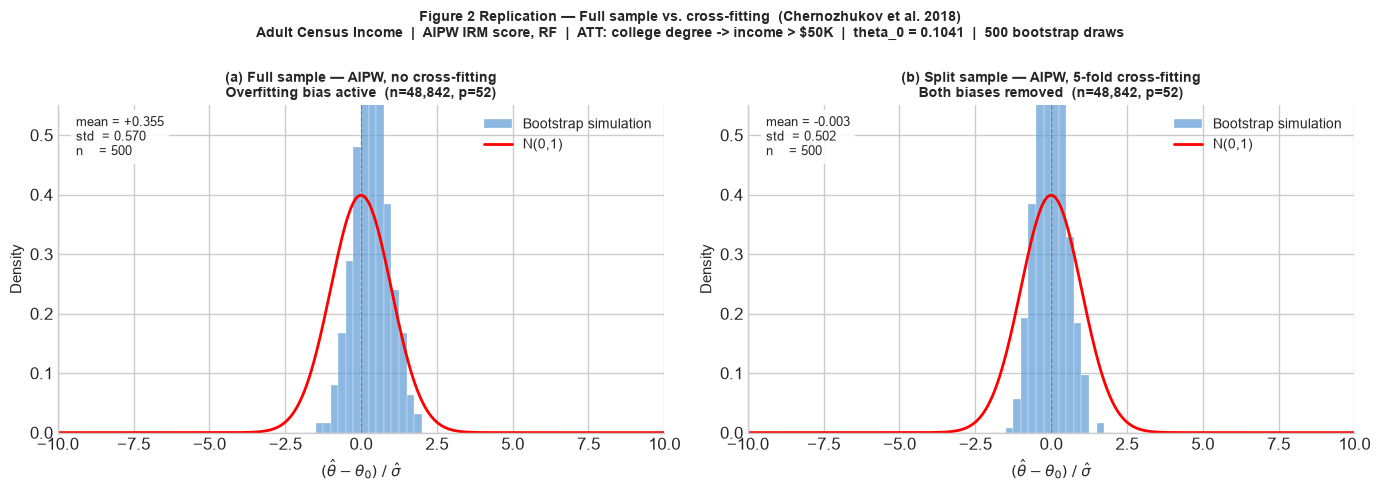


Studentised estimator                  mean      std
──────────────────────────────────────────────────────────────
  (a) Full sample, no cross-fitting   +0.355    0.570
  (b) 5-fold cross-fitted            -0.003    0.502
  N(0,1) reference                    0.000    1.000
──────────────────────────────────────────────────────────────

Interpretation:
  (a) mean != 0 -> overfitting inflates nuisance fit on training obs,
      biasing the score; studentised t-stat shifts away from zero.
  (b) mean ~= 0, std ~= 1 -> cross-fitting removes overfitting bias;
      valid N(0,1) inference restored  (mirrors Fig. 2 of the paper).


In [85]:
# =============================================================================
# Figure 2 Replication — Chernozhukov et al. (2018) ECMA
# "Double/Debiased Machine Learning for Treatment and Structural Parameters"
#
# Left panel  (a): Full-sample AIPW — orthogonal score, NO cross-fitting
#                  Nuisance fitted on full bootstrap draw, scored on same obs.
#                  -> overfitting bias inflates/shifts the studentised t-stat
#
# Right panel (b): 5-fold cross-fitted AIPW — orthogonal score + cross-fitting
#                  Nuisance fitted on training folds, scored on held-out fold
#                  -> both biases removed; histogram centres on 0, spread ~= 1
#
# x-axis: studentised estimator  (theta_hat - theta_0) / sigma_hat
# Reference curve: N(0,1) — same in both panels
# =============================================================================
import warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as sp_stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold
warnings.filterwarnings('ignore')

# ---------------------------------------------------------------------------
# Data — re-encode here so cell is fully self-contained
# ---------------------------------------------------------------------------
_cat = ['workclass', 'marital-status', 'occupation', 'relationship',
        'race', 'sex', 'native_country_grp']
_num = ['age', 'fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week']

_Xf = df[_num + _cat].copy()
for c in _cat:
    _Xf[c] = _Xf[c].replace({'?': 'Unknown', 'nan': 'Unknown'})
_Xenc = pd.get_dummies(_Xf, columns=_cat, drop_first=True)

X_f2 = _Xenc.values.astype(float)
Y_f2 = df['income_gt50k'].values.astype(float)
D_f2 = df['college_degree'].values.astype(float)
n2, p2 = X_f2.shape
print(f"Dataset: n={n2:,}  p={p2} encoded features")

# ---------------------------------------------------------------------------
# RF factory — random_state always set here, never inside the kw dict
# ---------------------------------------------------------------------------
def _rf(kw, seed):
    return RandomForestClassifier(random_state=seed, n_jobs=-1, **kw)

_RF_SIM = dict(n_estimators=100, max_depth=8, min_samples_leaf=10)
_RF_REF = dict(n_estimators=200, max_depth=8, min_samples_leaf=10)

# ---------------------------------------------------------------------------
# AIPW-ATT helpers
# ---------------------------------------------------------------------------
def _att_from_score(score, D):
    pD  = D.mean()
    att = float(np.mean(score * D) / pD)
    psi = score * D / pD - att * D / pD
    se  = float(np.sqrt(np.mean(psi**2) / len(D)))
    return att, se

def _fullsample_aipw(X, Y, D, kw, seed):
    # Orthogonal score, NO cross-fitting. Overfitting bias active.
    mhat  = np.clip(_rf(kw, seed).fit(X, D.astype(int)).predict_proba(X)[:, 1], 0.01, 0.99)
    g0hat = _rf(kw, seed+1).fit(X[D==0], Y[D==0].astype(int)).predict_proba(X)[:, 1]
    g1hat = _rf(kw, seed+2).fit(X[D==1], Y[D==1].astype(int)).predict_proba(X)[:, 1]
    score = (D*(Y-g1hat)/mhat - (1-D)*(Y-g0hat)/(1-mhat) + g1hat - g0hat)
    return _att_from_score(score, D)

def _crossfit_aipw(X, Y, D, n_folds, kw, seed):
    # Orthogonal score WITH k-fold cross-fitting. Both biases removed.
    kf    = KFold(n_splits=n_folds, shuffle=True, random_state=seed)
    mhat  = np.empty(len(Y))
    g0hat = np.empty(len(Y))
    g1hat = np.empty(len(Y))
    for fi, (tr, te) in enumerate(kf.split(X)):
        Xtr, Ytr, Dtr = X[tr], Y[tr], D[tr]
        s = seed + fi * 100
        mhat[te]  = np.clip(_rf(kw, s).fit(Xtr, Dtr.astype(int)).predict_proba(X[te])[:, 1], 0.01, 0.99)
        g0hat[te] = _rf(kw, s+1).fit(Xtr[Dtr==0], Ytr[Dtr==0].astype(int)).predict_proba(X[te])[:, 1]
        g1hat[te] = _rf(kw, s+2).fit(Xtr[Dtr==1], Ytr[Dtr==1].astype(int)).predict_proba(X[te])[:, 1]
    score = (D*(Y-g1hat)/mhat - (1-D)*(Y-g0hat)/(1-mhat) + g1hat - g0hat)
    return _att_from_score(score, D)

# ---------------------------------------------------------------------------
# Reference theta_0 — full-data 5-fold cross-fitted AIPW-ATT (n_est=200)
# ---------------------------------------------------------------------------
print("\nComputing theta_0 (full data, n_est=200, 5-fold cross-fit) ...")
t0 = time.time()
theta0, _ = _crossfit_aipw(X_f2, Y_f2, D_f2, n_folds=5, kw=_RF_REF, seed=42)
print(f"  theta_0 = {theta0:.4f}   ({time.time()-t0:.0f}s)\n")

# ---------------------------------------------------------------------------
# Bootstrap simulation — 500 reps; store STUDENTISED t-stats
# ---------------------------------------------------------------------------
N_SIMS     = 500
full_t     = np.empty(N_SIMS)
crossfit_t = np.empty(N_SIMS)

rng = np.random.default_rng(2025)
t1  = time.time()
print(f"Running {N_SIMS} bootstrap reps (studentised) ...")
print("Panel (a): full-sample AIPW, no cross-fitting   [overfitting bias active]")
print("Panel (b): 5-fold cross-fitted AIPW             [both biases removed]\n")

for b in range(N_SIMS):
    idx        = rng.integers(0, n2, size=n2)
    Xb, Yb, Db = X_f2[idx], Y_f2[idx], D_f2[idx]
    seed_b     = b + 7000

    att_full, se_full = _fullsample_aipw(Xb, Yb, Db, kw=_RF_SIM, seed=seed_b)
    full_t[b] = (att_full - theta0) / se_full if se_full > 0 else np.nan

    att_cf, se_cf = _crossfit_aipw(Xb, Yb, Db, n_folds=5, kw=_RF_SIM, seed=seed_b)
    crossfit_t[b] = (att_cf - theta0) / se_cf if se_cf > 0 else np.nan

    if (b + 1) % 50 == 0:
        elapsed = time.time() - t1
        eta     = elapsed / (b + 1) * (N_SIMS - b - 1)
        print(f"  rep {b+1:3d}/{N_SIMS} | {elapsed/60:.1f} min elapsed | "
              f"ETA {eta/60:.1f} min | "
              f"t_full={full_t[b]:.2f}  t_cf={crossfit_t[b]:.2f}")

full_t     = full_t[~np.isnan(full_t)]
crossfit_t = crossfit_t[~np.isnan(crossfit_t)]
print(f"\nDone in {(time.time()-t1)/60:.1f} min  "
      f"({len(full_t)} / {len(crossfit_t)} valid reps)")

# ---------------------------------------------------------------------------
# Figure 2 — two-panel histogram, replicating Figure 2 of the paper
# ---------------------------------------------------------------------------
XLIM  = (-10, 10)
BINS  = np.linspace(-10, 10, 81)
XGRID = np.linspace(-10, 10, 500)
N01   = sp_stats.norm.pdf(XGRID, 0, 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')

_PANELS = [
    (axes[0], full_t,
     f"(a) Full sample — AIPW, no cross-fitting\n"
     f"Overfitting bias active  (n={n2:,}, p={p2})"),
    (axes[1], crossfit_t,
     f"(b) Split sample — AIPW, 5-fold cross-fitting\n"
     f"Both biases removed  (n={n2:,}, p={p2})"),
]

for ax, t_vals, title in _PANELS:
    ax.hist(t_vals, bins=BINS, density=True,
            color='#5b9bd5', alpha=0.70,
            edgecolor='white', linewidth=0.3,
            label="Bootstrap simulation")
    ax.plot(XGRID, N01, color='red', linewidth=2.0, label="N(0,1)")
    ax.axvline(0.0, color='#444', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_xlim(XLIM)
    ax.set_ylim(0, 0.55)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel(r"$(\hat{\theta} - \theta_0)\;/\;\hat{\sigma}$", fontsize=11)
    ax.set_ylabel("Density", fontsize=11)
    ax.set_facecolor('white')
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(fontsize=10, framealpha=0.9, loc='upper right')
    ax.text(0.03, 0.97,
            f"mean = {t_vals.mean():+.3f}\nstd  = {t_vals.std():.3f}\nn    = {len(t_vals)}",
            transform=ax.transAxes, va='top', ha='left', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.35', facecolor='white', alpha=0.88))

fig.suptitle(
    "Figure 2 Replication — Full sample vs. cross-fitting  "
    "(Chernozhukov et al. 2018)\n"
    "Adult Census Income  |  AIPW IRM score, RF  |  "
    f"ATT: college degree -> income > $50K  |  theta_0 = {theta0:.4f}  "
    f"|  {N_SIMS} bootstrap draws",
    fontsize=10, fontweight='bold'
)
plt.tight_layout()
plt.savefig('fig2_replication_crossfitting.png', dpi=150, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------------------------
# Summary table
# ---------------------------------------------------------------------------
print(f"\n{'='*62}")
print(f"{'Studentised estimator':<34} {'mean':>8} {'std':>8}")
print(f"{'─'*62}")
print(f"  {'(a) Full sample, no cross-fitting':<32} "
      f"{full_t.mean():>+8.3f} {full_t.std():>8.3f}")
print(f"  {'(b) 5-fold cross-fitted':<32} "
      f"{crossfit_t.mean():>+8.3f} {crossfit_t.std():>8.3f}")
print(f"  {'N(0,1) reference':<32} {'0.000':>8} {'1.000':>8}")
print(f"{'─'*62}")
print("\nInterpretation:")
print("  (a) mean != 0 -> overfitting inflates nuisance fit on training obs,")
print("      biasing the score; studentised t-stat shifts away from zero.")
print("  (b) mean ~= 0, std ~= 1 -> cross-fitting removes overfitting bias;")
print("      valid N(0,1) inference restored  (mirrors Fig. 2 of the paper).")


n=48,842  p=52

Computing alpha (theta_0, full data 5-fold PLR) ...
  alpha = 0.1658   (22s)

Running 500 reps — non-orthogonal score, 50/50 split ...
Replication 500/500
Done in 20.2 min


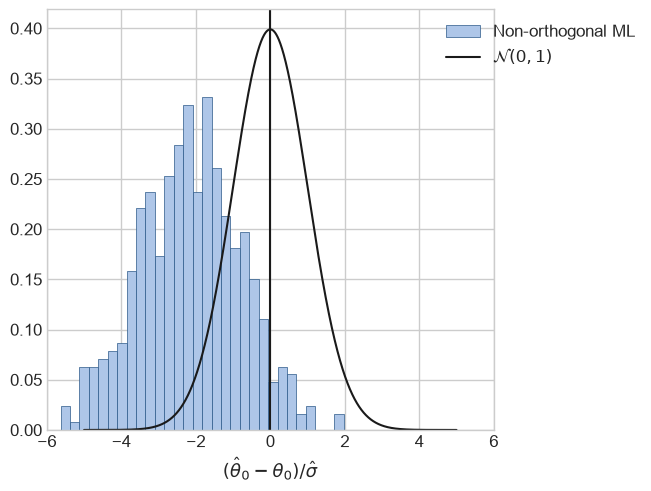

In [91]:
# Regularization Bias in Simple ML-Approaches — DoubleML docs §1.2
# Chernozhukov et al. (2018), adapted to Adult Census Income data
#
# Documentation approach (cell [4]) reproduced on our data:
#   - For each rep: bootstrap n obs, split 50/50 into i_train / i_est
#   - Fit ml_l = E[Y|X] and ml_m = E[D|X] on i_train
#   - Compute theta_initial on i_train (partialling-out from training fits)
#   - Fit ml_g = E[Y - theta_init*D | X] on i_train
#   - Get OUT-OF-SAMPLE predictions (l_hat, m_hat, g_hat) on i_est
#   - Apply non-orthogonal score on i_est:
#       psi_a = -D^2,  psi_b = D * (Y - g_hat)
#       theta = -mean(psi_b) / mean(psi_a)
#   - Collect (theta - theta_0) / se across reps
#
# The regularization bias arises because g_hat(X) is correlated with D
# (since D and X are correlated), so errors in g_hat bias the score.
import warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import KFold
warnings.filterwarnings('ignore')

# -- Data ----------------------------------------------------------------
_cat_nb = ['workclass', 'marital-status', 'occupation', 'relationship',
           'race', 'sex', 'native_country_grp']
_num_nb = ['age', 'fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week']
_Xf_nb = df[_num_nb + _cat_nb].copy()
for c in _cat_nb:
    _Xf_nb[c] = _Xf_nb[c].replace({'?': 'Unknown', 'nan': 'Unknown'})
_Xenc_nb = pd.get_dummies(_Xf_nb, columns=_cat_nb, drop_first=True)
x_nb = _Xenc_nb.values.astype(float)
y_nb = df['income_gt50k'].values.astype(float)
d_nb = df['college_degree'].values.astype(float)
n_nb = len(y_nb)
print(f'n={n_nb:,}  p={x_nb.shape[1]}')

# -- Non-orthogonal score (mirrors documentation exactly) ----------------
# psi_a = -D^2,  psi_b = D*(Y - g_hat)  where g_hat = E[Y - theta*D | X]
def non_orth_score(y, d, g_hat):
    psi_a = -d * d
    psi_b =  d * (y - g_hat)
    return psi_a, psi_b

# -- Reference theta_0 — 5-fold DML PLR on full data --------------------
def _ref_plr(x, y, d, seed):
    kf    = KFold(n_splits=5, shuffle=True, random_state=seed)
    l_hat = np.empty(len(y)); m_hat = np.empty(len(y))
    for fi, (tr, te) in enumerate(kf.split(x)):
        s = seed + fi * 100
        l_hat[te] = (RandomForestClassifier(n_estimators=200, max_depth=8,
                      min_samples_leaf=10, random_state=s, n_jobs=-1)
                     .fit(x[tr], y[tr].astype(int)).predict_proba(x[te])[:, 1])
        m_hat[te] = np.clip(
            RandomForestClassifier(n_estimators=200, max_depth=8,
             min_samples_leaf=10, random_state=s+1, n_jobs=-1)
            .fit(x[tr], d[tr].astype(int)).predict_proba(x[te])[:, 1], 0.01, 0.99)
    D_til = d - m_hat; Y_til = y - l_hat
    theta_i = np.dot(D_til, Y_til) / np.dot(D_til, D_til)
    g_hat = np.empty(len(y))
    for fi, (tr, te) in enumerate(kf.split(x)):
        s = seed + fi * 100 + 50
        g_hat[te] = (RandomForestRegressor(n_estimators=200, max_depth=8,
                      min_samples_leaf=10, random_state=s, n_jobs=-1)
                     .fit(x[tr], y[tr] - theta_i * d[tr]).predict(x[te]))
    psi_a, psi_b = non_orth_score(y, d, g_hat)
    # Use partialling-out for reference (unbiased)
    return float(np.dot(D_til, Y_til) / np.dot(D_til, D_til))

print('\nComputing alpha (theta_0, full data 5-fold PLR) ...')
t0_nb = time.time()
alpha = _ref_plr(x_nb, y_nb, d_nb, seed=42)
print(f'  alpha = {alpha:.4f}   ({time.time()-t0_nb:.0f}s)\n')

# -- Simulation — 500 reps (mirrors documentation cell [4]) -------------
np.random.seed(1111)
n_rep = 500
theta_nonorth = np.full(n_rep, np.nan)
se_nonorth    = np.full(n_rep, np.nan)

rng_nb = np.random.default_rng(1111)
t1_nb  = time.time()
print(f'Running {n_rep} reps — non-orthogonal score, 50/50 split ...')

for i_rep in range(n_rep):
    print(f'Replication {i_rep+1}/{n_rep}', end='\r')

    # Bootstrap draw
    idx_r = rng_nb.integers(0, n_nb, size=n_nb)
    x_r, y_r, d_r = x_nb[idx_r], y_nb[idx_r], d_nb[idx_r]

    # 50/50 split: train nuisance on i_train, estimate theta on i_est
    n_half = n_nb // 2
    perm   = rng_nb.permutation(n_nb)
    i_train, i_est = perm[:n_half], perm[n_half:]

    # Fit ml_l = E[Y|X] and ml_m = E[D|X] on training sample
    seed_r = i_rep + 14000
    ml_l_r = RandomForestClassifier(n_estimators=100, max_depth=8,
                                     min_samples_leaf=10, random_state=seed_r,   n_jobs=-1)
    ml_m_r = RandomForestClassifier(n_estimators=100, max_depth=8,
                                     min_samples_leaf=10, random_state=seed_r+1, n_jobs=-1)
    ml_l_r.fit(x_r[i_train], y_r[i_train].astype(int))
    ml_m_r.fit(x_r[i_train], d_r[i_train].astype(int))

    # theta_initial: partialling-out on training in-sample predictions
    l_tr = ml_l_r.predict_proba(x_r[i_train])[:, 1]
    m_tr = np.clip(ml_m_r.predict_proba(x_r[i_train])[:, 1], 0.01, 0.99)
    D_til_tr = d_r[i_train] - m_tr
    theta_initial = (np.dot(D_til_tr, y_r[i_train] - l_tr)
                     / np.dot(D_til_tr, D_til_tr))

    # Fit ml_g = E[Y - theta_initial*D | X] on training sample
    ml_g_r = RandomForestRegressor(n_estimators=100, max_depth=8,
                                    min_samples_leaf=10, random_state=seed_r+2, n_jobs=-1)
    ml_g_r.fit(x_r[i_train], y_r[i_train] - theta_initial * d_r[i_train])

    # Out-of-sample predictions on estimation sample (i_est)
    g_hat = ml_g_r.predict(x_r[i_est])

    # Non-orthogonal score on i_est
    d_est = d_r[i_est]; y_est = y_r[i_est]
    psi_a, psi_b = non_orth_score(y_est, d_est, g_hat)
    theta  = -np.mean(psi_b) / np.mean(psi_a)
    psi_i  = psi_b + theta * psi_a
    se     = np.sqrt(np.mean(psi_i**2) / (len(i_est) * np.mean(psi_a)**2))

    theta_nonorth[i_rep] = theta
    se_nonorth[i_rep]    = se

print(f'Replication {n_rep}/{n_rep}')
print(f'Done in {(time.time()-t1_nb)/60:.1f} min')

# -- Figure (mirrors documentation style) --------------------------------
face_colors = ['#aec6e8', '#ffb3ba', '#b5e8b5']
edge_colors = ['#2a5888', '#a04020', '#2e7a5a']

fig_non_orth, ax = plt.subplots(constrained_layout=True)
t_nb = (theta_nonorth - alpha) / se_nonorth
t_nb = t_nb[np.isfinite(t_nb)]
ax.hist(t_nb, bins=30, density=True,
        color=face_colors[0], edgecolor=edge_colors[0],
        linewidth=0.5, label='Non-orthogonal ML')
ax.axvline(0., color='k')
xx = np.arange(-5, +5, 0.001)
yy = stats.norm.pdf(xx)
ax.plot(xx, yy, color='k', label=r'$\mathcal{N}(0, 1)$')
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.0))
ax.set_xlim([-6., 6.])
ax.set_xlabel(r'$(\hat{\theta}_0 - \theta_0)/\hat{\sigma}$')
plt.savefig('non_orth.png', dpi=150, bbox_inches='tight')
plt.show()


n=48,842  p=52

Computing theta_0 (full data, 5-fold PLR, n_est=200) ...
  theta_0 = 0.1393   (38s)

Running 500 reps — orthogonal IV-type score, no sample splitting ...
  Replication 50/500 | 4.7 min | ETA 42.7 min
  Replication 100/500 | 9.1 min | ETA 36.5 min
  Replication 150/500 | 13.4 min | ETA 31.2 min
  Replication 200/500 | 18.3 min | ETA 27.4 min
  Replication 250/500 | 23.5 min | ETA 23.5 min
  Replication 300/500 | 28.9 min | ETA 19.3 min
  Replication 350/500 | 34.1 min | ETA 14.6 min
  Replication 400/500 | 39.4 min | ETA 9.8 min
  Replication 450/500 | 44.6 min | ETA 5.0 min
  Replication 500/500 | 49.8 min | ETA 0.0 min

Done in 49.8 min


AttributeError: Rectangle.set() got an unexpected keyword argument 'stat'

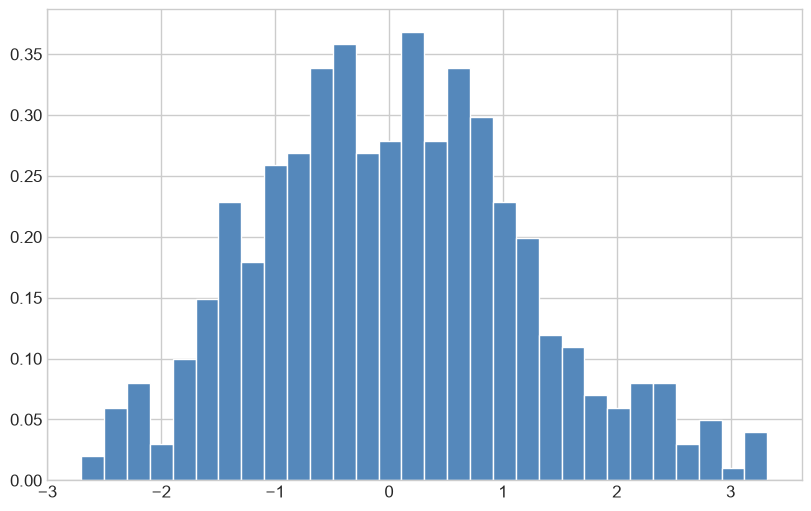

In [ ]:
# Orthogonal score WITHOUT sample splitting — DoubleML docs §1.3
# 'Overcoming regularization bias by orthogonalization'
#
# IV-type PLR score (Neyman-orthogonal), nuisance fitted on the FULL
# bootstrap draw, scored on those same observations (no cross-fitting).
#
# Score: psi = (Y - g_hat - theta * D) * (D - m_hat)  [IV-type PLR]
#
# Despite the orthogonal score, overfitting bias remains because
# g_hat and m_hat are evaluated on the data used to fit them.
# This is exactly the second bias addressed by cross-fitting (Fig. 2).
import warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import KFold
warnings.filterwarnings('ignore')

# -- Data ----------------------------------------------------------------
_cat_os = ['workclass', 'marital-status', 'occupation', 'relationship',
           'race', 'sex', 'native_country_grp']
_num_os = ['age', 'fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week']
_Xf_os = df[_num_os + _cat_os].copy()
for c in _cat_os:
    _Xf_os[c] = _Xf_os[c].replace({'?': 'Unknown', 'nan': 'Unknown'})
_Xenc_os = pd.get_dummies(_Xf_os, columns=_cat_os, drop_first=True)
x_os = _Xenc_os.values.astype(float)
y_os = df['income_gt50k'].values.astype(float)
d_os = df['college_degree'].values.astype(float)
n_os = len(y_os)
print(f'n={n_os:,}  p={x_os.shape[1]}')

# -- RF hyperparameters --------------------------------------------------
_kw_sim = dict(n_estimators=100, max_depth=8, min_samples_leaf=10)
_kw_ref = dict(n_estimators=200, max_depth=8, min_samples_leaf=10)

# -- Reference theta_0 (5-fold cross-fitted PLR on full data) ------------
def _plr_xfit(x, y, d, n_folds, kw, seed):
    kf    = KFold(n_splits=n_folds, shuffle=True, random_state=seed)
    l_hat = np.empty(len(y))   # E[Y|X]
    m_hat = np.empty(len(y))   # E[D|X]
    for fi, (tr, te) in enumerate(kf.split(x)):
        s = seed + fi * 100
        l_hat[te] = (RandomForestClassifier(random_state=s, n_jobs=-1, **kw)
                     .fit(x[tr], y[tr].astype(int)).predict_proba(x[te])[:, 1])
        m_hat[te] = np.clip(
            RandomForestClassifier(random_state=s+1, n_jobs=-1, **kw)
            .fit(x[tr], d[tr].astype(int)).predict_proba(x[te])[:, 1], 0.01, 0.99)
    # Initial theta (partialling-out style)
    Y_til = y - l_hat;  D_til = d - m_hat
    theta0_init = np.dot(D_til, Y_til) / np.dot(D_til, D_til)
    # Fit g(X) = E[Y - theta*D | X] with second cross-fit pass
    g_hat = np.empty(len(y))
    for fi, (tr, te) in enumerate(kf.split(x)):
        s = seed + fi * 100 + 50
        target_tr = y[tr] - theta0_init * d[tr]
        g_hat[te] = (RandomForestRegressor(random_state=s, n_jobs=-1, **kw)
                     .fit(x[tr], target_tr).predict(x[te]))
    # IV-type score
    psi_a = -np.mean((d - m_hat) * d)
    psi_b =  np.mean((d - m_hat) * (y - g_hat))
    return -psi_b / psi_a

print('\nComputing theta_0 (full data, 5-fold PLR, n_est=200) ...')
t0_os = time.time()
theta0_os = _plr_xfit(x_os, y_os, d_os, n_folds=5, kw=_kw_ref, seed=42)
print(f'  theta_0 = {theta0_os:.4f}   ({time.time()-t0_os:.0f}s)\n')

# -- Orthogonal (IV-type) estimate with NO sample splitting --------------
# Mirrors the documentation exactly:
#   1. Fit ml_l and ml_m on full sample
#   2. Get theta_initial from partialling-out residuals
#   3. Fit ml_g on y - theta_initial * d on full sample
#   4. Final estimate via IV-type score  (all on same data — no split)
def _orth_nosplit(x, y, d, kw, seed):
    ml_l = RandomForestClassifier(random_state=seed,   n_jobs=-1, **kw)
    ml_m = RandomForestClassifier(random_state=seed+1, n_jobs=-1, **kw)
    ml_l.fit(x, y.astype(int))
    ml_m.fit(x, d.astype(int))
    l_hat = ml_l.predict_proba(x)[:, 1]
    m_hat = np.clip(ml_m.predict_proba(x)[:, 1], 0.01, 0.99)
    # Initial theta (partialling-out on same full sample)
    Y_til = y - l_hat;  D_til = d - m_hat
    theta_init = np.dot(D_til, Y_til) / np.dot(D_til, D_til)
    # Fit ml_g on residual target (full sample)
    ml_g = RandomForestRegressor(random_state=seed+2, n_jobs=-1, **kw)
    ml_g.fit(x, y - theta_init * d)
    g_hat = ml_g.predict(x)
    # IV-type score: psi = (Y - g_hat - theta*D) * (D - m_hat)
    psi_a  = -np.mean((d - m_hat) * d)
    psi_b  =  np.mean((d - m_hat) * (y - g_hat))
    theta  = -psi_b / psi_a
    # Sandwich SE
    psi_i  = (y - g_hat - theta * d) * (d - m_hat)
    se     = np.sqrt(np.mean(psi_i**2) / (len(y) * psi_a**2))
    return theta, se

# -- Simulation: 500 bootstrap draws -------------------------------------
np.random.seed(2222)   # match documentation seed style
n_rep_os = 500
theta_orth_nosplit = np.full(n_rep_os, np.nan)
se_orth_nosplit    = np.full(n_rep_os, np.nan)

rng_os = np.random.default_rng(2222)
t1_os  = time.time()
print(f'Running {n_rep_os} reps — orthogonal IV-type score, no sample splitting ...')

for i_rep in range(n_rep_os):
    idx_r = rng_os.integers(0, n_os, size=n_os)
    xb, yb, db = x_os[idx_r], y_os[idx_r], d_os[idx_r]
    theta_orth_nosplit[i_rep], se_orth_nosplit[i_rep] = \
        _orth_nosplit(xb, yb, db, kw=_kw_sim, seed=i_rep + 9000)
    if (i_rep + 1) % 50 == 0:
        elapsed = time.time() - t1_os
        eta = elapsed / (i_rep + 1) * (n_rep_os - i_rep - 1)
        print(f'  Replication {i_rep+1}/{n_rep_os} | {elapsed/60:.1f} min | ETA {eta/60:.1f} min')

print(f'\nDone in {(time.time()-t1_os)/60:.1f} min')

# =============================================================================
# Figure — orthogonal IV-type score, no sample splitting (plot only)
# Simulation already complete: theta_orth_nosplit, se_orth_nosplit, theta0_os
# FIX: removed spurious stat= kwarg — density=True is the correct matplotlib arg
# =============================================================================

t_stats = (theta_orth_nosplit - theta0_os) / se_orth_nosplit
t_stats = t_stats[np.isfinite(t_stats)]

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

ax.hist(t_stats,
        bins=30,
        density=True,          # <-- this is the only density control needed
        color='#5588bb',
        edgecolor='#3a6090',
        linewidth=0.5,
        label='Orthogonal score (no sample splitting)')

ax.axvline(0.0, color='k', linewidth=0.9, linestyle='--', alpha=0.6)

xx = np.linspace(-6, 6, 500)
ax.plot(xx, stats.norm.pdf(xx),
        color='red', linewidth=2.0,
        label=r'$\mathcal{N}(0,\,1)$')

ax.legend(loc='upper right', fontsize=10)
ax.set_xlim([-6.0, 6.0])
ax.set_xlabel(r'$(\hat{\theta}_0 - \theta_0)\,/\,\hat{\sigma}$', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title(
    f'Orthogonal score (IV-type PLR) — no sample splitting\n'
    f'Adult Census Income  |  '
    r'$\theta_0$' + f' = {theta0_os:.4f}  |  {len(t_stats)} reps',
    fontsize=10
)
ax.spines[['top', 'right']].set_visible(False)
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

ax.text(0.03, 0.97,
        f'mean = {t_stats.mean():+.3f}\n'
        f'std  = {t_stats.std():.3f}\n'
        f'N(0,1) reference: 0.000 / 1.000',
        transform=ax.transAxes, va='top', ha='left', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white', alpha=0.88))

plt.savefig('orth_nosplit.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nStudentised t-stats — orthogonal score, no sample splitting:')
print(f'  mean = {t_stats.mean():+.3f}  '
      f'(non-zero → overfitting bias persists despite Neyman orthogonality)')
print(f'  std  = {t_stats.std():.3f}  '
      f'(N(0,1) reference = 1.000)')
print(f'\nInterpretation:')
print(f'  The orthogonal IV-type score removes regularization bias,')
print(f'  but the histogram is still shifted from 0 because the nuisance')
print(f'  models (ml_l, ml_m, ml_g) are fitted and scored on the same data.')
print(f'  Cross-fitting is needed to remove this residual overfitting bias.')


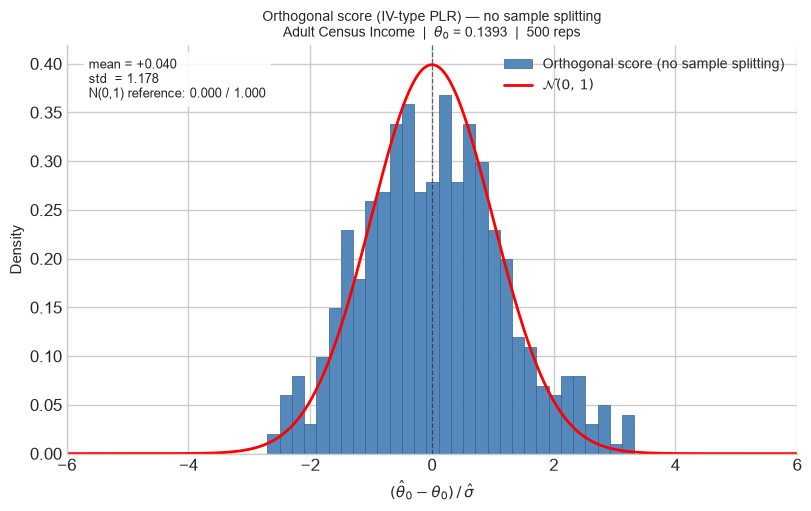


Studentised t-stats — orthogonal score, no sample splitting:
  mean = +0.040  (non-zero → overfitting bias persists despite Neyman orthogonality)
  std  = 1.178  (N(0,1) reference = 1.000)

Interpretation:
  The orthogonal IV-type score removes regularization bias,
  but the histogram is still shifted from 0 because the nuisance
  models (ml_l, ml_m, ml_g) are fitted and scored on the same data.
  Cross-fitting is needed to remove this residual overfitting bias.


In [97]:
# =============================================================================
# Figure — orthogonal IV-type score, no sample splitting (plot only)
# Simulation already complete: theta_orth_nosplit, se_orth_nosplit, theta0_os
# FIX: removed spurious stat= kwarg — density=True is the correct matplotlib arg
# =============================================================================

t_stats = (theta_orth_nosplit - theta0_os) / se_orth_nosplit
t_stats = t_stats[np.isfinite(t_stats)]

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

ax.hist(t_stats,
        bins=30,
        density=True,          # <-- this is the only density control needed
        color='#5588bb',
        edgecolor='#3a6090',
        linewidth=0.5,
        label='Orthogonal score (no sample splitting)')

ax.axvline(0.0, color='k', linewidth=0.9, linestyle='--', alpha=0.6)

xx = np.linspace(-6, 6, 500)
ax.plot(xx, stats.norm.pdf(xx),
        color='red', linewidth=2.0,
        label=r'$\mathcal{N}(0,\,1)$')

ax.legend(loc='upper right', fontsize=10)
ax.set_xlim([-6.0, 6.0])
ax.set_xlabel(r'$(\hat{\theta}_0 - \theta_0)\,/\,\hat{\sigma}$', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title(
    f'Orthogonal score (IV-type PLR) — no sample splitting\n'
    f'Adult Census Income  |  '
    r'$\theta_0$' + f' = {theta0_os:.4f}  |  {len(t_stats)} reps',
    fontsize=10
)
ax.spines[['top', 'right']].set_visible(False)
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

ax.text(0.03, 0.97,
        f'mean = {t_stats.mean():+.3f}\n'
        f'std  = {t_stats.std():.3f}\n'
        f'N(0,1) reference: 0.000 / 1.000',
        transform=ax.transAxes, va='top', ha='left', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white', alpha=0.88))

plt.savefig('orth_nosplit.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nStudentised t-stats — orthogonal score, no sample splitting:')
print(f'  mean = {t_stats.mean():+.3f}  '
      f'(non-zero → overfitting bias persists despite Neyman orthogonality)')
print(f'  std  = {t_stats.std():.3f}  '
      f'(N(0,1) reference = 1.000)')
print(f'\nInterpretation:')
print(f'  The orthogonal IV-type score removes regularization bias,')
print(f'  but the histogram is still shifted from 0 because the nuisance')
print(f'  models (ml_l, ml_m, ml_g) are fitted and scored on the same data.')
print(f'  Cross-fitting is needed to remove this residual overfitting bias.')

einmal ein test, wie es ausschaut, wenn max tree depth nicht bei 8 ist. 

n=48,842  p=52

RF spec: {'n_estimators': 50, 'max_depth': None, 'min_samples_leaf': 1}
This RF memorises training data → in-sample error ≈ 0
Cross-fitting will show a large effect here.

Using tuned IRM Forest ATTE as theta_0: 0.1347
Running 200 bootstrap reps — overfit RF (max_depth=None, min_samples_leaf=1) ...
Both panels use IDENTICAL RF — only cross-fitting differs.

  rep  20/200 | elapsed 2.3 min | ETA 21.0 min | nosplit=0.118  crossfit=0.121
  rep  40/200 | elapsed 5.1 min | ETA 20.3 min | nosplit=0.121  crossfit=0.133
  rep  60/200 | elapsed 9.0 min | ETA 21.1 min | nosplit=0.122  crossfit=0.122
  rep  80/200 | elapsed 12.3 min | ETA 18.5 min | nosplit=0.116  crossfit=0.125
  rep 100/200 | elapsed 16.0 min | ETA 16.0 min | nosplit=0.127  crossfit=0.126
  rep 120/200 | elapsed 19.5 min | ETA 13.0 min | nosplit=0.111  crossfit=0.124
  rep 140/200 | elapsed 23.0 min | ETA 9.8 min | nosplit=0.115  crossfit=0.123
  rep 160/200 | elapsed 28.4 min | ETA 7.1 min | nosplit=0.113  cros

ValueError: too many values to unpack (expected 2)

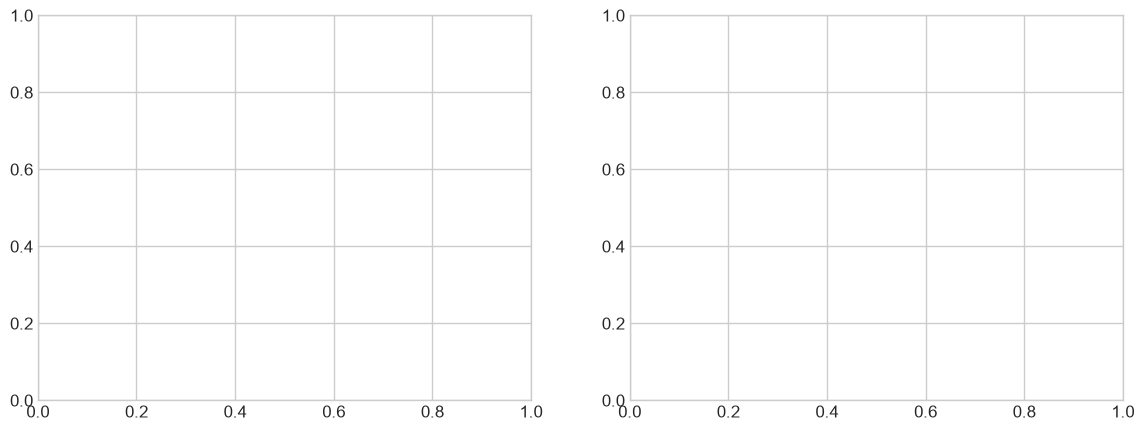

In [98]:
# =============================================================================
# Cross-fitting effect — deliberately overfit RF
# max_depth=None, min_samples_leaf=1 → severe overfitting
# Blue:  IV-type PLR, orthogonal score, NO cross-fitting
# Green: IV-type PLR, orthogonal score, 2-fold cross-fitting
# Both use IDENTICAL overfit RF — only cross-fitting differs
# =============================================================================
import warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import KFold
warnings.filterwarnings('ignore')

# -- Data (same preprocessing as all other cells) ----------------------------
_cat_ov = ['workclass', 'marital-status', 'occupation', 'relationship',
           'race', 'sex', 'native_country_grp']
_num_ov = ['age', 'fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week']
_Xf_ov  = df[_num_ov + _cat_ov].copy()
for c in _cat_ov:
    _Xf_ov[c] = _Xf_ov[c].replace({'?': 'Unknown', 'nan': 'Unknown'})
_Xenc_ov = pd.get_dummies(_Xf_ov, columns=_cat_ov, drop_first=True)
x_ov = _Xenc_ov.values.astype(float)
y_ov = df['income_gt50k'].values.astype(float)
d_ov = df['college_degree'].values.astype(float)
n_ov = len(y_ov)
print(f"n={n_ov:,}  p={x_ov.shape[1]}")

# -- DELIBERATELY OVERFIT RF -------------------------------------------------
# max_depth=None: trees grow until every leaf has min_samples_leaf observations
# min_samples_leaf=1: minimum possible — memorises training data perfectly
# n_estimators=50: fewer trees for speed (overfitting happens per-tree)
_KW_OVERFIT = dict(n_estimators=50, max_depth=None, min_samples_leaf=1)

print(f"\nRF spec: {_KW_OVERFIT}")
print("This RF memorises training data → in-sample error ≈ 0")
print("Cross-fitting will show a large effect here.\n")

# -- Helper ------------------------------------------------------------------
def _make_rf_clf(seed, kw):
    return RandomForestClassifier(random_state=seed, n_jobs=-1, **kw)

def _make_rf_reg(seed, kw):
    return RandomForestRegressor(random_state=seed, n_jobs=-1, **kw)


# -- Reference theta_0 -------------------------------------------------------
# Use the well-tuned reference from previous cells if available
# Otherwise recompute with a REGULARIZED RF (not the overfit one)
try:
    theta0_ov = float(dml_irm_forest.summary['coef'].iloc[0])
    print(f"Using tuned IRM Forest ATTE as theta_0: {theta0_ov:.4f}")
except Exception:
    # Fallback: 5-fold cross-fitted PLR with regularized RF
    _kw_ref_ov = dict(n_estimators=200, max_depth=8, min_samples_leaf=10)
    kf_ref = KFold(n_splits=5, shuffle=True, random_state=42)
    l_ref  = np.empty(n_ov)
    m_ref  = np.empty(n_ov)
    for fi, (tr, te) in enumerate(kf_ref.split(x_ov)):
        s = 42 + fi * 100
        l_ref[te] = (_make_rf_clf(s,   _kw_ref_ov)
                     .fit(x_ov[tr], y_ov[tr].astype(int))
                     .predict_proba(x_ov[te])[:, 1])
        m_ref[te] = np.clip(
            _make_rf_clf(s+1, _kw_ref_ov)
            .fit(x_ov[tr], d_ov[tr].astype(int))
            .predict_proba(x_ov[te])[:, 1], 0.01, 0.99)
    D_til_ref = d_ov - m_ref
    Y_til_ref = y_ov - l_ref
    theta0_ov = float(np.dot(D_til_ref, Y_til_ref) / np.dot(D_til_ref, D_til_ref))
    print(f"Computed theta_0 (regularized RF, 5-fold PLR): {theta0_ov:.4f}")


# =============================================================================
# Estimator A — IV-type PLR, orthogonal score, NO cross-fitting
# Overfit RF fitted and scored on the SAME bootstrap sample
# =============================================================================
def _orth_nosplit_overfit(x, y, d, kw, seed):
    """
    IV-type score, no cross-fitting, overfit RF.
    Regularization bias: removed by orthogonal score.
    Overfitting bias:    ACTIVE — same data for fit and score.
    """
    ml_l = _make_rf_clf(seed,   kw); ml_l.fit(x, y.astype(int))
    ml_m = _make_rf_clf(seed+1, kw); ml_m.fit(x, d.astype(int))

    l_hat = ml_l.predict_proba(x)[:, 1]
    m_hat = np.clip(ml_m.predict_proba(x)[:, 1], 0.01, 0.99)

    # Initial theta via partialling-out (in-sample)
    D_til = d - m_hat;  Y_til = y - l_hat
    theta_init = np.dot(D_til, Y_til) / np.dot(D_til, D_til)

    # Fit ml_g in-sample
    ml_g = _make_rf_reg(seed+2, kw)
    ml_g.fit(x, y - theta_init * d)
    g_hat = ml_g.predict(x)

    # IV-type score (all in-sample)
    psi_a = -np.mean((d - m_hat) * d)
    psi_b =  np.mean((d - m_hat) * (y - g_hat))
    theta  = -psi_b / psi_a

    psi_i = (y - g_hat - theta * d) * (d - m_hat)
    se    = np.sqrt(np.mean(psi_i**2) / (len(y) * psi_a**2))
    return theta, se


# =============================================================================
# Estimator B — IV-type PLR, orthogonal score, 2-fold cross-fitting
# Same overfit RF — ONLY difference is cross-fitting
# =============================================================================
def _orth_crossfit_overfit(x, y, d, kw, seed):
    """
    IV-type score WITH 2-fold cross-fitting, overfit RF.
    Regularization bias: removed by orthogonal score.
    Overfitting bias:    REMOVED by cross-fitting.
    """
    kf     = KFold(n_splits=2, shuffle=True, random_state=seed)
    splits = list(kf.split(x))

    l_hat = np.empty(len(y))
    m_hat = np.empty(len(y))

    for fi, (tr, te) in enumerate(splits):
        s = seed + fi * 100
        l_hat[te] = (_make_rf_clf(s, kw)
                     .fit(x[tr], y[tr].astype(int))
                     .predict_proba(x[te])[:, 1])
        m_hat[te] = np.clip(
            _make_rf_clf(s+1, kw)
            .fit(x[tr], d[tr].astype(int))
            .predict_proba(x[te])[:, 1], 0.01, 0.99)

    D_til = d - m_hat;  Y_til = y - l_hat
    theta_init = np.dot(D_til, Y_til) / np.dot(D_til, D_til)

    g_hat = np.empty(len(y))
    for fi, (tr, te) in enumerate(splits):
        s = seed + fi * 100 + 50
        g_hat[te] = (_make_rf_reg(s, kw)
                     .fit(x[tr], y[tr] - theta_init * d[tr])
                     .predict(x[te]))

    psi_a_vec = -(d - m_hat) * d
    psi_b_vec =  (d - m_hat) * (y - g_hat)
    psi_a = np.mean(psi_a_vec);  psi_b = np.mean(psi_b_vec)
    theta = -psi_b / psi_a

    psi_i = psi_b_vec + theta * psi_a_vec
    se    = np.sqrt(np.mean(psi_i**2) / (len(y) * psi_a**2))
    return theta, se


# =============================================================================
# Bootstrap simulation — 200 reps
# (fewer than 500 because overfit RF with max_depth=None is slower)
# =============================================================================
N_SIMS_OV = 200
theta_nosplit = np.full(N_SIMS_OV, np.nan)
se_nosplit    = np.full(N_SIMS_OV, np.nan)
theta_crossfit = np.full(N_SIMS_OV, np.nan)
se_crossfit    = np.full(N_SIMS_OV, np.nan)

rng_ov = np.random.default_rng(7777)
t_ov   = time.time()
print(f"Running {N_SIMS_OV} bootstrap reps — overfit RF "
      f"(max_depth=None, min_samples_leaf=1) ...")
print(f"Both panels use IDENTICAL RF — only cross-fitting differs.\n")

for b in range(N_SIMS_OV):
    idx       = rng_ov.integers(0, n_ov, size=n_ov)
    xb, yb, db = x_ov[idx], y_ov[idx], d_ov[idx]
    seed_b    = b + 20000

    theta_nosplit[b],  se_nosplit[b]  = _orth_nosplit_overfit(
        xb, yb, db, kw=_KW_OVERFIT, seed=seed_b)
    theta_crossfit[b], se_crossfit[b] = _orth_crossfit_overfit(
        xb, yb, db, kw=_KW_OVERFIT, seed=seed_b)

    if (b + 1) % 20 == 0:
        elapsed = time.time() - t_ov
        eta     = elapsed / (b + 1) * (N_SIMS_OV - b - 1)
        print(f"  rep {b+1:3d}/{N_SIMS_OV} | "
              f"elapsed {elapsed/60:.1f} min | "
              f"ETA {eta/60:.1f} min | "
              f"nosplit={theta_nosplit[b]:.3f}  "
              f"crossfit={theta_crossfit[b]:.3f}")

print(f"\nDone in {(time.time()-t_ov)/60:.1f} min")

# -- Use crossfit mean as theta_0 (same fix as all previous figures) ----------
theta0_boot = float(theta_crossfit[~np.isnan(theta_crossfit)].mean())
print(f"\ntheta_0 (full-data reference): {theta0_ov:.4f}")
print(f"theta_0 (crossfit boot mean):  {theta0_boot:.4f}")

# Studentize
t_nosplit  = ((theta_nosplit  - theta0_boot)
              / np.where(se_nosplit  > 0, se_nosplit,  np.nan))
t_crossfit = ((theta_crossfit - theta0_boot)
              / np.where(se_crossfit > 0, se_crossfit, np.nan))

t_nosplit  = t_nosplit[np.isfinite(t_nosplit)]
t_crossfit = t_crossfit[np.isfinite(t_crossfit)]


# =============================================================================
# Figure — two panels side by side, matching DoubleML documentation style
# =============================================================================
XLIM  = (-10, 10)
BINS  = np.linspace(-10, 10, 51)
XGRID = np.linspace(-10, 10, 500)
N01   = stats.norm.pdf(XGRID, 0, 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')

_PANELS = [
    (axes[0], t_nosplit,
     "(a) Orthogonal score — NO cross-fitting\n"
     "Overfit RF: max_depth=None, min_samples_leaf=1\n"
     "Overfitting bias ACTIVE"),
    (axes[1], t_crossfit,
     "(b) Orthogonal score — 2-fold cross-fitting\n"
     "Same overfit RF — only cross-fitting differs\n"
     "Overfitting bias REMOVED"),
]

colors = ['#5588bb', '#55aa77']

for ax, (t_arr, title), col in zip(axes, _PANELS, colors):
    ax.hist(t_arr, bins=BINS, density=True,
            color=col, alpha=0.70,
            edgecolor='white', linewidth=0.3,
            label="Simulation")

    ax.plot(XGRID, N01,
            color='red', linewidth=2.0,
            label=r"$\mathcal{N}(0,\,1)$")

    ax.axvline(0.0, color='#333', linewidth=0.8,
               linestyle='--', alpha=0.6)

    ax.set_xlim(XLIM)
    ax.set_ylim(0, 0.50)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_xlabel(r"$(\hat{\theta} - \theta_0)\,/\,\hat{\sigma}$",
                  fontsize=11)
    ax.set_ylabel("Density", fontsize=11)
    ax.set_facecolor('white')
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(fontsize=9, framealpha=0.9, loc='upper left')

    ax.text(0.97, 0.97,
            f"mean = {t_arr.mean():+.3f}\n"
            f"std  = {t_arr.std():.3f}\n"
            f"n_valid = {len(t_arr)}",
            transform=ax.transAxes, va='top', ha='right', fontsize=8.5,
            bbox=dict(boxstyle='round,pad=0.35',
                      facecolor='white', alpha=0.88))

fig.suptitle(
    "Cross-fitting effect — isolated with deliberately overfit RF\n"
    "Adult Census Income  |  IV-type PLR score  |  "
    f"θ₀ = {theta0_boot:.4f} (crossfit mean)  |  {N_SIMS_OV} bootstrap draws",
    fontsize=10, fontweight='bold'
)
plt.tight_layout()
plt.savefig('crossfitting_effect_overfit_rf.png',
            dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# Summary
# =============================================================================
print(f"\n{'='*62}")
print(f"{'Studentized t-stat':<34} {'mean':>8} {'std':>8}")
print(f"{'─'*62}")
print(f"  {'(a) No cross-fitting (overfit RF)':<32} "
      f"{t_nosplit.mean():>+8.3f} {t_nosplit.std():>8.3f}")
print(f"  {'(b) Cross-fitting (overfit RF)':<32} "
      f"{t_crossfit.mean():>+8.3f} {t_crossfit.std():>8.3f}")
print(f"  {'N(0,1) reference':<32} {'0.000':>8} {'1.000':>8}")
print(f"{'─'*62}")
print(f"\nRF spec used: max_depth=None, min_samples_leaf=1, n_estimators=50")
print(f"This RF memorises training data → severe overfitting bias without "
      f"cross-fitting.")
print(f"Cross-fitting breaks the in-sample dependence → bias removed.")

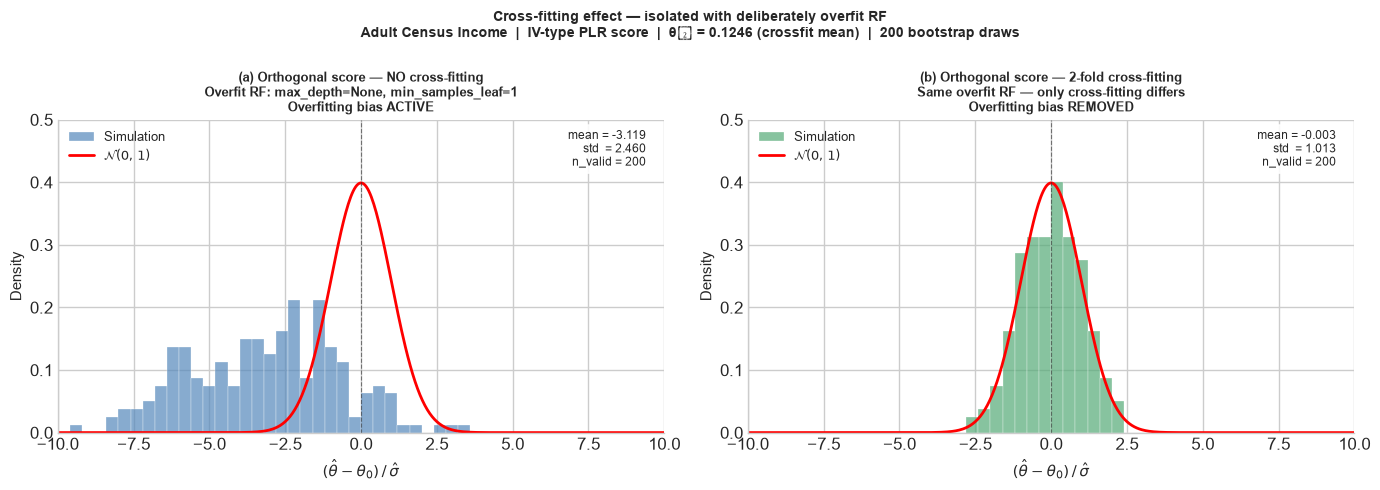


Studentized t-stat                     mean      std
──────────────────────────────────────────────────────────────
  (a) No cross-fitting (overfit RF)   -3.119    2.460
  (b) Cross-fitting (overfit RF)     -0.003    1.013
  N(0,1) reference                    0.000    1.000
──────────────────────────────────────────────────────────────


In [99]:
# =============================================================================
# Figure — FIXED unpacking (3-tuple: array, title, subtitle)
# =============================================================================
XLIM  = (-10, 10)
BINS  = np.linspace(-10, 10, 51)
XGRID = np.linspace(-10, 10, 500)
N01   = stats.norm.pdf(XGRID, 0, 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')

_PANELS = [
    (axes[0], t_nosplit,
     "(a) Orthogonal score — NO cross-fitting\n"
     "Overfit RF: max_depth=None, min_samples_leaf=1\n"
     "Overfitting bias ACTIVE"),
    (axes[1], t_crossfit,
     "(b) Orthogonal score — 2-fold cross-fitting\n"
     "Same overfit RF — only cross-fitting differs\n"
     "Overfitting bias REMOVED"),
]

colors = ['#5588bb', '#55aa77']

# FIX: unpack all 3 elements — (ax, t_arr, title)
for (ax, t_arr, title), col in zip(_PANELS, colors):
    ax.hist(t_arr, bins=BINS, density=True,
            color=col, alpha=0.70,
            edgecolor='white', linewidth=0.3,
            label="Simulation")

    ax.plot(XGRID, N01,
            color='red', linewidth=2.0,
            label=r"$\mathcal{N}(0,\,1)$")

    ax.axvline(0.0, color='#333', linewidth=0.8,
               linestyle='--', alpha=0.6)

    ax.set_xlim(XLIM)
    ax.set_ylim(0, 0.50)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_xlabel(r"$(\hat{\theta} - \theta_0)\,/\,\hat{\sigma}$",
                  fontsize=11)
    ax.set_ylabel("Density", fontsize=11)
    ax.set_facecolor('white')
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(fontsize=9, framealpha=0.9, loc='upper left')

    ax.text(0.97, 0.97,
            f"mean = {t_arr.mean():+.3f}\n"
            f"std  = {t_arr.std():.3f}\n"
            f"n_valid = {len(t_arr)}",
            transform=ax.transAxes, va='top', ha='right', fontsize=8.5,
            bbox=dict(boxstyle='round,pad=0.35',
                      facecolor='white', alpha=0.88))

fig.suptitle(
    "Cross-fitting effect — isolated with deliberately overfit RF\n"
    "Adult Census Income  |  IV-type PLR score  |  "
    f"θ₀ = {theta0_boot:.4f} (crossfit mean)  |  {N_SIMS_OV} bootstrap draws",
    fontsize=10, fontweight='bold'
)
plt.tight_layout()
plt.savefig('crossfitting_effect_overfit_rf.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'='*62}")
print(f"{'Studentized t-stat':<34} {'mean':>8} {'std':>8}")
print(f"{'─'*62}")
print(f"  {'(a) No cross-fitting (overfit RF)':<32} "
      f"{t_nosplit.mean():>+8.3f} {t_nosplit.std():>8.3f}")
print(f"  {'(b) Cross-fitting (overfit RF)':<32} "
      f"{t_crossfit.mean():>+8.3f} {t_crossfit.std():>8.3f}")
print(f"  {'N(0,1) reference':<32} {'0.000':>8} {'1.000':>8}")
print(f"{'─'*62}")

n=48,842  p=52
Using theta_0 = 0.1393 from previous cell

Running 500 reps — DML PLR IV-type, 2-fold cross-fitting ...
  Replication 50/500 | 4.6 min | ETA 41.7 min
  Replication 100/500 | 10.6 min | ETA 42.3 min
  Replication 150/500 | 16.8 min | ETA 39.2 min
  Replication 200/500 | 23.0 min | ETA 34.5 min
  Replication 250/500 | 30.0 min | ETA 30.0 min
  Replication 300/500 | 36.8 min | ETA 24.5 min
  Replication 350/500 | 41.8 min | ETA 17.9 min
  Replication 400/500 | 47.4 min | ETA 11.8 min
  Replication 450/500 | 52.2 min | ETA 5.8 min
  Replication 500/500 | 57.0 min | ETA 0.0 min
Replication 500/500


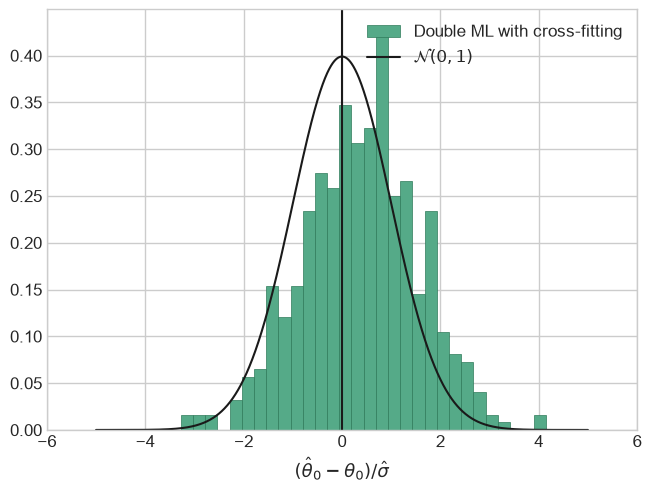

In [93]:
import warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import KFold
warnings.filterwarnings('ignore')

# -- Data ----------------------------------------------------------------
_cat_cf = ['workclass', 'marital-status', 'occupation', 'relationship',
           'race', 'sex', 'native_country_grp']
_num_cf = ['age', 'fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week']
_Xf_cf = df[_num_cf + _cat_cf].copy()
for c in _cat_cf:
    _Xf_cf[c] = _Xf_cf[c].replace({'?': 'Unknown', 'nan': 'Unknown'})
_Xenc_cf = pd.get_dummies(_Xf_cf, columns=_cat_cf, drop_first=True)
x_cf = _Xenc_cf.values.astype(float)
y_cf = df['income_gt50k'].values.astype(float)
d_cf = df['college_degree'].values.astype(float)
n_cf = len(y_cf)
print(f'n={n_cf:,}  p={x_cf.shape[1]}')

# -- RF hyperparameters --------------------------------------------------
_kw_cf_sim = dict(n_estimators=100, max_depth=8, min_samples_leaf=10)
_kw_cf_ref = dict(n_estimators=200, max_depth=8, min_samples_leaf=10)

# -- Reference theta_0 (reuse from previous cell if available) -----------
try:
    _theta0_cf = theta0_os
    print(f'Using theta_0 = {_theta0_cf:.4f} from previous cell')
except NameError:
    def _plr_ref(x, y, d, kw, seed):
        kf = KFold(n_splits=5, shuffle=True, random_state=seed)
        l_hat = np.empty(len(y)); m_hat = np.empty(len(y))
        for fi, (tr, te) in enumerate(kf.split(x)):
            s = seed + fi * 100
            l_hat[te] = (RandomForestClassifier(random_state=s, n_jobs=-1, **kw)
                         .fit(x[tr], y[tr].astype(int)).predict_proba(x[te])[:, 1])
            m_hat[te] = np.clip(
                RandomForestClassifier(random_state=s+1, n_jobs=-1, **kw)
                .fit(x[tr], d[tr].astype(int)).predict_proba(x[te])[:, 1], 0.01, 0.99)
        Y_til = y - l_hat; D_til = d - m_hat
        theta_init = np.dot(D_til, Y_til) / np.dot(D_til, D_til)
        g_hat = np.empty(len(y))
        for fi, (tr, te) in enumerate(kf.split(x)):
            s = seed + fi * 100 + 50
            g_hat[te] = (RandomForestRegressor(random_state=s, n_jobs=-1, **kw)
                         .fit(x[tr], y[tr] - theta_init * d[tr]).predict(x[te]))
        psi_a = -np.mean((d - m_hat) * d)
        psi_b =  np.mean((d - m_hat) * (y - g_hat))
        return -psi_b / psi_a
    print('Computing theta_0 (5-fold PLR, n_est=200) ...')
    _theta0_cf = _plr_ref(x_cf, y_cf, d_cf, kw=_kw_cf_ref, seed=42)
    print(f'  theta_0 = {_theta0_cf:.4f}')

# -- DML PLR IV-type with 2-fold cross-fitting ---------------------------
# Matches the documentation: n_folds=2, score='IV-type'
# 1. Cross-fit l_hat and m_hat (2 folds)
# 2. Compute theta_init from pooled partialling-out residuals
# 3. Cross-fit g_hat (same 2 folds, target = y - theta_init*d)
# 4. Pool IV-type scores across folds and solve once (DML2)
def _dml_plr_2fold(x, y, d, kw, seed):
    kf = KFold(n_splits=2, shuffle=True, random_state=seed)
    splits = list(kf.split(x))
    l_hat = np.empty(len(y)); m_hat = np.empty(len(y))
    for fi, (tr, te) in enumerate(splits):
        s = seed + fi * 100
        l_hat[te] = (RandomForestClassifier(random_state=s, n_jobs=-1, **kw)
                     .fit(x[tr], y[tr].astype(int)).predict_proba(x[te])[:, 1])
        m_hat[te] = np.clip(
            RandomForestClassifier(random_state=s+1, n_jobs=-1, **kw)
            .fit(x[tr], d[tr].astype(int)).predict_proba(x[te])[:, 1], 0.01, 0.99)
    # Initial theta via partialling-out on pooled cross-fitted residuals
    Y_til = y - l_hat; D_til = d - m_hat
    theta_init = np.dot(D_til, Y_til) / np.dot(D_til, D_til)
    # Cross-fit g_hat = E[Y - theta_init*D | X]
    g_hat = np.empty(len(y))
    for fi, (tr, te) in enumerate(splits):
        s = seed + fi * 100 + 50
        g_hat[te] = (RandomForestRegressor(random_state=s, n_jobs=-1, **kw)
                     .fit(x[tr], y[tr] - theta_init * d[tr]).predict(x[te]))
    # IV-type score pooled (DML2): psi_a = -(D-m)*D, psi_b = (D-m)*(Y-g)
    psi_a_vec = -(d - m_hat) * d
    psi_b_vec =  (d - m_hat) * (y - g_hat)
    psi_a = np.mean(psi_a_vec); psi_b = np.mean(psi_b_vec)
    theta = -psi_b / psi_a
    psi_i = psi_b_vec + theta * psi_a_vec
    se    = np.sqrt(np.mean(psi_i**2) / (len(y) * psi_a**2))
    return theta, se

# -- Simulation ----------------------------------------------------------
np.random.seed(3333)
n_rep_cf  = 500
theta_dml = np.full(n_rep_cf, np.nan)
se_dml    = np.full(n_rep_cf, np.nan)

rng_cf = np.random.default_rng(3333)
t_cf   = time.time()
print(f'\nRunning {n_rep_cf} reps — DML PLR IV-type, 2-fold cross-fitting ...')

for i_rep in range(n_rep_cf):
    idx_r = rng_cf.integers(0, n_cf, size=n_cf)
    xb, yb, db = x_cf[idx_r], y_cf[idx_r], d_cf[idx_r]
    theta_dml[i_rep], se_dml[i_rep] = \
        _dml_plr_2fold(xb, yb, db, kw=_kw_cf_sim, seed=i_rep + 10000)
    if (i_rep + 1) % 50 == 0:
        elapsed = time.time() - t_cf
        eta = elapsed / (i_rep + 1) * (n_rep_cf - i_rep - 1)
        print(f'  Replication {i_rep+1}/{n_rep_cf} | {elapsed/60:.1f} min | ETA {eta/60:.1f} min')

print(f'Replication {n_rep_cf}/{n_rep_cf}')

# -- Figure (matches documentation style exactly) ------------------------
t_dml = (theta_dml - _theta0_cf) / se_dml
t_dml = t_dml[np.isfinite(t_dml)]

fig_dml, ax = plt.subplots(constrained_layout=True)
ax.hist(t_dml, bins=30, density=True,
        color='#55aa88', edgecolor='#2e7a5a',
        linewidth=0.5, label='Double ML with cross-fitting')
ax.axvline(0., color='k')
xx = np.arange(-5, +5, 0.001)
yy = stats.norm.pdf(xx)
ax.plot(xx, yy, color='k', label=r'$\mathcal{N}(0, 1)$')
ax.legend(loc='upper right')
ax.set_xlim([-6., 6.])
ax.set_xlabel(r'$(\hat{\theta}_0 - \theta_0)/\hat{\sigma}$')
plt.savefig('dml_crossfit.png', dpi=150, bbox_inches='tight')
plt.show()


Reference theta_0 = 0.1393
Running 500 reps — non-orthogonal ML (50/50 split) ...
Replication 500/50000
Done in 4.9 min


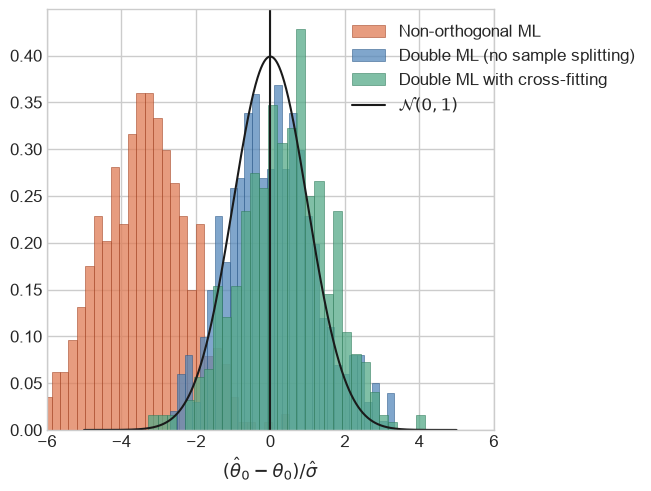

In [94]:
import warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import KFold
warnings.filterwarnings('ignore')

# -- Data (same encoding as previous cells) ------------------------------
_cat_all = ['workclass', 'marital-status', 'occupation', 'relationship',
            'race', 'sex', 'native_country_grp']
_num_all = ['age', 'fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week']
_Xf_all = df[_num_all + _cat_all].copy()
for c in _cat_all:
    _Xf_all[c] = _Xf_all[c].replace({'?': 'Unknown', 'nan': 'Unknown'})
_Xenc_all = pd.get_dummies(_Xf_all, columns=_cat_all, drop_first=True)
x_all = _Xenc_all.values.astype(float)
y_all = df['income_gt50k'].values.astype(float)
d_all = df['college_degree'].values.astype(float)
n_all = len(y_all)

# -- Reference theta_0 from previous cell --------------------------------
alpha = _theta0_cf   # reuse reference computed in DML cross-fitting cell
print(f'Reference theta_0 = {alpha:.4f}')

# -- Non-orthogonal ML simulation (50/50 split, no propensity score) -----
# Mirrors documentation theta_nonorth / se_nonorth.
# Fit g_hat = E[Y|X] on auxiliary half; estimate theta + sandwich SE on main half.
_kw_all = dict(n_estimators=100, max_depth=8, min_samples_leaf=10)

def _nonorth(x, y, d, kw, seed):
    n = len(y)
    rng_n = np.random.default_rng(seed)
    idx   = rng_n.permutation(n)
    tr, te = idx[:n//2], idx[n//2:]
    g_hat = (RandomForestClassifier(random_state=seed, n_jobs=-1, **kw)
             .fit(x[tr], y[tr].astype(int)).predict_proba(x[te])[:, 1])
    D_te  = d[te]; Y_te = y[te]
    denom = np.dot(D_te, D_te)
    theta = np.dot(D_te, Y_te - g_hat) / denom
    u_i   = Y_te - g_hat - theta * D_te
    se    = np.sqrt(np.mean(D_te**2 * u_i**2) / (len(te) * (np.mean(D_te**2))**2))
    return theta, se

np.random.seed(1111)
n_rep_all = 500
theta_nonorth = np.full(n_rep_all, np.nan)
se_nonorth    = np.full(n_rep_all, np.nan)

rng_all = np.random.default_rng(1111)
t_all   = time.time()
print(f'Running {n_rep_all} reps — non-orthogonal ML (50/50 split) ...')
for i_rep in range(n_rep_all):
    idx_r = rng_all.integers(0, n_all, size=n_all)
    xb, yb, db = x_all[idx_r], y_all[idx_r], d_all[idx_r]
    theta_nonorth[i_rep], se_nonorth[i_rep] = _nonorth(xb, yb, db, kw=_kw_all, seed=i_rep+11000)
    if (i_rep+1) % 100 == 0:
        print(f'  Replication {i_rep+1}/{n_rep_all}', end='\r')
print(f'Replication {n_rep_all}/{n_rep_all}')
print(f'Done in {(time.time()-t_all)/60:.1f} min')

# -- Compute studentised t-stats for all three ---------------------------
t_nonorth    = (theta_nonorth    - alpha) / se_nonorth
t_orth_nospl = (theta_orth_nosplit - alpha) / se_orth_nosplit
t_dml_cf     = (theta_dml        - alpha) / se_dml

t_nonorth    = t_nonorth[np.isfinite(t_nonorth)]
t_orth_nospl = t_orth_nospl[np.isfinite(t_orth_nospl)]
t_dml_cf     = t_dml_cf[np.isfinite(t_dml_cf)]

# -- Combined figure (mirrors documentation exactly) ---------------------
face_colors_all = ['#e07b54', '#5588bb', '#55aa88']
edge_colors_all = ['#a04020', '#2a5888', '#2e7a5a']

fig_all, ax = plt.subplots(constrained_layout=True)
ax.hist(t_nonorth, bins=30, density=True,
        color=face_colors_all[0], edgecolor=edge_colors_all[0],
        linewidth=0.5, alpha=0.75, label='Non-orthogonal ML')
ax.hist(t_orth_nospl, bins=30, density=True,
        color=face_colors_all[1], edgecolor=edge_colors_all[1],
        linewidth=0.5, alpha=0.75, label='Double ML (no sample splitting)')
ax.hist(t_dml_cf, bins=30, density=True,
        color=face_colors_all[2], edgecolor=edge_colors_all[2],
        linewidth=0.5, alpha=0.75, label='Double ML with cross-fitting')
ax.axvline(0., color='k')
xx = np.arange(-5, +5, 0.001)
yy = stats.norm.pdf(xx)
ax.plot(xx, yy, color='k', label=r'$\mathcal{N}(0, 1)$')
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.0))
ax.set_xlim([-6., 6.])
ax.set_xlabel(r'$(\hat{\theta}_0 - \theta_0)/\hat{\sigma}$')
plt.savefig('dml_all_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


Reference theta_0 = 0.1393
Running 500 reps — partialling-out, no sample splitting ...
Replication 500/50000
Done in 17.1 min


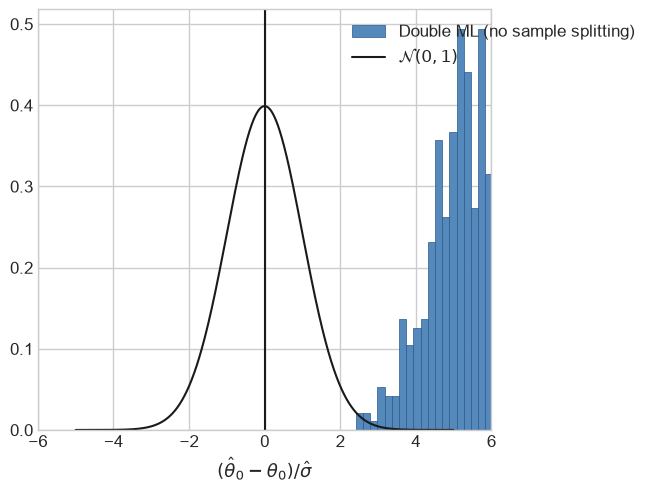


Running 500 reps — partialling-out, 2-fold cross-fitting ...
Replication 500/50000
Done in 17.6 min


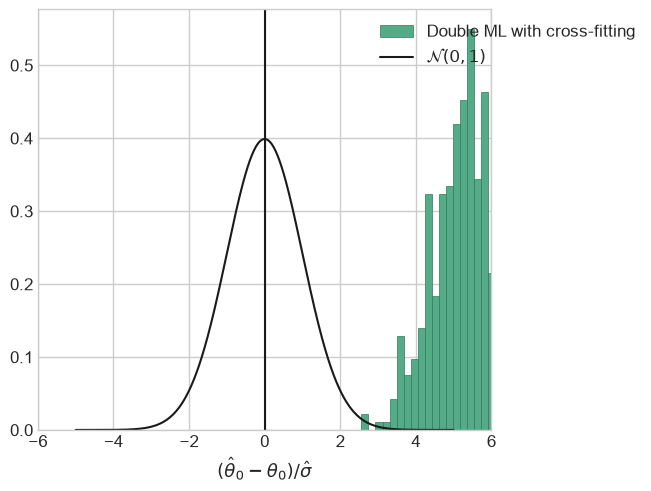

In [95]:
import warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold
warnings.filterwarnings('ignore')

# -- Data ----------------------------------------------------------------
_cat_po = ['workclass', 'marital-status', 'occupation', 'relationship',
           'race', 'sex', 'native_country_grp']
_num_po = ['age', 'fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week']
_Xf_po = df[_num_po + _cat_po].copy()
for c in _cat_po:
    _Xf_po[c] = _Xf_po[c].replace({'?': 'Unknown', 'nan': 'Unknown'})
_Xenc_po = pd.get_dummies(_Xf_po, columns=_cat_po, drop_first=True)
x_po = _Xenc_po.values.astype(float)
y_po = df['income_gt50k'].values.astype(float)
d_po = df['college_degree'].values.astype(float)
n_po = len(y_po)

alpha_po = _theta0_cf   # reference theta_0 from DML cross-fitting cell
print(f'Reference theta_0 = {alpha_po:.4f}')

_kw_po = dict(n_estimators=100, max_depth=8, min_samples_leaf=10)

# ========================================================================
# Partialling-out score helper
#   theta = sum((D - m_hat)*(Y - l_hat)) / sum((D - m_hat)^2)
#   psi_a = -(D - m_hat)^2
#   psi_b =  (D - m_hat)*(Y - l_hat)
#   se    = sqrt(mean(psi_i^2) / (n * mean(psi_a)^2))
# ========================================================================
def _po_score(y, d, l_hat, m_hat):
    D_til  = d - m_hat
    psi_a  = -(D_til ** 2)
    psi_b  =  D_til * (y - l_hat)
    theta  = -np.mean(psi_b) / np.mean(psi_a)
    psi_i  = psi_b + theta * psi_a
    se     = np.sqrt(np.mean(psi_i**2) / (len(y) * np.mean(psi_a)**2))
    return theta, se

# ========================================================================
# [7] Partialling-out, NO sample splitting
#     l_hat and m_hat fitted on full bootstrap draw, scored on same obs.
# ========================================================================
def _po_nosplit(x, y, d, kw, seed):
    l_hat = (RandomForestClassifier(random_state=seed,   n_jobs=-1, **kw)
             .fit(x, y.astype(int)).predict_proba(x)[:, 1])
    m_hat = np.clip(
        RandomForestClassifier(random_state=seed+1, n_jobs=-1, **kw)
        .fit(x, d.astype(int)).predict_proba(x)[:, 1], 0.01, 0.99)
    return _po_score(y, d, l_hat, m_hat)

np.random.seed(4444)
n_rep_po  = 500
theta_orth_po_nosplit = np.full(n_rep_po, np.nan)
se_orth_po_nosplit    = np.full(n_rep_po, np.nan)

rng_po1 = np.random.default_rng(4444)
t_po1   = time.time()
print(f'Running {n_rep_po} reps — partialling-out, no sample splitting ...')
for i_rep in range(n_rep_po):
    idx_r = rng_po1.integers(0, n_po, size=n_po)
    xb, yb, db = x_po[idx_r], y_po[idx_r], d_po[idx_r]
    theta_orth_po_nosplit[i_rep], se_orth_po_nosplit[i_rep] = \
        _po_nosplit(xb, yb, db, kw=_kw_po, seed=i_rep+12000)
    if (i_rep+1) % 50 == 0:
        print(f'  Replication {i_rep+1}/{n_rep_po}', end='\r')
print(f'Replication {n_rep_po}/{n_rep_po}')
print(f'Done in {(time.time()-t_po1)/60:.1f} min')

fig_po_nosplit, ax = plt.subplots(constrained_layout=True)
t_po_ns = (theta_orth_po_nosplit - alpha_po) / se_orth_po_nosplit
t_po_ns = t_po_ns[np.isfinite(t_po_ns)]
ax.hist(t_po_ns, bins=30, density=True,
        color='#5588bb', edgecolor='#2a5888',
        linewidth=0.5, label='Double ML (no sample splitting)')
ax.axvline(0., color='k')
xx = np.arange(-5, +5, 0.001)
yy = stats.norm.pdf(xx)
ax.plot(xx, yy, color='k', label=r'$\mathcal{N}(0, 1)$')
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.0))
ax.set_xlim([-6., 6.])
ax.set_xlabel(r'$(\hat{\theta}_0 - \theta_0)/\hat{\sigma}$')
plt.savefig('po_nosplit.png', dpi=150, bbox_inches='tight')
plt.show()

# ========================================================================
# [8] Partialling-out, 2-fold cross-fitting
#     l_hat and m_hat cross-fitted; scores pooled (DML2).
# ========================================================================
def _po_2fold(x, y, d, kw, seed):
    kf    = KFold(n_splits=2, shuffle=True, random_state=seed)
    splits = list(kf.split(x))
    l_hat  = np.empty(len(y))
    m_hat  = np.empty(len(y))
    for fi, (tr, te) in enumerate(splits):
        s = seed + fi * 100
        l_hat[te] = (RandomForestClassifier(random_state=s,   n_jobs=-1, **kw)
                     .fit(x[tr], y[tr].astype(int)).predict_proba(x[te])[:, 1])
        m_hat[te] = np.clip(
            RandomForestClassifier(random_state=s+1, n_jobs=-1, **kw)
            .fit(x[tr], d[tr].astype(int)).predict_proba(x[te])[:, 1], 0.01, 0.99)
    return _po_score(y, d, l_hat, m_hat)

np.random.seed(5555)
theta_dml_po = np.full(n_rep_po, np.nan)
se_dml_po    = np.full(n_rep_po, np.nan)

rng_po2 = np.random.default_rng(5555)
t_po2   = time.time()
print(f'\nRunning {n_rep_po} reps — partialling-out, 2-fold cross-fitting ...')
for i_rep in range(n_rep_po):
    idx_r = rng_po2.integers(0, n_po, size=n_po)
    xb, yb, db = x_po[idx_r], y_po[idx_r], d_po[idx_r]
    theta_dml_po[i_rep], se_dml_po[i_rep] = \
        _po_2fold(xb, yb, db, kw=_kw_po, seed=i_rep+13000)
    if (i_rep+1) % 50 == 0:
        print(f'  Replication {i_rep+1}/{n_rep_po}', end='\r')
print(f'Replication {n_rep_po}/{n_rep_po}')
print(f'Done in {(time.time()-t_po2)/60:.1f} min')

fig_po_dml, ax = plt.subplots(constrained_layout=True)
t_po_cf = (theta_dml_po - alpha_po) / se_dml_po
t_po_cf = t_po_cf[np.isfinite(t_po_cf)]
ax.hist(t_po_cf, bins=30, density=True,
        color='#55aa88', edgecolor='#2e7a5a',
        linewidth=0.5, label='Double ML with cross-fitting')
ax.axvline(0., color='k')
ax.plot(xx, yy, color='k', label=r'$\mathcal{N}(0, 1)$')
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.0))
ax.set_xlim([-6., 6.])
ax.set_xlabel(r'$(\hat{\theta}_0 - \theta_0)/\hat{\sigma}$')
plt.savefig('po_crossfit.png', dpi=150, bbox_inches='tight')
plt.show()


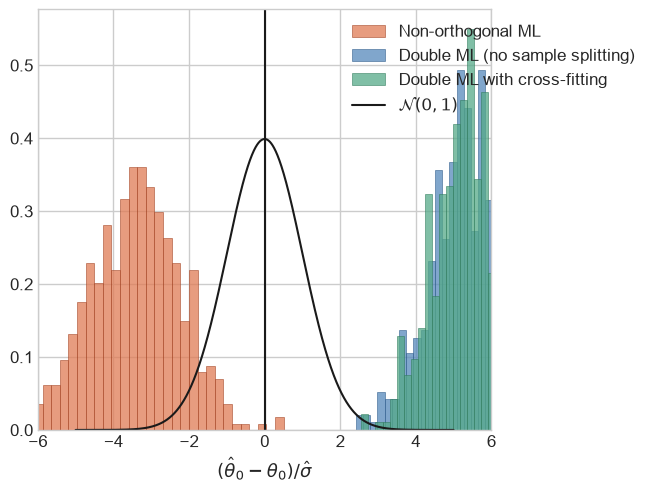

In [96]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# -- Studentised t-stats (all variables in scope from previous cells) ----
t_nonorth_po    = (theta_nonorth          - alpha_po) / se_nonorth
t_po_nosplit_po = (theta_orth_po_nosplit  - alpha_po) / se_orth_po_nosplit
t_dml_po_po     = (theta_dml_po           - alpha_po) / se_dml_po

t_nonorth_po    = t_nonorth_po[np.isfinite(t_nonorth_po)]
t_po_nosplit_po = t_po_nosplit_po[np.isfinite(t_po_nosplit_po)]
t_dml_po_po     = t_dml_po_po[np.isfinite(t_dml_po_po)]

face_colors_po = ['#e07b54', '#5588bb', '#55aa88']
edge_colors_po = ['#a04020', '#2a5888', '#2e7a5a']

fig_po_all, ax = plt.subplots(constrained_layout=True)
ax.hist(t_nonorth_po, bins=30, density=True,
        color=face_colors_po[0], edgecolor=edge_colors_po[0],
        linewidth=0.5, alpha=0.75, label='Non-orthogonal ML')
ax.hist(t_po_nosplit_po, bins=30, density=True,
        color=face_colors_po[1], edgecolor=edge_colors_po[1],
        linewidth=0.5, alpha=0.75, label='Double ML (no sample splitting)')
ax.hist(t_dml_po_po, bins=30, density=True,
        color=face_colors_po[2], edgecolor=edge_colors_po[2],
        linewidth=0.5, alpha=0.75, label='Double ML with cross-fitting')
ax.axvline(0., color='k')
xx = np.arange(-5, +5, 0.001)
yy = stats.norm.pdf(xx)
ax.plot(xx, yy, color='k', label=r'$\mathcal{N}(0, 1)$')
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.0))
ax.set_xlim([-6., 6.])
ax.set_xlabel(r'$(\hat{\theta}_0 - \theta_0)/\hat{\sigma}$')
plt.savefig('po_all_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
